# Attempting to analyze cases

For now, eliminate pretor window and just go up until first tornado report.

In [1]:
from case_functions import *


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [480]:
from cartopy import crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import seaborn.objects as so

# Functions

In [3]:
def hodo_plot(u_list, v_list, heights, component_range, title, color_list, label_list, lower_limit, upper_limit, legend_position, figsizex, figsizey):
    '''
    component_range = single number, how far you want the hodograph plot to extent in m/s
    colors = list of strings of desired colors for hodograph, amount of colors must be = to # of boundary intervals
    '''
    
    from matplotlib import rcParams, rcParamsDefault
    rcParams.update(rcParamsDefault)
    fig, ax = plt.subplots(1, 1, figsize=(figsizex, figsizey))
    hodo = metpy.plots.Hodograph(ax, component_range=component_range)
    hodo.add_grid(increment=5)
    ax.set_xlim(-upper_limit, lower_limit)  # Only negative x values
    ax.set_ylim(-lower_limit, upper_limit)     
    for speed in np.arange(10, 40, 10):  # Adjust range according to your increment and component range
        x = speed / np.sqrt(2)
        y = speed / np.sqrt(2)
        ax.text(-x, y, f'{speed} m/s', color='gray', fontsize=10, ha='center', va='bottom')
    
    #colors = [[0.8,0.3,0.3,1],[0.2,0.7,0.3,1],[0.4,0.9,0.8,1], [0.7,0.4,0.7,1]]
    boundaries = [50, 500, 1000, 1500, 2000]
    
    for u, v, color, label in zip(u_list, v_list, color_list, label_list):
        h = hodo.plot_colormapped(u, v, heights, color= color, label=label, linewidth=3)
    # hodo.wind_vectors(nearfield_u_grady[0], nearfield_v_grady[0], label = 'Storm-Relative Wind Vector (m/s)')
    # hodo.wind_vectors(nearfield_u_grady[99], nearfield_v_grady[99])
    # hodo.wind_vectors(nearfield_u_grady[195], nearfield_v_grady[195])
    
    #ax.scatter(0,0, 'ko')
    ax.set_xlabel('Average U-component Wind (m/s)', fontsize=13)
    ax.set_ylabel('Average V-component Wind (m/s)', fontsize=13)
    ax.set_title(f'{title}', fontsize=13,fontweight='bold')

    for u,v in zip(u_list, v_list):
        
        for i,z in enumerate([0,45,95,195]):
            try:
                if np.isnan(u[z]):
                    pass
                else:
                    circle = plt.Circle((u[z], v[z]), radius=0.5,color='k',zorder=30)
                    ax.add_patch(circle)
                    label = ax.annotate(i, xy=(u[z], v[z]), fontsize=8, ha="center",va='center',color='white',zorder=30,weight="bold")
            except: pass
    
    ax.text(0.71, 0.96, 'Storm-Relative', transform = ax.transAxes, fontsize = 13, verticalalignment='center', color='white', bbox=dict(facecolor='blue', alpha=0.5))
    #plt.colorbar(h, label = 'Height (m above sea level)', shrink = 0.80)
    
    plt.plot(0,0, 'x', markersize = 20, label = 'Storm Motion', color = 'black', markeredgewidth = 3)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    plt.legend(loc=legend_position, fontsize=13)
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/{title}', bbox_inches='tight')
    plt.show()

In [4]:
import pandas as pd
import numpy as np

#def comp_per_case(csv_name, kas, dates, nf_dist, ff_dist, angle0, angle1, tor_time):

def comp_per_case(csv_name, kas, dates, nf_dist, ff_dist, angle0, angle1, angle2, tor_time):
    '''
    angle2 = angle above 0 degrees that you want to be greater than (upper right quadrant)
    '''
    df_all_tor = pd.DataFrame()
    df_all_nontor = pd.DataFrame()
    
    try:
        print(csv_name)
        df = pd.read_csv(csv_name)
        print(f'CSV size: {np.shape(df)}')

        # Filter data based on distance and angle
        nf = df[(df['Distance'] <= nf_dist) & ((df['Angle'] <= angle1) | (df['Angle'] >= angle2))]
        ff = df[(df['Distance'] > ff_dist) & ((df['Angle'] <= angle1) | (df['Angle'] >= angle2))]

        # Check if the dataset contains tornadic cases
        if df['Time From Tor (min)'].ne('nontor').any():
            tor_nf = nf
            pretor_nf = nf[nf['Time From Tor (min)'] < tor_time]
            dtor_nf = nf[nf['Time From Tor (min)'] == tor_time]
            posttor_nf = nf[nf['Time From Tor (min)'] > tor_time]

            tor_ff = ff
            pretor_ff = ff[ff['Time From Tor (min)'] < tor_time]
            dtor_ff = ff[ff['Time From Tor (min)'] == tor_time]
            posttor_ff = ff[ff['Time From Tor (min)'] > tor_time]

            tor_seg = [tor_nf, pretor_nf, dtor_nf, posttor_nf, tor_ff, pretor_ff, dtor_ff, posttor_ff]
            labels = ['tor nf','pretor nf', 'dtor nf', 'posttor nf', 'tor ff', 'pretor ff', 'dtor ff', 'posttor ff']
            u_or_v = ['u', 'v']

            for wind in u_or_v:
                for tor, lab in zip(tor_seg, labels):
                    seg = tor[tor['u or v'] == wind]
                    seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
                    
                    df_temp = pd.DataFrame(seg_avg).T
                    df_temp['label'] = lab
                    df_temp['wind'] = wind
                    df_temp['date'] = dates
                    df_temp['ka'] = kas
                    
                    df_all_tor = pd.concat([df_all_tor, df_temp], ignore_index=True)

        # Check if the dataset contains nontornadic cases
        if df['Time From Tor (min)'].eq('nontor').any():
            
            nf_nt = df[(df['Distance'] <= nf_dist) & (df['Angle'] <= angle1)]
            ff_nt = df[(df['Distance'] > ff_dist) & (df['Angle'] <= angle1)]

            nontor_seg = [nf_nt, ff_nt]
            nontor_labels = ['nontor nf', 'nontor ff']
            u_or_v = ['u', 'v']

            for wind in u_or_v:
                for nontor, nonlab in zip(nontor_seg, nontor_labels):
                    ntseg = nontor[nontor['u or v'] == wind]
                    ntseg_avg = np.nanmean(ntseg.iloc[:, :196], axis=0)

                    df_temp = pd.DataFrame(ntseg_avg).T
                    df_temp['label'] = nonlab
                    df_temp['wind'] = wind
                    df_temp['date'] = dates
                    df_temp['ka'] = kas

                    df_all_nontor = pd.concat([df_all_nontor, df_temp], ignore_index=True)

    except FileNotFoundError:
        print(f"File not found: {csv_name}")
        pass

    return df_all_tor, df_all_nontor

# Dates

In [5]:
#dates = ['20220523', '20220524', '20220531','20230524', '20230527', '20230609','20230611', '20230612', '20240502', '20240504', '20240519', '20240523', '20240602']

# dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
#         '20230611', '20230612', '20230613','20230615', '20240502', '20240504', '20240506',
#           '20240523', '20240528']
dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
        '20230611', '20230612', '20230613','20230615', '20240427', '20240501', '20240502', '20240504', '20240506', '20240519'
          '20240523', '20240528', '20240602']
kas = ['ka1', 'ka2']
heights = np.arange(50, 2010, 10)

# Not composited u and v

In [43]:
df_all = pd.DataFrame()

for ka in kas:
    for d in dates:
        try:
            date = pd.DataFrame()
            not_comp_file_name = f'case_dfs/new/{d}_uv_{ka}_all.csv'
            print(not_comp_file_name)
            df = pd.read_csv(not_comp_file_name)
            print(np.shape(df))
            df['Date'] = d
            df_all = pd.concat([df_all, df], ignore_index=True)
        except FileNotFoundError:
            print(f"File not found: {not_comp_file_name}")
            continue

case_dfs/new/20220523_uv_ka1_all.csv
(192, 201)
case_dfs/new/20220524_uv_ka1_all.csv
(134, 201)
case_dfs/new/20220611_uv_ka1_all.csv
(180, 201)
case_dfs/new/20230524_uv_ka1_all.csv
File not found: case_dfs/new/20230524_uv_ka1_all.csv
case_dfs/new/20230527_uv_ka1_all.csv
(572, 201)
case_dfs/new/20230601_uv_ka1_all.csv
File not found: case_dfs/new/20230601_uv_ka1_all.csv
case_dfs/new/20230609_uv_ka1_all.csv
(392, 201)
case_dfs/new/20230611_uv_ka1_all.csv
(572, 201)
case_dfs/new/20230612_uv_ka1_all.csv
File not found: case_dfs/new/20230612_uv_ka1_all.csv
case_dfs/new/20230613_uv_ka1_all.csv
(206, 201)
case_dfs/new/20230615_uv_ka1_all.csv
(1974, 201)
case_dfs/new/20240427_uv_ka1_all.csv
(388, 201)
case_dfs/new/20240501_uv_ka1_all.csv
(1134, 201)
case_dfs/new/20240502_uv_ka1_all.csv
(834, 201)
case_dfs/new/20240504_uv_ka1_all.csv
(1134, 201)
case_dfs/new/20240506_uv_ka1_all.csv
File not found: case_dfs/new/20240506_uv_ka1_all.csv
case_dfs/new/2024051920240523_uv_ka1_all.csv
File not found: 

In [38]:
df_all_new = pd.DataFrame()
for ka in kas:
    for d in dates:
        for file in glob.glob(f'case_dfs/new/new_secondtrip/*/{d}_uv_{ka}_all.csv'):
            try:
                not_comp_file_name_new = file
                print(not_comp_file_name_new)
                df_new = pd.read_csv(not_comp_file_name_new)
                df_new['Date'] = d
                print(np.shape(df_new))
                df_all_new = pd.concat([df_all_new, df_new], ignore_index=True)
            except FileNotFoundError:
                print(f"File not found: {not_comp_file_name_new}")
                continue

case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka1_all.csv
(120, 202)
case_dfs/new/new_secondtrip/nontornadic/20220524_uv_ka1_all.csv
(100, 202)
case_dfs/new/new_secondtrip/tornadic/20230527_uv_ka1_all.csv
(506, 202)
case_dfs/new/new_secondtrip/nontornadic/20230611_uv_ka1_all.csv
(388, 202)
case_dfs/new/new_secondtrip/nontornadic/20230613_uv_ka1_all.csv
(20, 202)
case_dfs/new/new_secondtrip/tornadic/20230615_uv_ka1_all.csv
(572, 202)
case_dfs/new/new_secondtrip/nontornadic/20240427_uv_ka1_all.csv
(314, 202)
case_dfs/new/new_secondtrip/nontornadic/20240501_uv_ka1_all.csv
(850, 202)
case_dfs/new/new_secondtrip/tornadic/20240502_uv_ka1_all.csv
(784, 202)
case_dfs/new/new_secondtrip/nontornadic/20240504_uv_ka1_all.csv
(780, 202)
case_dfs/new/new_secondtrip/nontornadic/20240528_uv_ka1_all.csv
(1050, 202)
case_dfs/new/new_secondtrip/tornadic/20240602_uv_ka1_all.csv
(262, 202)
case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka2_all.csv
(20, 202)
case_dfs/new/new_secondtrip/tornadic/2023052

In [ ]:
df_all

In [39]:
df_all_new

,0,1,2,3,4,5,6,7,8,9,...,192,193,194,195,u or v,Distance,Angle,Time From Tor (min),Datetime,Date
0,-16.835770,-16.755274,-16.687143,-16.646894,-16.591278,-16.606508,-16.596056,-16.624393,-16.698717,-16.813435,...,-10.070946,-10.014693,-9.976872,-9.931767,u,24.796636,282.132826,-54.833333,2022-05-23 22:55:10,20220523
1,-14.939102,-15.009944,-15.074447,-15.129332,-15.258727,-15.290950,-15.374236,-15.448551,-15.529462,-15.613126,...,-9.127561,-9.040518,-8.965948,-8.903369,u,25.813325,282.602215,-54.333333,2022-05-23 22:55:40,20220523
2,-14.908146,-15.014770,-15.122228,-15.226007,-15.440908,-15.526935,-15.692964,-15.829327,-15.938499,-16.014187,...,-8.955463,-8.912380,-8.836675,-8.764936,u,26.810463,283.027394,-53.833333,2022-05-23 22:56:10,20220523
3,-14.967583,-15.150704,-15.295214,-15.410604,-15.666528,-15.871101,-15.918962,-16.046745,-16.148834,-16.246586,...,-8.317492,-8.237093,-8.155903,-8.073130,u,27.817252,283.424013,-53.35,2022-05-23 22:56:39,20220523
4,-15.580977,-15.710516,-15.809145,-15.890134,-16.091858,-16.142567,-16.262787,-16.348358,-16.409420,-16.458860,...,-7.429683,-7.348469,-7.272206,-7.229976,u,28.820999,283.791452,-52.85,2022-05-23 22:57:09,20220523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6595,-1.635275,-1.568471,-1.420855,-1.320286,-1.320286,-1.102728,-1.051306,-0.936231,-0.836507,-0.828301,...,3.854327,3.857773,3.858832,3.863916,v,17.730159,10.589711,63.566667,2023-06-16 00:34:34,20230615
6596,-3.691865,-3.578943,-3.513133,-3.421503,-3.421503,-3.236247,-3.157359,-3.030900,-2.966462,-2.847811,...,2.435640,2.436110,2.436770,2.438994,v,17.730159,5.589711,63.783333,2023-06-16 00:34:47,20230615
6597,-3.230326,-3.062784,-2.947798,-2.882831,-2.882831,-2.730972,-2.657030,-2.451415,-2.396161,-2.222835,...,2.562480,2.567304,2.570550,2.575942,v,17.730159,5.589711,64.0,2023-06-16 00:35:00,20230615
6598,-4.028626,-3.970635,-3.912552,-3.842394,-3.842394,-3.703241,-3.636965,-3.529508,-3.464480,-3.379116,...,2.451614,2.450934,2.459235,2.459529,v,17.730194,5.590613,66.033333,2023-06-16 00:37:02,20230615


In [76]:
d = '20230527'
dep = 'TORUS-LITE23'
ka = 'ka1'
Ka = 'Ka1'
weights = [0.05, 0.2, 0.5, 0.2, 0.05]
vads = sorted(glob.glob(f'/Volumes/Buhrman_4TB/dealiased_data/{dep}/{d}/{ka}/*.nc'))

In [95]:
r = pyart.io.read(vads[0])
print(r.gate_altitude['data'])

[[6.000e+00 1.800e+01 3.100e+01 ... 7.034e+03 7.047e+03 7.060e+03]
 [6.000e+00 1.800e+01 3.100e+01 ... 7.034e+03 7.047e+03 7.060e+03]
 [6.000e+00 1.800e+01 3.100e+01 ... 7.034e+03 7.047e+03 7.060e+03]
 ...
 [6.000e+00 1.800e+01 3.100e+01 ... 7.034e+03 7.047e+03 7.060e+03]
 [6.000e+00 1.800e+01 3.100e+01 ... 7.034e+03 7.047e+03 7.060e+03]
 [6.000e+00 1.800e+01 3.100e+01 ... 7.034e+03 7.047e+03 7.060e+03]]


In [ ]:
df_all['Date'].value_counts()

In [ ]:
df_all_new['Date'].value_counts()

In [ ]:
sorted(set(df_all_new['Date']))

In [ ]:
for d in sorted(set(df_all_new['Date'])):
    fig = plt.fig(figsize=(10,5))
    
    plt.boxplot(df_all[df_all['Date'] == d]['Angle'

In [44]:
dist = 20
angle = 90
angle_upper = 315
nf_u_all = df_all[(df_all['Distance'] <= dist) & ((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'u')]
nf_v_all = df_all[(df_all['Distance'] <= dist) & ((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'v')]

ff_u_all = df_all[(df_all['Distance'] > dist) & ((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper))  & (df_all['u or v'] == 'u')]
ff_v_all = df_all[(df_all['Distance'] > dist) & ((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'v')]

In [45]:
nf_u_all_new = df_all_new[(df_all_new['Distance'] <= dist) & ((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'u')]
nf_v_all_new = df_all_new[(df_all_new['Distance'] <= dist) & ((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'v')]

ff_u_all_new = df_all_new[(df_all_new['Distance'] > dist) & ((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'u')]
ff_v_all_new = df_all_new[(df_all_new['Distance'] > dist) & ((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'v')]

In [46]:
def categorize_data(df):
    tor_time = 0
    
    # Convert 'Time From Tor (min)' to numeric, setting errors='coerce' to turn 'nontor' into NaN
    df = df.copy()  # Prevent modifying original DataFrame
    df['Time Numeric'] = pd.to_numeric(df['Time From Tor (min)'], errors='coerce')
    
    categories = {
        "nontor": df[df['Time From Tor (min)'] == 'nontor'],
        "tor": df[df['Time From Tor (min)'] != 'nontor'],
        "pretor": df[df['Time Numeric'].notna() & (df['Time Numeric'] < tor_time)],
        "dtor": df[df['Time Numeric'].notna() & (df['Time Numeric'] == tor_time)],
        "posttor": df[df['Time Numeric'].notna() & (df['Time Numeric'] > tor_time)]
    }
    
    return categories

# Apply function to each dataset
nf_u_categories = categorize_data(nf_u_all)
ff_u_categories = categorize_data(ff_u_all)
nf_v_categories = categorize_data(nf_v_all)
ff_v_categories = categorize_data(ff_v_all)


nf_u_categories_new = categorize_data(nf_u_all_new)
ff_u_categories_new = categorize_data(ff_u_all_new)
nf_v_categories_new = categorize_data(nf_v_all_new)
ff_v_categories_new = categorize_data(ff_v_all_new)
# Example usage
#nf_u_categories['pretor']  # Near-field U pre-tornadic

In [47]:
nf_u_categories['tor'].Date

73       20220523
74       20220523
75       20220523
76       20220523
77       20220523
           ...   
10701    20230615
10702    20230615
10703    20230615
10704    20230615
10705    20230615
Name: Date, Length: 228, dtype: object

In [48]:
np.shape(nf_u_categories['nontor'])

(531, 203)

In [49]:
np.shape(ff_u_categories['nontor'])

(1301, 203)

In [50]:
np.shape(nf_u_categories['tor'])

(228, 203)

In [51]:
np.shape(ff_u_categories['tor'])

(1587, 203)

In [52]:
np.shape(nf_u_categories_new['nontor'])

(240, 203)

In [53]:
np.shape(ff_u_categories_new['nontor'])

(760, 203)

In [54]:
np.shape(nf_u_categories_new['tor'])

(209, 203)

In [55]:
np.shape(ff_u_categories_new['tor'])

(495, 203)

# Bulk shear vector percent perpendicular to storm motion (% streamwise voricity )

Is this already accounted for in SRH?

In [ ]:
def bulk_shear(u0, v0, u1, v1):
    '''
    u0 = bottom level
    u1 = top level
    This function gives a vector pointing from the low level to the upper level
    '''
    delta_u = u1 - u0
    delta_v = v1 - v0

In [ ]:
for d in sorted(set(df_all_new['Date'].values())):
    
    bulk_shear

In [336]:
def percent_streamwise_vorticity(u, v, heights):
    """
    Compute the percent of streamwise vorticity at each level.

    Parameters:
    - u: Array of storm-relative u-wind components
    - v: Array of storm-relative v-wind components
    - heights: Array of heights corresponding to u, v

    Returns:
    - percent_sw: Array of percent streamwise vorticity at each level
    """
    du_dz = np.gradient(u, heights, axis=0)
    dv_dz = np.gradient(v, heights, axis=0)
    V_mag = np.sqrt(u**2 + v**2)  # Wind magnitude
    omega_s = (du_dz * (u / V_mag)) + (dv_dz * (v / V_mag))  # Streamwise vorticity
    omega_h = np.sqrt(np.array(du_dz)**2 + np.array(dv_dz)**2)  # Total horizontal vorticity magnitude

    percent_sw = (omega_s / omega_h) * 100  # Convert to percent
    
    return percent_sw

(209,)


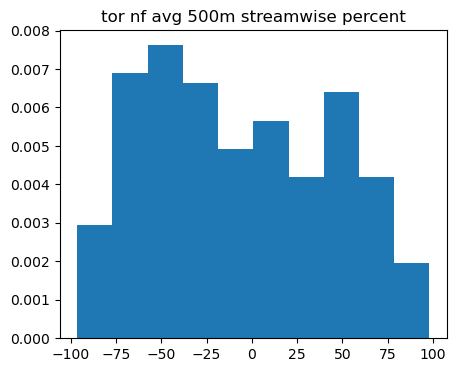

(240,)


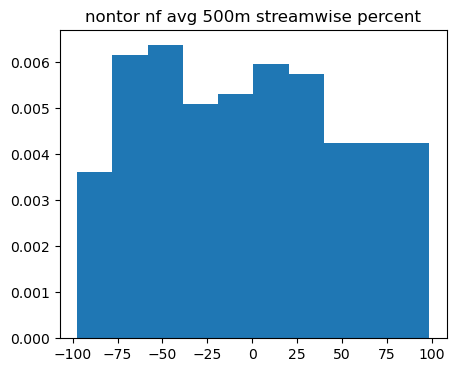

(495,)


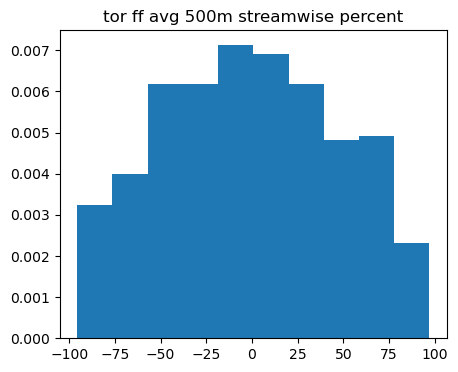

(760,)


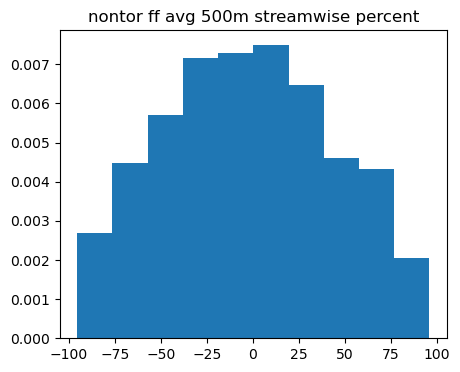

In [337]:
us = [nf_u_categories_new, nf_u_categories_new, ff_u_categories_new, ff_u_categories_new]
vs = [nf_v_categories_new, nf_v_categories_new, ff_v_categories_new, ff_v_categories_new]
cats = ['tor', 'nontor', 'tor', 'nontor']
eep = ['nf', 'nf', 'ff', 'ff']

for ucomp, vcomp, col, e in zip(us, vs, cats, eep):
    u = ucomp[col].iloc[:, :196]
    v = vcomp[col].iloc[:, :196]

    # ucompff = ucomp+1
    # vcompff = vcomp+1
    
    # uff = ucomp[col+1].iloc[:, :196]
    # vff = vcomp[col+1].iloc[:, :196]
    # print(len(u))
    
    percent_omega_s = percent_streamwise_vorticity(np.array(u), np.array(v), len(u))
    
    #percent_omega_s_ff = percent_streamwise_vorticity(np.array(uff), np.array(vff), len(uff))
    avg_omega_s_percent_500m = np.nanmean(percent_omega_s[:, :], axis=1)
    print(np.shape(avg_omega_s_percent_500m))
    fig = plt.figure(figsize=(5,4))
    counts, bins = np.histogram(avg_omega_s_percent_500m, density=True)
    plt.hist(bins[:-1], bins, weights=counts)
    plt.title(f'{col} {e} avg 500m streamwise percent')
    plt.show()

In [ ]:
tor_u_nf = np.nanmean(nf_u_categories['tor'].iloc[:, :196], axis=0)
tor_v_nf = np.nanmean(nf_v_categories['tor'].iloc[:, :196], axis=0)

pretor_u_nf = np.nanmean(nf_u_categories['pretor'].iloc[:, :196], axis=0)
pretor_v_nf = np.nanmean(nf_v_categories['pretor'].iloc[:, :196], axis=0)

dtor_u_nf = np.nanmean(nf_u_categories['dtor'].iloc[:, :196], axis=0)
dtor_v_nf = np.nanmean(nf_v_categories['dtor'].iloc[:, :196], axis=0)

posttor_u_nf = np.nanmean(nf_u_categories['posttor'].iloc[:, :196], axis=0)
posttor_v_nf = np.nanmean(nf_v_categories['posttor'].iloc[:, :196], axis=0)

nontor_u_nf = np.nanmean(nf_u_categories['nontor'].iloc[:, :196], axis=0)
nontor_v_nf = np.nanmean(nf_v_categories['nontor'].iloc[:, :196], axis=0)

In [ ]:
tor_u_ff = np.nanmean(ff_u_categories['tor'].iloc[:, :196], axis=0)
tor_v_ff = np.nanmean(ff_v_categories['tor'].iloc[:, :196], axis=0)

pretor_u_ff = np.nanmean(ff_u_categories['pretor'].iloc[:, :196], axis=0)
pretor_v_ff = np.nanmean(ff_v_categories['pretor'].iloc[:, :196], axis=0)

dtor_u_ff = np.nanmean(ff_u_categories['dtor'].iloc[:, :196], axis=0)
dtor_v_ff = np.nanmean(ff_v_categories['dtor'].iloc[:, :196], axis=0)

posttor_u_ff = np.nanmean(ff_u_categories['posttor'].iloc[:, :196], axis=0)
posttor_v_ff = np.nanmean(ff_v_categories['posttor'].iloc[:, :196], axis=0)

nontor_u_ff = np.nanmean(ff_u_categories['nontor'].iloc[:, :196], axis=0)
nontor_v_ff = np.nanmean(ff_v_categories['nontor'].iloc[:, :196], axis=0)

In [ ]:
tor_u_nf_new = np.nanmean(nf_u_categories_new['tor'].iloc[:, :196], axis=0)
tor_v_nf_new = np.nanmean(nf_v_categories_new['tor'].iloc[:, :196], axis=0)

pretor_u_nf_new = np.nanmean(nf_u_categories_new['pretor'].iloc[:, :196], axis=0)
pretor_v_nf_new = np.nanmean(nf_v_categories_new['pretor'].iloc[:, :196], axis=0)

dtor_u_nf_new = np.nanmean(nf_u_categories_new['dtor'].iloc[:, :196], axis=0)
dtor_v_nf_new = np.nanmean(nf_v_categories_new['dtor'].iloc[:, :196], axis=0)

posttor_u_nf_new = np.nanmean(nf_u_categories_new['posttor'].iloc[:, :196], axis=0)
posttor_v_nf_new = np.nanmean(nf_v_categories_new['posttor'].iloc[:, :196], axis=0)

nontor_u_nf_new = np.nanmean(nf_u_categories_new['nontor'].iloc[:, :196], axis=0)
nontor_v_nf_new = np.nanmean(nf_v_categories_new['nontor'].iloc[:, :196], axis=0)

In [ ]:
tor_u_ff_new = np.nanmean(ff_u_categories_new['tor'].iloc[:, :196], axis=0)
tor_v_ff_new = np.nanmean(ff_v_categories_new['tor'].iloc[:, :196], axis=0)

pretor_u_ff_new = np.nanmean(ff_u_categories_new['pretor'].iloc[:, :196], axis=0)
pretor_v_ff_new = np.nanmean(ff_v_categories_new['pretor'].iloc[:, :196], axis=0)

dtor_u_ff_new = np.nanmean(ff_u_categories_new['dtor'].iloc[:, :196], axis=0)
dtor_v_ff_new = np.nanmean(ff_v_categories_new['dtor'].iloc[:, :196], axis=0)

posttor_u_ff_new = np.nanmean(ff_u_categories_new['posttor'].iloc[:, :196], axis=0)
posttor_v_ff_new = np.nanmean(ff_v_categories_new['posttor'].iloc[:, :196], axis=0)

nontor_u_ff_new = np.nanmean(ff_u_categories_new['nontor'].iloc[:, :196], axis=0)
nontor_v_ff_new = np.nanmean(ff_v_categories_new['nontor'].iloc[:, :196], axis=0)

In [ ]:
hodo_plot([tor_u_nf, pretor_u_nf, dtor_u_nf, posttor_u_nf, nontor_u_nf], [tor_u_ff, pretor_v_nf, dtor_v_nf, posttor_v_nf, 
                                                                             nontor_v_nf], heights, 25, 
    'Near-Field Composites (No Comp Prior)', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tor', 'Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 30, 'lower left', 8,8)

In [ ]:
hodo_plot([tor_u_ff, pretor_u_ff, dtor_u_ff, posttor_u_ff, nontor_u_ff], [tor_v_ff, pretor_v_ff, dtor_v_ff, posttor_v_ff, 
                                                                             nontor_v_ff], heights, 25, 
    'Far-Field Composites', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tor', 'Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 30, 'lower left', 8,8)

In [ ]:
hodo_plot([pretor_u_nf_new, dtor_u_nf_new, posttor_u_nf_new, nontor_u_nf_new], [pretor_v_nf_new, dtor_v_nf_new, posttor_v_nf_new, 
                                                                             nontor_v_nf_new], heights, 25, 
    'Near-Field Composites (No Comp Prior) New 2ndTrip', ['tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 25, 'lower left', 8,8)

In [ ]:
hodo_plot([pretor_u_ff_new, dtor_u_ff_new, posttor_u_ff_new, nontor_u_ff_new], [pretor_v_ff_new, dtor_v_ff_new, posttor_v_nf_new, 
                                                                             nontor_v_nf_new], heights, 25, 
    'Far-Field Composites (No Comp Prior) New 2ndTrip', ['tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['Pre Tornadic', 'During Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 25, 'lower right', 8,8)

# Compositing cases

In [6]:
#csv_name = f'cases/case_dfs/new/{d}_uv_{ka}_all.csv'
nf_dist = 20
ff_dist = 20
angle0 = 0
angle1 = 90
angle2 = 315
tor_time = 0

In [7]:
comp_tor_all = pd.DataFrame()
comp_nontor_all = pd.DataFrame()

for ka in kas:
    for d in dates:
        comp_tor, comp_nontor = comp_per_case(f'case_dfs/new/{d}_uv_{ka}_all.csv', ka, d, nf_dist, ff_dist, angle0, angle1, angle2, tor_time)
        comp_tor_all = pd.concat([comp_tor_all, comp_tor])
        comp_nontor_all = pd.concat([comp_nontor_all, comp_nontor])

case_dfs/new/20220523_uv_ka1_all.csv
CSV size: (192, 201)
case_dfs/new/20220524_uv_ka1_all.csv
CSV size: (134, 201)
case_dfs/new/20220611_uv_ka1_all.csv
CSV size: (180, 201)
case_dfs/new/20230524_uv_ka1_all.csv
File not found: case_dfs/new/20230524_uv_ka1_all.csv
case_dfs/new/20230527_uv_ka1_all.csv
CSV size: (572, 201)
case_dfs/new/20230601_uv_ka1_all.csv
File not found: case_dfs/new/20230601_uv_ka1_all.csv
case_dfs/new/20230609_uv_ka1_all.csv
CSV size: (392, 201)
case_dfs/new/20230611_uv_ka1_all.csv
CSV size: (572, 201)
case_dfs/new/20230612_uv_ka1_all.csv
File not found: case_dfs/new/20230612_uv_ka1_all.csv
case_dfs/new/20230613_uv_ka1_all.csv
CSV size: (206, 201)
case_dfs/new/20230615_uv_ka1_all.csv
CSV size: (1974, 201)
case_dfs/new/20240427_uv_ka1_all.csv
CSV size: (388, 201)
case_dfs/new/20240501_uv_ka1_all.csv
CSV size: (1134, 201)
case_dfs/new/20240502_uv_ka1_all.csv
CSV size: (834, 201)
case_dfs/new/20240504_uv_ka1_all.csv


/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :

CSV size: (1134, 201)
case_dfs/new/20240506_uv_ka1_all.csv
File not found: case_dfs/new/20240506_uv_ka1_all.csv
case_dfs/new/2024051920240523_uv_ka1_all.csv
File not found: case_dfs/new/2024051920240523_uv_ka1_all.csv
case_dfs/new/20240528_uv_ka1_all.csv
CSV size: (1082, 201)
case_dfs/new/20240602_uv_ka1_all.csv
CSV size: (274, 201)
case_dfs/new/20220523_uv_ka2_all.csv
CSV size: (106, 201)
case_dfs/new/20220524_uv_ka2_all.csv
File not found: case_dfs/new/20220524_uv_ka2_all.csv
case_dfs/new/20220611_uv_ka2_all.csv
File not found: case_dfs/new/20220611_uv_ka2_all.csv
case_dfs/new/20230524_uv_ka2_all.csv
CSV size: (352, 201)
case_dfs/new/20230527_uv_ka2_all.csv
File not found: case_dfs/new/20230527_uv_ka2_all.csv
case_dfs/new/20230601_uv_ka2_all.csv
File not found: case_dfs/new/20230601_uv_ka2_all.csv
case_dfs/new/20230609_uv_ka2_all.csv
CSV size: (206, 201)
case_dfs/new/20230611_uv_ka2_all.csv
File not found: case_dfs/new/20230611_uv_ka2_all.csv
case_dfs/new/20230612_uv_ka2_all.csv
CSV 

/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :

In [8]:
comp_tor_all_new = pd.DataFrame()
comp_nontor_all_new = pd.DataFrame()

for ka in kas:
    for d in dates:
        for file in glob.glob(f'case_dfs/new/new_secondtrip/*/{d}_uv_{ka}_all.csv'):
            comp_tor_new, comp_nontor_new = comp_per_case(file, ka, d, nf_dist, ff_dist, angle0, angle1, angle2, tor_time)
            comp_tor_all_new = pd.concat([comp_tor_all_new, comp_tor_new])
            comp_nontor_all_new = pd.concat([comp_nontor_all_new, comp_nontor_new])

case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka1_all.csv


/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :

CSV size: (120, 201)
case_dfs/new/new_secondtrip/nontornadic/20220524_uv_ka1_all.csv
CSV size: (100, 201)
case_dfs/new/new_secondtrip/tornadic/20230527_uv_ka1_all.csv
CSV size: (506, 201)
case_dfs/new/new_secondtrip/nontornadic/20230611_uv_ka1_all.csv
CSV size: (388, 201)
case_dfs/new/new_secondtrip/nontornadic/20230613_uv_ka1_all.csv
CSV size: (20, 201)
case_dfs/new/new_secondtrip/tornadic/20230615_uv_ka1_all.csv
CSV size: (572, 201)
case_dfs/new/new_secondtrip/nontornadic/20240427_uv_ka1_all.csv
CSV size: (314, 201)
case_dfs/new/new_secondtrip/nontornadic/20240501_uv_ka1_all.csv
CSV size: (850, 201)
case_dfs/new/new_secondtrip/tornadic/20240502_uv_ka1_all.csv
CSV size: (784, 201)
case_dfs/new/new_secondtrip/nontornadic/20240504_uv_ka1_all.csv


/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:64: RuntimeWarning: Mean of empty slice
  ntseg_avg = np.nanmean(ntseg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:64: RuntimeWarning: Mean of empty slice
  ntseg_avg = np.nanmean(ntseg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:64: RuntimeWarning: Mean of empty slice
  ntseg_avg = np.nanmean(nts

CSV size: (780, 201)
case_dfs/new/new_secondtrip/nontornadic/20240528_uv_ka1_all.csv
CSV size: (1050, 201)
case_dfs/new/new_secondtrip/tornadic/20240602_uv_ka1_all.csv
CSV size: (262, 201)
case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka2_all.csv
CSV size: (20, 201)
case_dfs/new/new_secondtrip/tornadic/20230524_uv_ka2_all.csv
CSV size: (284, 201)
case_dfs/new/new_secondtrip/nontornadic/20230612_uv_ka2_all.csv
CSV size: (198, 201)
case_dfs/new/new_secondtrip/tornadic/20230615_uv_ka2_all.csv
CSV size: (352, 201)


/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/2108177669.py:41: RuntimeWarning: Mean of empty slice
  seg_avg = np.nanmean(seg.iloc[:, :

In [9]:
comp_tor_all.date.value_counts()

date
20220523    32
20230615    32
20230527    16
20240602    16
20230524    16
Name: count, dtype: int64

In [10]:
comp_tor_all.dropna(inplace=True)

In [11]:
comp_tor_all.date.value_counts()

date
20230615    22
20220523    18
20230527    14
20230524    10
Name: count, dtype: int64

In [12]:
comp_nontor_all.dropna(inplace=True)

In [13]:
comp_nontor_all.date.value_counts()

date
20220524    4
20230609    4
20240504    4
20230611    2
20230613    2
20240427    2
20240501    2
20240502    2
20240528    2
20230612    2
Name: count, dtype: int64

In [14]:
comp_tor_all_new.date.value_counts()

date
20220523    32
20230615    32
20230527    16
20240502    16
20240602    16
20230524    16
Name: count, dtype: int64

In [15]:
comp_tor_all_new.dropna(inplace=True)

In [16]:
comp_nontor_all_new.dropna(inplace=True)

In [17]:
comp_tor_all_new.date.value_counts()

date
20230615    22
20220523    14
20230527    14
20230524     8
20240502     4
Name: count, dtype: int64

In [18]:
comp_tor_all_new.label.value_counts()

label
tor ff        12
tor nf        12
posttor nf    12
posttor ff    10
pretor ff      8
dtor ff        4
pretor nf      2
dtor nf        2
Name: count, dtype: int64

In [19]:
def comp_srh(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in np.arange(0, 194):
        
        a = np.nanprod([u.iloc[:, i+1], v.iloc[:, i]], axis=0)
        b = -np.nanprod([u.iloc[:, i], v.iloc[:, i+1]],axis=0)
        
        srh0 = np.nansum([a, b], axis=0)
        srh.append(srh0)
        
    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh

In [20]:
def comp_srh_nan(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in range(len(u)-1):
        a = np.nanprod([u[i+1], v[i]], axis=0) 
        b = -np.nanprod([u[i], v[i+1]], axis=0)
        srh0 = np.nansum([a,b], axis=0)
        srh.append(srh0) # srh at each height

    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh_total

(10,)
['20220524', '20230609', '20230611', '20230612', '20230613', '20240427', '20240501', '20240502', '20240504', '20240528']
20220524


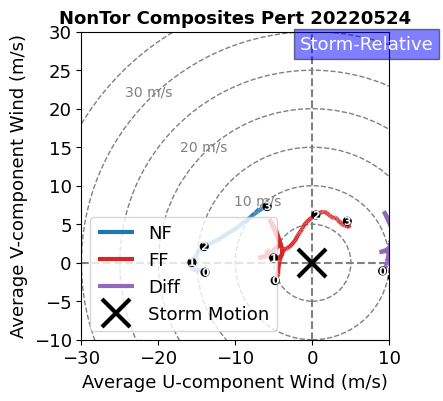

nf_srh-ff_srh = 81.06520805041403
20230609
20230611
20230612
20230613
20240427
20240501
20240502
20240504


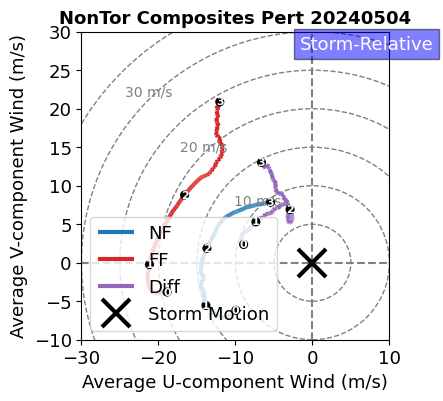

nf_srh-ff_srh = -226.17832065717698
20240528


In [26]:
dates_eh = sorted(set(comp_nontor_all['date'].values))
print(np.shape(dates_eh))
print(dates_eh)
nontor_srh_df = pd.DataFrame()

for d in dates_eh:
    print(d)
    comp_date = comp_nontor_all[comp_nontor_all['date'] == d]
    
    #if (comp_date['label'].eq('nontor nf').any()) or (comp_date['label'].eq('nontor ff').any()):
    if (comp_date['label'].eq('nontor ff').any()) and (comp_date['label'].eq('nontor nf').any()):
        
        u_nf = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'nontor nf')].iloc[:, :196].values, axis=0)
        v_nf = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'nontor nf')].iloc[:, :196].values, axis=0)
        u_ff = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'nontor ff')].iloc[:, :196].values, axis=0)
        v_ff = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'nontor ff')].iloc[:, :196].values, axis=0)
        # print(np.shape(v_nf))
        delta_u = u_ff - u_nf
        delta_v = v_ff - v_nf
        
        hodo_plot([u_nf, u_ff, delta_u], [v_nf, v_ff, delta_v], heights, 25, f'NonTor Composites Pert {d}', 
                  ['tab:blue', 'tab:red', 'tab:purple'], ['NF', 'FF', 'Diff'], 10, 30, 'lower left',4,4)

        nf_srh = comp_srh_nan(u_nf, v_nf)
        ff_srh = comp_srh_nan(u_ff, v_ff)
        
        delta_srh = nf_srh - ff_srh

        nontor_srh = pd.DataFrame()
        
        nontor_srh['Date'] = [d]
        nontor_srh['NF_SRH'] = [nf_srh]
        nontor_srh['FF_SRH'] = [ff_srh]
        nontor_srh['delta_SRH'] = [delta_srh]
        
        nontor_srh_df = pd.concat([nontor_srh_df, nontor_srh])
        

        print(f'nf_srh-ff_srh = {delta_srh}')
    else:
        continue

(7,)
['20220524', '20230611', '20230613', '20240427', '20240501', '20240504', '20240528']
20220524


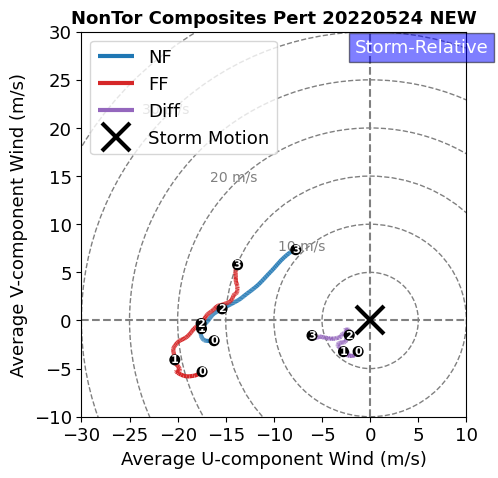

nf_srh-ff_srh = -47.77342337495264
20230611
20230613
20240427
20240501
20240504


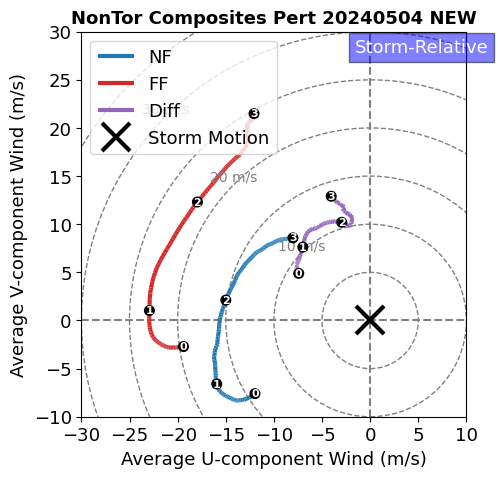

nf_srh-ff_srh = -283.03114496658566
20240528


In [292]:
dates_eh = sorted(set(comp_nontor_all_new['date'].values))
print(np.shape(dates_eh))
print(dates_eh)
nontor_srh_df_new = pd.DataFrame()
nontor_winds_new = pd.DataFrame()
nontor_both_date = []

for d in dates_eh:
    print(d)
    comp_date = comp_nontor_all_new[comp_nontor_all_new['date'] == d]
    
    #if (comp_date['label'].eq('nontor nf').any()) or (comp_date['label'].eq('nontor ff').any()):
    if (comp_date['label'].eq('nontor ff').any()) and (comp_date['label'].eq('nontor nf').any()):

        nontor_nf_ff = pd.DataFrame()
        
        u_nf = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'nontor nf')].iloc[:, :196].values, axis=0)
        v_nf = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'nontor nf')].iloc[:, :196].values, axis=0)
        u_ff = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'nontor ff')].iloc[:, :196].values, axis=0)
        v_ff = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'nontor ff')].iloc[:, :196].values, axis=0)

        #nontor_nf_ff = pd.DataFrame([d, u_nf, v_nf, u_ff, v_ff], columns = ['Date', 'NF_u_mean', 'NF_v_mean', 'FF_u_mean', 'FF_v_mean']).T

        #nontor_nf_ff = pd.DataFrame([d], [u_nf], [v_nf], [u_ff], [v_ff], index = [0,1,2,3,4])#, columns = ['Date', 'NF_u_mean', 'NF_v_mean', 'FF_u_mean', 'FF_v_mean'])
        
        #nontor_nf_ff['Date'] = [d]
        # nontor_nf_ff['NF_u_mean'] = [u_nf]
        # nontor_nf_ff['NF_v_mean'] = [v_nf]
        # nontor_nf_ff['FF_u_mean'] = [u_ff]
        # nontor_nf_ff['FF_v_mean'] = [v_ff]


        nontor_nf_ff['Date'] = [d] * len(u_nf)
        nontor_nf_ff['NF_u_mean'] = pd.Series(u_nf)
        nontor_nf_ff['NF_v_mean'] = pd.Series(v_nf)
        nontor_nf_ff['FF_u_mean'] = pd.Series(u_ff)
        nontor_nf_ff['FF_v_mean'] = pd.Series(v_ff)

        nontor_winds_new = pd.concat([nontor_winds_new, nontor_nf_ff])
        #nontor_both_date.append(d)
        
        delta_u = u_ff - u_nf
        delta_v = v_ff - v_nf
        
        hodo_plot([u_nf, u_ff, delta_u], [v_nf, v_ff, delta_v], heights, 25, f'NonTor Composites Pert {d} NEW', 
                  ['tab:blue', 'tab:red', 'tab:purple'], ['NF', 'FF', 'Diff'], 10, 30, 'upper left',5,5)

        nf_srh = comp_srh_nan(u_nf, v_nf)
        ff_srh = comp_srh_nan(u_ff, v_ff)
        
        delta_srh = nf_srh - ff_srh
        print(f'nf_srh-ff_srh = {delta_srh}')

        # nf_srh = comp_srh_nan(u_nf, v_nf)
        # ff_srh = comp_srh_nan(u_ff, v_ff)
        
        # delta_srh = nf_srh - ff_srh
        # print(f'nf_srh-ff_srh = {delta_srh}')

        nontor_srh = pd.DataFrame()
        
        nontor_srh['Date'] = [d]
        nontor_srh['NF_SRH'] = [nf_srh]
        nontor_srh['FF_SRH'] = [ff_srh]
        nontor_srh['delta_SRH'] = [delta_srh]
        
        nontor_srh_df_new = pd.concat([nontor_srh_df_new, nontor_srh])
        

    else:
        continue

In [290]:
nontor_nf_ff.T

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,193,194,195
Date,20240504,20240504,20240504,20240504,20240504,20240504,20240504,20240504,20240504,20240504,...,20240504,20240504,20240504,20240504,20240504,20240504,20240504,20240504,20240504,20240504
NF_u_mean,-11.970827,-12.110954,-12.229342,-12.341393,-12.338688,-12.563894,-12.650652,-12.837542,-12.93464,-13.085423,...,-8.599787,-8.542218,-8.476628,-8.408803,-8.34613,-8.268741,-8.207514,-8.150803,-8.073345,-8.019696
NF_v_mean,-7.602431,-7.719689,-7.810626,-7.877585,-7.878881,-8.023958,-8.052881,-8.135141,-8.172237,-8.210371,...,8.492443,8.51289,8.521512,8.537522,8.537872,8.560544,8.568481,8.57198,8.572028,8.583173
FF_u_mean,-19.393111,-19.554825,-19.699619,-19.837123,-19.837867,-20.116909,-20.229192,-20.455041,-20.571637,-20.751744,...,-12.19536,-12.180539,-12.158955,-12.073994,-12.202532,-12.171419,-12.141907,-12.116908,-12.087549,-12.06525
FF_v_mean,-2.708608,-2.743208,-2.760552,-2.772774,-2.772931,-2.805669,-2.804847,-2.812489,-2.815066,-2.81265,...,20.918299,20.963921,21.005596,21.073384,21.275614,21.314415,21.356755,21.398632,21.44827,21.490213


In [295]:
nontor_winds_new

,Date,NF_u_mean,NF_v_mean,FF_u_mean,FF_v_mean
0,20220524,-16.211269,-2.104942,-17.461899,-5.331043
1,20220524,-16.321700,-2.108024,-17.625797,-5.440126
2,20220524,-16.415494,-2.111213,-17.773840,-5.546739
3,20220524,-16.494933,-2.114390,-17.926640,-5.618486
4,20220524,-16.670186,-2.121468,-18.257471,-5.741157
...,...,...,...,...,...
191,20240504,-8.268741,8.560544,-12.171419,21.314415
192,20240504,-8.207514,8.568481,-12.141907,21.356755
193,20240504,-8.150803,8.571980,-12.116908,21.398632
194,20240504,-8.073345,8.572028,-12.087549,21.448270


(4,)
['20220523', '20230524', '20230527', '20230615']
20220523


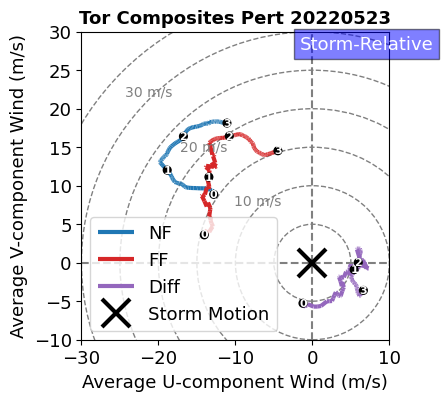

nf_srh-ff_srh = -60.837827017564535
20230524


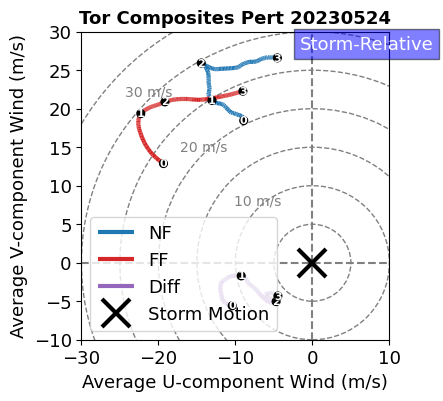

nf_srh-ff_srh = -195.22431051480666
20230527


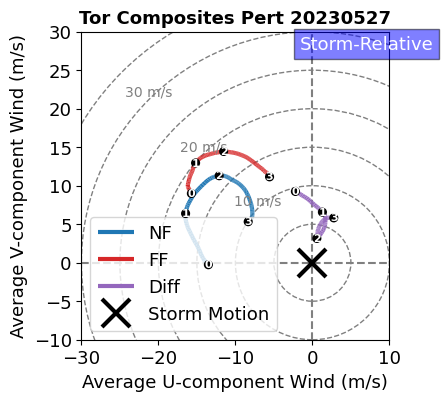

nf_srh-ff_srh = 4.630424664435793
20230615


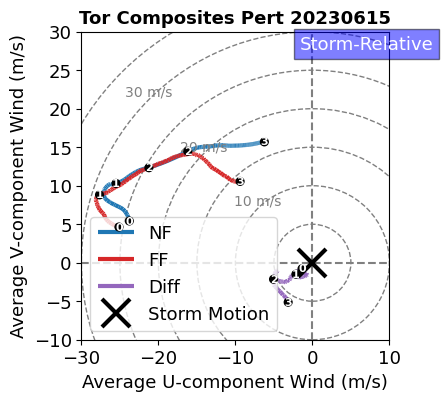

nf_srh-ff_srh = 92.96911006099401


In [27]:
dates_eh = sorted(set(comp_tor_all['date'].values))
print(np.shape(dates_eh))
print(dates_eh)
tor_srh_df = pd.DataFrame()
for d in dates_eh:
    print(d)
    comp_date = comp_tor_all[comp_tor_all['date'] == d]
    
    if (comp_date['label'].eq('tor nf').any()) and (comp_date['label'].eq('tor ff').any()):
        
        u_nf = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'tor nf')].iloc[:, :196].values, axis=0)
        v_nf = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'tor nf')].iloc[:, :196].values, axis=0)
        u_ff = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'tor ff')].iloc[:, :196].values, axis=0)
        v_ff = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'tor ff')].iloc[:, :196].values, axis=0)
    
        delta_u = u_ff - u_nf
        delta_v = v_ff - v_nf
        
        hodo_plot([u_nf, u_ff, delta_u], [v_nf, v_ff, delta_v], heights, 25, f'Tor Composites Pert {d}', 
                  ['tab:blue', 'tab:red', 'tab:purple'], ['NF', 'FF', 'Diff'], 10, 30, 'lower left',4,4)

        nf_srh = comp_srh_nan(u_nf, v_nf)
        ff_srh = comp_srh_nan(u_ff, v_ff)
        
        delta_srh = nf_srh - ff_srh
        print(f'nf_srh-ff_srh = {delta_srh}')

        tor_srh = pd.DataFrame()
        
        tor_srh['Date'] = [d]
        tor_srh['NF_SRH'] = [nf_srh]
        tor_srh['FF_SRH'] = [ff_srh]
        tor_srh['delta_SRH'] = [delta_srh]
        
        tor_srh_df = pd.concat([tor_srh_df, tor_srh])
        

    else:
        continue

In [ ]:
tor_srh_df

(5,)
['20220523', '20230524', '20230527', '20230615', '20240502']
20220523


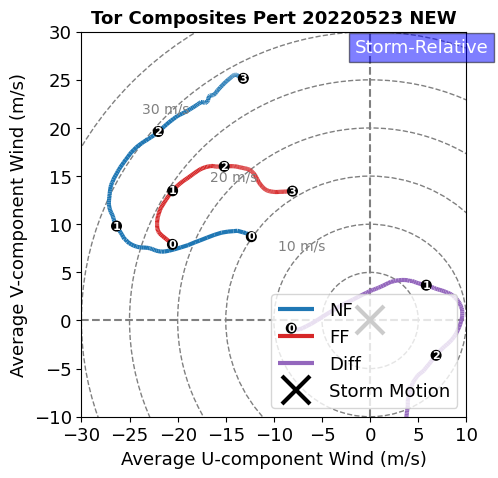

nf_srh-ff_srh = 226.253871170021
20230524


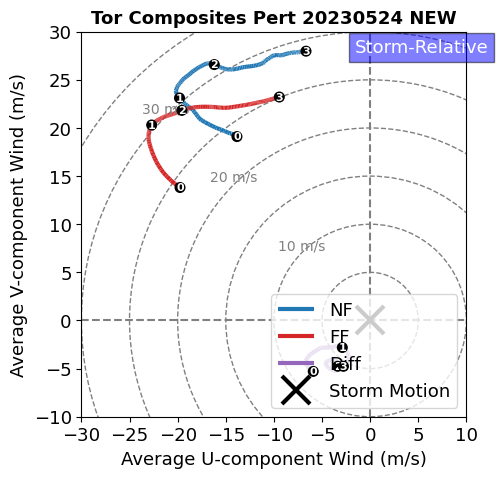

nf_srh-ff_srh = -66.49263337893467
20230527


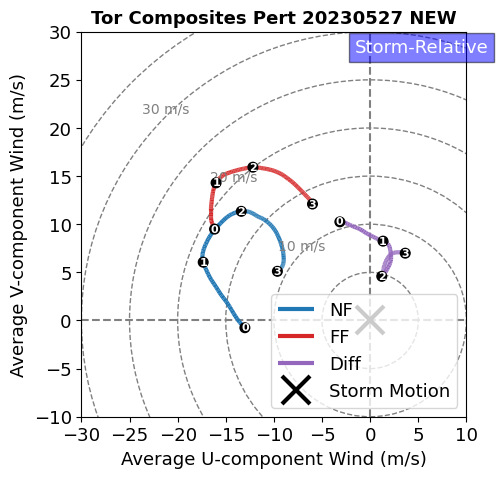

nf_srh-ff_srh = -24.82010480006622
20230615


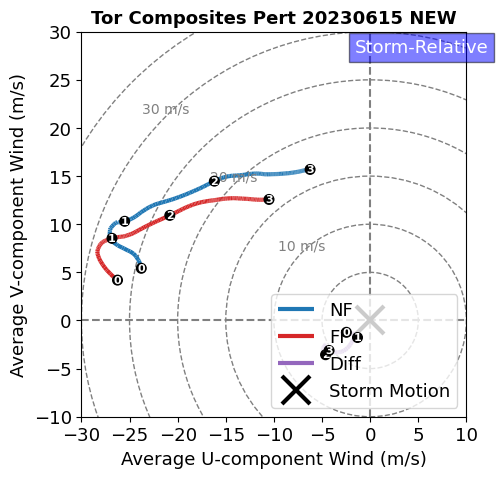

nf_srh-ff_srh = 93.45984165845266
20240502


In [274]:
dates_eh = sorted(set(comp_tor_all_new['date'].values))
print(np.shape(dates_eh))
print(dates_eh)
tor_srh_df_new = pd.DataFrame()

tor_winds_new = pd.DataFrame()

tor_both_dates = []

for d in dates_eh:
    print(d)
    comp_date = comp_tor_all_new[comp_tor_all_new['date'] == d]
    
    if (comp_date['label'].eq('tor nf').any()) and (comp_date['label'].eq('tor ff').any()):

        #tor_nf_ff = pd.DataFrame(columns = ['NF_u_mean', 'NF_v_mean', 'FF_u_mean', 'FF_v_mean'])
        tor_nf_ff = pd.DataFrame()
        
        u_nf = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'tor nf')].iloc[:, :196].values, axis=0)
        v_nf = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'tor nf')].iloc[:, :196].values, axis=0)
        u_ff = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'tor ff')].iloc[:, :196].values, axis=0)
        v_ff = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'tor ff')].iloc[:, :196].values, axis=0)

        # tor_nf_ff['Date'] = [d]

        # tor_nf_ff.loc[0, :] = u_nf
        # tor_nf_ff.loc[1, :] = v_nf
        # tor_nf_ff.loc[2, :] = u_ff
        # tor_nf_ff.loc[3, :] = v_ff

            
        # tor_nf_ff['Date'] = [d]
        # tor_nf_ff['NF_u_mean'] = np.array(u_nf)
        # tor_nf_ff['NF_v_mean'] = np.array(v_nf)
        # tor_nf_ff['FF_u_mean'] = np.array(u_ff)
        # tor_nf_ff['FF_v_mean'] = np.array(v_ff)

        tor_nf_ff['Date'] = [d] * len(u_nf)
        tor_nf_ff['NF_u_mean'] = pd.Series(u_nf)
        tor_nf_ff['NF_v_mean'] = pd.Series(v_nf)
        tor_nf_ff['FF_u_mean'] = pd.Series(u_ff)
        tor_nf_ff['FF_v_mean'] = pd.Series(v_ff)

        tor_winds_new = pd.concat([tor_winds_new, tor_nf_ff])

        tor_both_dates.append(d)
        
        delta_u = u_ff - u_nf
        delta_v = v_ff - v_nf
        hodo_plot([u_nf, u_ff, delta_u], [v_nf, v_ff, delta_v], heights, 25, f'Tor Composites Pert {d} NEW', 
                  ['tab:blue', 'tab:red', 'tab:purple'], ['NF', 'FF', 'Diff'], 10, 30, 'lower right',5,5)

        nf_srh = comp_srh_nan(u_nf, v_nf)
        ff_srh = comp_srh_nan(u_ff, v_ff)
        
        delta_srh = nf_srh - ff_srh
        print(f'nf_srh-ff_srh = {delta_srh}')

        tor_srh = pd.DataFrame()
        
        tor_srh['Date'] = [d]
        tor_srh['NF_SRH'] = [nf_srh]
        tor_srh['FF_SRH'] = [ff_srh]
        tor_srh['delta_SRH'] = [delta_srh]
        
        tor_srh_df_new = pd.concat([tor_srh_df_new, tor_srh])
        

    else:
        continue

In [285]:
tor_winds_new['NF_u_mean']

0     -12.344266
1     -12.622243
2     -12.917190
3     -13.206150
4     -13.793958
         ...    
191    -6.466870
192    -6.404276
193    -6.355554
194    -6.290848
195    -6.241103
Name: NF_u_mean, Length: 784, dtype: float64

In [279]:
np.nanmean(tor_winds_new['NF_u_mean'], axis=0)

-15.909028420040187

In [ ]:
tor_srh_df

In [ ]:
nontor_srh_df

In [ ]:
tor_srh_df_new

In [ ]:
nontor_srh_df_new

In [ ]:
comp_tor_all_new

In [ ]:
dates_eh = sorted(set(comp_tor_all['date'].values))
#print(np.shape(dates_eh))
#print(dates_eh)
septor_srh_df = pd.DataFrame()

for d in dates_eh:
    #print(d)
    comp_date = comp_tor_all[comp_tor_all['date'] == d]
    
    if ((comp_date['label'].eq('pretor nf').any()) and (comp_date['label'].eq('pretor ff').any())) or ((comp_date['label'].eq('dtor nf').any()) and (comp_date['label'].eq('dtor ff').any())):

    #if ((comp_date['label'].eq('pretor nf').any()) and (comp_date['label'].eq('pretor ff').any())):

        print(d)
        
        pre_u_nf = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor nf')].iloc[:, :196].values, axis=0)
        pre_v_nf = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor nf')].iloc[:, :196].values, axis=0)
        pre_u_ff = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor ff')].iloc[:, :196].values, axis=0)
        pre_v_ff = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor ff')].iloc[:, :196].values, axis=0)

        d_u_nf = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor nf')].iloc[:, :196].values, axis=0)
        d_v_nf = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor nf')].iloc[:, :196].values, axis=0)
        d_u_ff = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor ff')].iloc[:, :196].values, axis=0)
        d_v_ff = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor ff')].iloc[:, :196].values, axis=0)
    
        pre_delta_u = pre_u_ff - pre_u_nf
        pre_delta_v = pre_v_ff - pre_v_nf

        d_delta_u = d_u_ff - d_u_nf
        d_delta_v = d_v_ff - d_v_nf
        
        # hodo_plot([pre_u_nf, pre_u_ff, predelta_u], [v_nf, v_ff, delta_v], heights, 25, f'Tor Composites Pert {d} NEW', 
        #           ['tab:blue', 'tab:red', 'tab:purple'], ['NF', 'FF', 'Diff'], 10, 30, 'lower left')

        pre_nf_srh = comp_srh_nan(pre_u_nf, pre_v_nf)
        pre_ff_srh = comp_srh_nan(pre_u_ff, pre_v_ff)

        d_nf_srh = comp_srh_nan(d_u_nf, d_v_nf)
        d_ff_srh = comp_srh_nan(d_u_ff, d_v_ff)
        
        pre_delta_srh = pre_nf_srh - pre_ff_srh
        d_delta_srh = d_nf_srh - d_ff_srh
        
        print(f'nf_srh-ff_srh = {delta_srh}')

        tor_srh = pd.DataFrame()
        
        tor_srh['Date'] = [d]
        tor_srh['PRE_NF_SRH'] = [pre_nf_srh]
        tor_srh['PRE_FF_SRH'] = [pre_ff_srh]
        
        tor_srh['D_NF_SRH'] = [d_nf_srh]
        tor_srh['D_FF_SRH'] = [d_ff_srh]
        
        tor_srh['PRE_delta_SRH'] = [pre_delta_srh]
        tor_srh['D_delta_SRH'] = [d_delta_srh]
        
        septor_srh_df = pd.concat([septor_srh_df, tor_srh])
        

    else:
        continue

In [ ]:
septor_srh_df

In [ ]:
dates_eh = sorted(set(comp_tor_all_new['date'].values))
#print(np.shape(dates_eh))
#print(dates_eh)
septor_srh_df_new = pd.DataFrame()

for d in dates_eh:
    #print(d)
    comp_date = comp_tor_all_new[comp_tor_all_new['date'] == d]
    
    if ((comp_date['label'].eq('pretor nf').any()) and (comp_date['label'].eq('pretor ff').any())) or ((comp_date['label'].eq('dtor nf').any()) and (comp_date['label'].eq('dtor ff').any())):

    #if ((comp_date['label'].eq('dtor nf').any()) and (comp_date['label'].eq('dtor ff').any())):

        print(d)
        
        pre_u_nf = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor nf')].iloc[:, :196].values, axis=0)
        pre_v_nf = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor nf')].iloc[:, :196].values, axis=0)
        pre_u_ff = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor ff')].iloc[:, :196].values, axis=0)
        pre_v_ff = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor ff')].iloc[:, :196].values, axis=0)

        d_u_nf = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor nf')].iloc[:, :196].values, axis=0)
        d_v_nf = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor nf')].iloc[:, :196].values, axis=0)
        d_u_ff = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor ff')].iloc[:, :196].values, axis=0)
        d_v_ff = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor ff')].iloc[:, :196].values, axis=0)
    
        pre_delta_u = pre_u_ff - pre_u_nf
        pre_delta_v = pre_v_ff - pre_v_nf

        d_delta_u = d_u_ff - d_u_nf
        d_delta_v = d_v_ff - d_v_nf
        
        # hodo_plot([pre_u_nf, pre_u_ff, predelta_u], [v_nf, v_ff, delta_v], heights, 25, f'Tor Composites Pert {d} NEW', 
        #           ['tab:blue', 'tab:red', 'tab:purple'], ['NF', 'FF', 'Diff'], 10, 30, 'lower left')

        pre_nf_srh = comp_srh_nan(pre_u_nf, pre_v_nf)
        pre_ff_srh = comp_srh_nan(pre_u_ff, pre_v_ff)

        d_nf_srh = comp_srh_nan(d_u_nf, d_v_nf)
        d_ff_srh = comp_srh_nan(d_u_ff, d_v_ff)
        
        pre_delta_srh = pre_nf_srh - pre_ff_srh
        d_delta_srh = d_nf_srh - d_ff_srh
        
        print(f'nf_srh-ff_srh = {delta_srh}')

        tor_srh = pd.DataFrame()
        
        tor_srh['Date'] = [d]
        tor_srh['PRE_NF_SRH'] = [pre_nf_srh]
        tor_srh['PRE_FF_SRH'] = [pre_ff_srh]
        
        tor_srh['D_NF_SRH'] = [d_nf_srh]
        tor_srh['D_FF_SRH'] = [d_ff_srh]
        
        tor_srh['PRE_delta_SRH'] = [pre_delta_srh]
        tor_srh['D_delta_SRH'] = [d_delta_srh]
        
        septor_srh_df_new = pd.concat([septor_srh_df_new, tor_srh])
        

    else:
        continue

In [ ]:
septor_srh_df_new

In [104]:
nontor_srh_df_new

,Date,NF_SRH,FF_SRH,delta_SRH
0,20220524,160.111707,207.885130,-47.773423
0,20240504,317.558591,600.589736,-283.031145


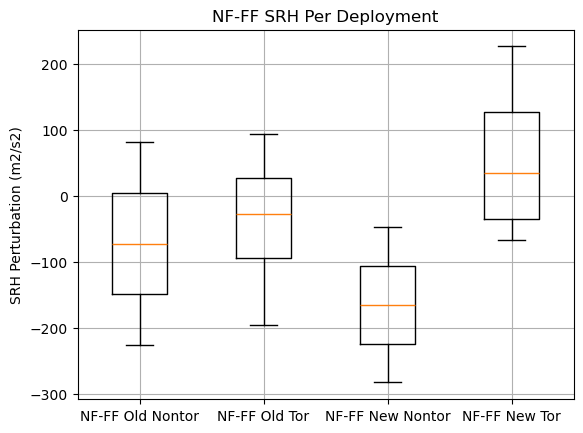

In [105]:
plt.boxplot([nontor_srh_df['delta_SRH'], tor_srh_df['delta_SRH'], nontor_srh_df_new['delta_SRH'], tor_srh_df_new['delta_SRH']],
           labels = ['NF-FF Old Nontor','NF-FF Old Tor', 'NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('SRH Perturbation (m2/s2)')
plt.title('NF-FF SRH Per Deployment')
plt.grid()
plt.show()

In [30]:
def averaging_u_and_v(comp_tor_all, comp_nontor_all):

    tor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'tor nf')].iloc[:, :196], axis=0)
    tor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'tor nf')].iloc[:, :196], axis=0)

    tor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'tor ff')].iloc[:, :196], axis=0)
    tor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'tor ff')].iloc[:, :196], axis=0)
    
    pretor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'pretor nf')].iloc[:, :196], axis=0)
    pretor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'pretor nf')].iloc[:, :196], axis=0)
    
    dtor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'dtor nf')].iloc[:, :196], axis=0)
    dtor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'dtor nf')].iloc[:, :196], axis=0)
    
    posttor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'posttor nf')].iloc[:, :196], axis=0)
    posttor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'posttor nf')].iloc[:, :196], axis=0)
    
    pretor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'pretor ff')].iloc[:, :196], axis=0)
    pretor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'pretor ff')].iloc[:, :196], axis=0)
    
    dtor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'dtor ff')].iloc[:, :196], axis=0)
    dtor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'dtor ff')].iloc[:, :196], axis=0)
    
    posttor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'posttor ff')].iloc[:, :196], axis=0)
    posttor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'posttor ff')].iloc[:, :196], axis=0)

    nontor_u_nf = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'u') & (comp_nontor_all['label'] == 'nontor nf')].iloc[:, :196], axis=0)
    nontor_v_nf = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'v') & (comp_nontor_all['label'] == 'nontor nf')].iloc[:, :196], axis=0)
    
    nontor_u_ff = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'u') & (comp_nontor_all['label'] == 'nontor ff')].iloc[:, :196], axis=0)
    nontor_v_ff = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'v') & (comp_nontor_all['label'] == 'nontor ff')].iloc[:, :196], axis=0)

    return locals()

In [31]:
old_2ndtrip = averaging_u_and_v(comp_tor_all, comp_nontor_all)
new_2ndtrip = averaging_u_and_v(comp_tor_all_new, comp_nontor_all_new)

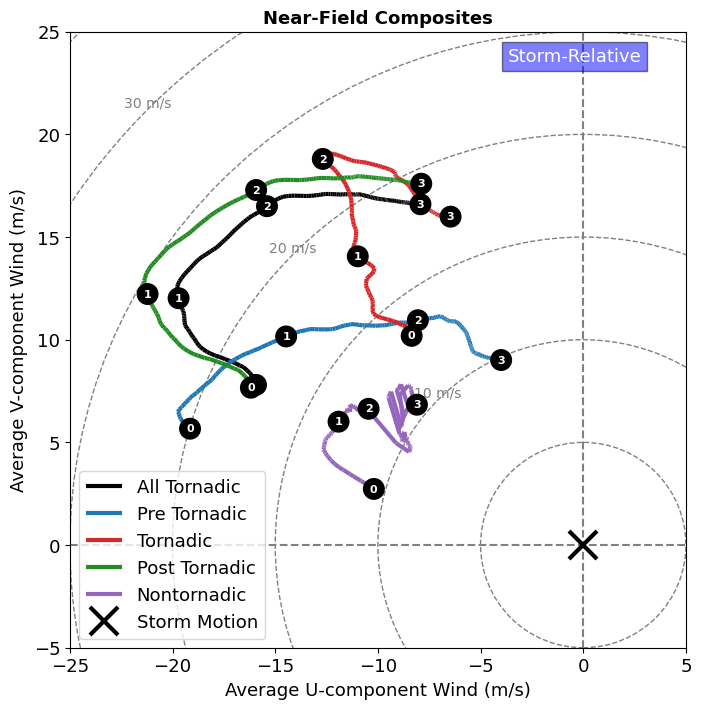

In [32]:
hodo_plot([old_2ndtrip['tor_u_nf'], old_2ndtrip['pretor_u_nf'], old_2ndtrip['dtor_u_nf'], old_2ndtrip['posttor_u_nf'], 
           old_2ndtrip['nontor_u_nf']], 
           [old_2ndtrip['tor_v_nf'], old_2ndtrip['pretor_v_nf'], old_2ndtrip['dtor_v_nf'], old_2ndtrip['posttor_v_nf'], old_2ndtrip['nontor_v_nf']], heights, 25, 
    'Near-Field Composites', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tornadic', 'Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 25, 'lower left', 8, 8)

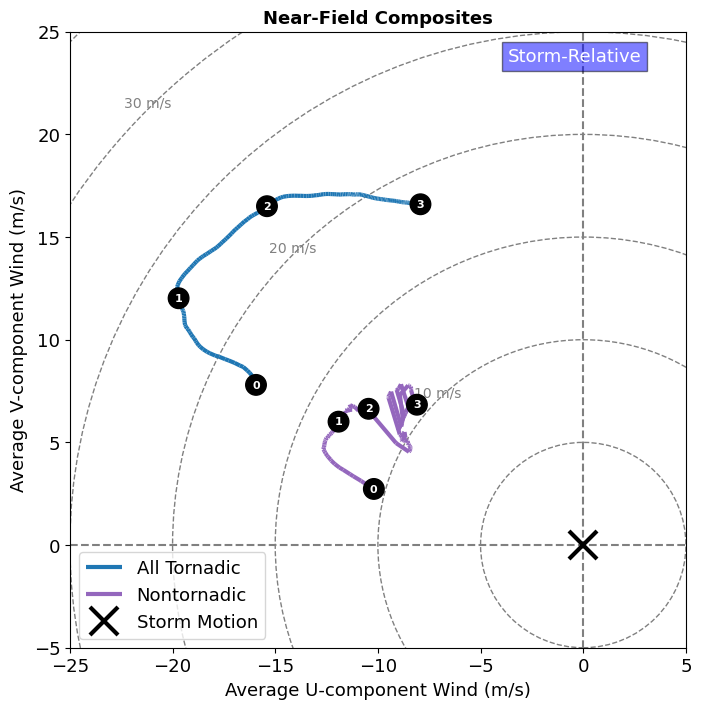

In [33]:
hodo_plot([old_2ndtrip['tor_u_nf'], old_2ndtrip['nontor_u_nf']], [old_2ndtrip['tor_v_nf'], old_2ndtrip['nontor_v_nf']], heights, 25, 
    'Near-Field Composites', ['tab:blue', 'tab:purple'], 
    ['All Tornadic', 'Nontornadic'], 5, 25, 'lower left', 8,8)

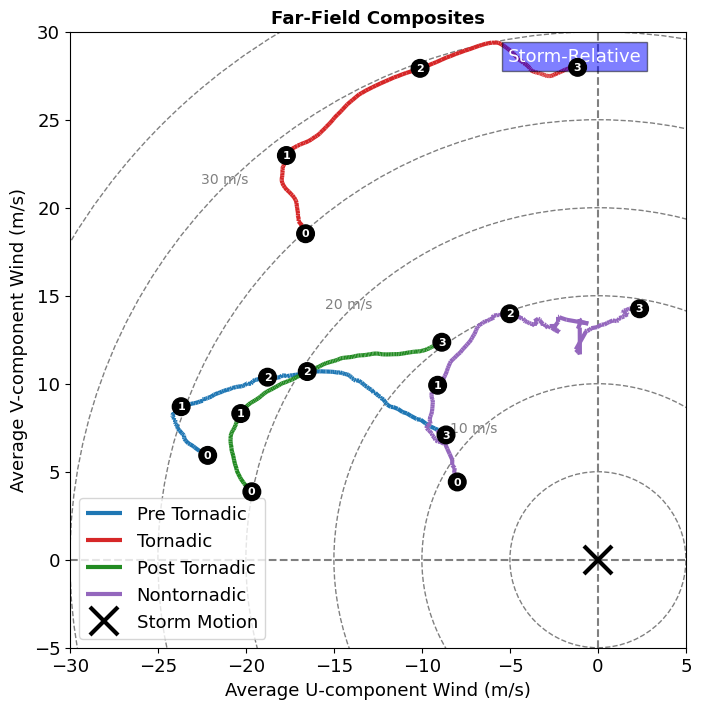

In [34]:
hodo_plot([old_2ndtrip['pretor_u_ff'], old_2ndtrip['dtor_u_ff'], old_2ndtrip['posttor_u_ff'], old_2ndtrip['nontor_u_ff']], 
           [old_2ndtrip['pretor_v_ff'], old_2ndtrip['dtor_v_ff'], old_2ndtrip['posttor_v_ff'], old_2ndtrip['nontor_v_ff']], heights, 25, 
    'Far-Field Composites', ['tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 30, 'lower left', 8,8)

In [ ]:
hodo_plot([old_2ndtrip['tor_u_ff'], old_2ndtrip['nontor_u_ff']], [old_2ndtrip['tor_v_ff'], old_2ndtrip['nontor_v_ff']], heights, 25, 
    'Far-Field Composites', ['tab:blue', 'tab:purple'], 
    ['All Tornadic', 'Nontornadic'], 5, 25, 'lower left')

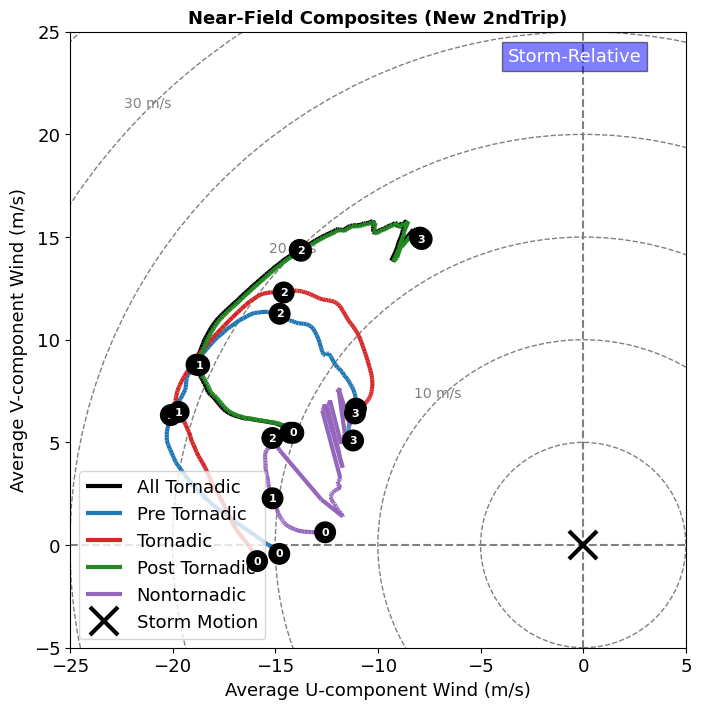

In [35]:
hodo_plot([new_2ndtrip['tor_u_nf'], new_2ndtrip['pretor_u_nf'], new_2ndtrip['dtor_u_nf'], new_2ndtrip['posttor_u_nf'], new_2ndtrip['nontor_u_nf']], 
           [new_2ndtrip['tor_v_nf'], new_2ndtrip['pretor_v_nf'], new_2ndtrip['dtor_v_nf'], new_2ndtrip['posttor_v_nf'], new_2ndtrip['nontor_v_nf']], heights, 25, 
    'Near-Field Composites (New 2ndTrip)', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tornadic', 'Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 25, 'lower left', 8,8)

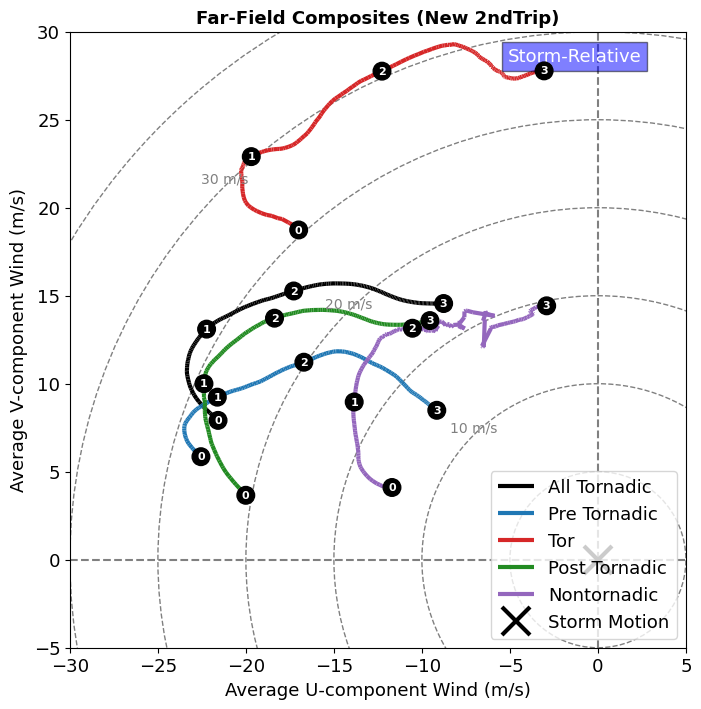

In [36]:
hodo_plot([new_2ndtrip['tor_u_ff'], new_2ndtrip['pretor_u_ff'], new_2ndtrip['dtor_u_ff'], new_2ndtrip['posttor_u_ff'], new_2ndtrip['nontor_u_ff']], 
           [new_2ndtrip['tor_v_ff'], new_2ndtrip['pretor_v_ff'],new_2ndtrip['dtor_v_ff'], new_2ndtrip['posttor_v_ff'], new_2ndtrip['nontor_v_ff']], heights, 25, 
    'Far-Field Composites (New 2ndTrip)', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tornadic','Pre Tornadic', 'Tor', 'Post Tornadic', 'Nontornadic'], 5, 30, 'lower right',8,8)

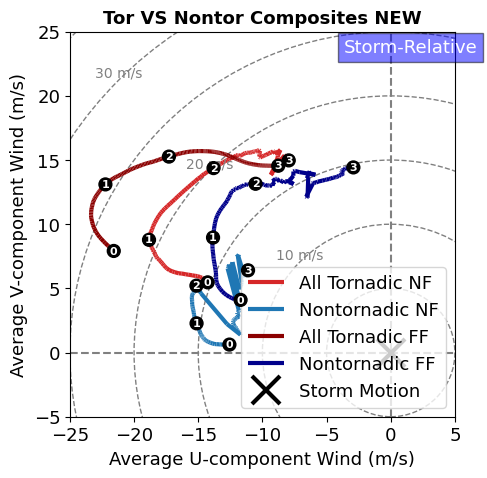

In [195]:
hodo_plot([new_2ndtrip['tor_u_nf'], new_2ndtrip['nontor_u_nf'], new_2ndtrip['tor_u_ff'], new_2ndtrip['nontor_u_ff']], 
          [new_2ndtrip['tor_v_nf'], new_2ndtrip['nontor_v_nf'], new_2ndtrip['tor_v_ff'], new_2ndtrip['nontor_v_ff']], heights, 25, 
    'Tor VS Nontor Composites NEW', ['tab:red', 'tab:blue', 'darkred', 'darkblue'], 
    ['All Tornadic NF', 'Nontornadic NF', 'All Tornadic FF', 'Nontornadic FF'], 5, 25, 'lower right', 5,5)

In [272]:
tor_winds_new_trans = tor_winds_new.T
nontor_winds_new_trans = nontor_winds_new.T

In [296]:
784/196

4.0

In [306]:
tor_winds_new

,Date,NF_u_mean,NF_v_mean,FF_u_mean,FF_v_mean
0,20220523,-12.344266,8.704443,-20.542034,7.905432
1,20220523,-12.622243,8.931932,-20.661453,8.019386
2,20220523,-12.917190,9.078350,-20.770967,8.118554
3,20220523,-13.206150,9.160345,-20.880770,8.207498
4,20220523,-13.793958,9.317830,-21.105918,8.399336
...,...,...,...,...,...
191,20230615,-6.466870,15.652995,-10.781869,12.555992
192,20230615,-6.404276,15.664442,-10.708591,12.555545
193,20230615,-6.355554,15.673253,-10.649879,12.562620
194,20230615,-6.290848,15.683176,-10.568156,12.569808


In [326]:
tor_nf_u = tor_winds_new['NF_u_mean']
tor_nf_v = tor_winds_new['NF_v_mean']
tor_ff_u = tor_winds_new['FF_u_mean']
tor_ff_v = tor_winds_new['FF_v_mean']

avg_tor_nf_u = np.nansum([tor_nf_u.iloc[:196], tor_nf_u.iloc[196:392], tor_nf_u.iloc[392:588], tor_nf_u.iloc[588:]], axis=0) / 4
avg_tor_nf_v = np.nansum([tor_nf_v.iloc[:196], tor_nf_v.iloc[196:392], tor_nf_v.iloc[392:588], tor_nf_v.iloc[588:]], axis=0) / 4

avg_tor_ff_u = np.nansum([tor_ff_u.iloc[:196], tor_ff_u.iloc[196:392], tor_ff_u.iloc[392:588], tor_ff_u.iloc[588:]], axis=0) / 4
avg_tor_ff_v = np.nansum([tor_ff_v.iloc[:196], tor_ff_v.iloc[196:392], tor_ff_v.iloc[392:588], tor_ff_v.iloc[588:]], axis=0) / 4

In [328]:
nontor_nf_u = nontor_winds_new['NF_u_mean']
nontor_nf_v = nontor_winds_new['NF_v_mean']
nontor_ff_u = nontor_winds_new['FF_u_mean']
nontor_ff_v = nontor_winds_new['FF_v_mean']

avg_nontor_nf_u = np.nansum([nontor_nf_u.iloc[:196], nontor_nf_u.iloc[196:392]], axis=0)/ 2
avg_nontor_nf_v = np.nansum([nontor_nf_v.iloc[:196],nontor_nf_v.iloc[196:392]], axis=0) / 2

avg_nontor_ff_u = np.nansum([nontor_ff_u.iloc[:196],nontor_ff_u.iloc[196:392]], axis=0) / 2
avg_nontor_ff_v = np.nansum([nontor_ff_v.iloc[:196],nontor_ff_v.iloc[196:392]], axis=0) / 2

In [329]:
np.shape(avg_tor_nf_u)

(196,)

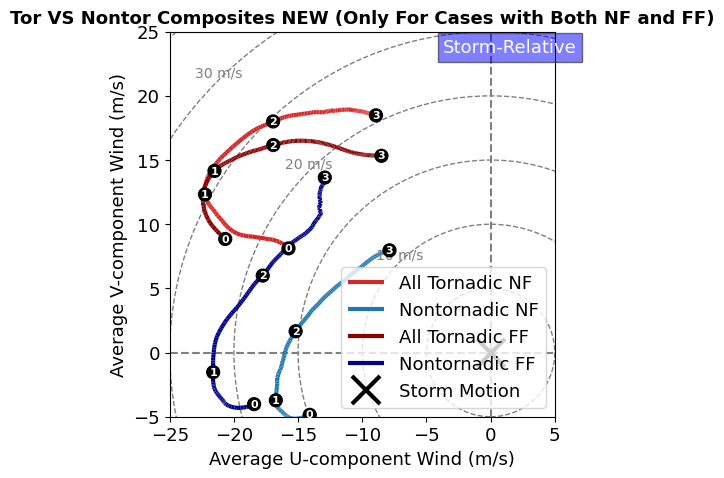

In [331]:
hodo_plot([avg_tor_nf_u, avg_nontor_nf_u, avg_tor_ff_u, avg_nontor_ff_u], 
          [avg_tor_nf_v, avg_nontor_nf_v, avg_tor_ff_v, avg_nontor_ff_v], heights, 25, 
    'Tor VS Nontor Composites NEW (Only For Cases with Both NF and FF)', ['tab:red', 'tab:blue', 'darkred', 'darkblue'], 
    ['All Tornadic NF', 'Nontornadic NF', 'All Tornadic FF', 'Nontornadic FF'], 5, 25, 'lower right', 5,5)

# SRW and SRH

SRW

Does this even mean anything? The average u and v component from 0-2km?

In [ ]:
def avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, h0, htop):
    '''
    h0: height you want to get the u and v of
    htop: an area around that point to take the average of to make sure the selected point isnt messed up
    '''
        
    tor_u_nf_per = np.nanmean(nf_u_categories['tor'].iloc[:, h0:htop], axis=1)
    tor_v_nf_per = np.nanmean(nf_v_categories['tor'].iloc[:, h0:htop], axis=1)
    
    pretor_u_nf_per = np.nanmean(nf_u_categories['pretor'].iloc[:, h0:htop], axis=1)
    pretor_v_nf_per = np.nanmean(nf_v_categories['pretor'].iloc[:, h0:htop], axis=1)
    
    dtor_u_nf_per = np.nanmean(nf_u_categories['dtor'].iloc[:, h0:htop], axis=1)
    dtor_v_nf_per = np.nanmean(nf_v_categories['dtor'].iloc[:, h0:htop], axis=1)
    
    posttor_u_nf_per = np.nanmean(nf_u_categories['posttor'].iloc[:, h0:htop], axis=1)
    posttor_v_nf_per = np.nanmean(nf_v_categories['posttor'].iloc[:, h0:htop], axis=1)
    
    nontor_u_nf_per = np.nanmean(nf_u_categories['nontor'].iloc[:, h0:htop], axis=1)
    nontor_v_nf_per = np.nanmean(nf_v_categories['nontor'].iloc[:, h0:htop], axis=1)

    tor_u_ff_per = np.nanmean(ff_u_categories['tor'].iloc[:, h0:htop], axis=1)
    tor_v_ff_per = np.nanmean(ff_v_categories['tor'].iloc[:, h0:htop], axis=1)

    pretor_u_ff_per = np.nanmean(ff_u_categories['pretor'].iloc[:, h0:htop], axis=1)
    pretor_v_ff_per = np.nanmean(ff_v_categories['pretor'].iloc[:, h0:htop], axis=1)
    
    dtor_u_ff_per = np.nanmean(ff_u_categories['dtor'].iloc[:, h0:htop], axis=1)
    dtor_v_ff_per = np.nanmean(ff_v_categories['dtor'].iloc[:, h0:htop], axis=1)
    
    posttor_u_ff_per = np.nanmean(ff_u_categories['posttor'].iloc[:, h0:htop], axis=1)
    posttor_v_ff_per = np.nanmean(ff_v_categories['posttor'].iloc[:, h0:htop], axis=1)
    
    nontor_u_ff_per = np.nanmean(ff_u_categories['nontor'].iloc[:, h0:htop], axis=1)
    nontor_v_ff_per = np.nanmean(ff_v_categories['nontor'].iloc[:, h0:htop], axis=1)

    return locals()

In [ ]:
avg_sfc_wind = avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 0, 5)
avg_500m_wind = avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 50, 55)
avg_1km_wind = avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 100, 105)
avg_2km_wind = avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 191, 196)

In [ ]:
avg_sfc_wind_new = avg_u_and_v_per_vad(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 0, 5)
avg_500m_wind_new = avg_u_and_v_per_vad(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 50, 55)
avg_1km_wind_new = avg_u_and_v_per_vad(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 100, 105)
avg_2km_wind_new = avg_u_and_v_per_vad(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 191, 196)

In [ ]:
np.shape(avg_sfc_wind['pretor_u_nf_per'])

In [ ]:
def tor_boxplot_uandv(data_dict, title_height):
    
    labels = ['NonTor', 'TorAll','PreTor', 'DuringTor', 'PostTor']
    height = data_dict
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    
    ax0.boxplot([height['nontor_u_nf_per'], height['tor_u_nf_per'], height['pretor_u_nf_per'], height['dtor_u_nf_per'], 
                 height['posttor_u_nf_per']], labels = labels)
    
    #ax0.set_xticks(ticks = labels)
    #ax0.set_yticks(fontsize=13)
    ax0.set_ylabel('Wind Velocity (m/s)', fontweight='bold', fontsize=10)
    ax0.grid()
    ax0.set_title(f'{title_height} Storm-Relative Wind u Component Per Near-Field VAD', fontweight='bold', fontsize=10, wrap= True)
    
    ax1.boxplot([height['nontor_v_nf_per'], height['tor_v_nf_per'], height['pretor_v_nf_per'], height['dtor_v_nf_per'], 
                 height['posttor_v_nf_per']], labels = labels)
    
    ax1.set_ylabel('Wind Velocity (m/s)', fontweight='bold', fontsize=10)
    ax1.grid()
    ax1.set_title(f'{title_height} Storm-Relative Wind v Component Per Near-Field VAD', fontweight='bold', fontsize=10, wrap=True)
    
    fig.tight_layout()
    plt.show()

In [ ]:
tor_boxplot_uandv(avg_sfc_wind, '50m')

In [ ]:
tor_boxplot_uandv(avg_sfc_wind_new, '50m NEW')

In [ ]:
tor_boxplot_uandv(avg_500m_wind, '500m')

In [ ]:
tor_boxplot_uandv(avg_500m_wind_new, '500m NEW')

In [ ]:
tor_boxplot_uandv(avg_1km_wind, '1km')

In [ ]:
tor_boxplot_uandv(avg_1km_wind_new, '1km NEW')

In [ ]:
tor_boxplot_uandv(avg_2km_wind, '2km')

In [ ]:
tor_boxplot_uandv(avg_2km_wind_new, '2km NEW')

0-xkm Shear Vector Magnitudes

In [ ]:
def avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, h0, htop):
    '''
    h0: height you want to get the u and v of
    htop: an area around that point to take the average of to make sure the selected point isnt messed up
    '''
    pretor_u_nf_per = np.nanmean(nf_u_categories['pretor'].iloc[:, h0:htop], axis=1)
    pretor_v_nf_per = np.nanmean(nf_v_categories['pretor'].iloc[:, h0:htop], axis=1)
    
    dtor_u_nf_per = np.nanmean(nf_u_categories['dtor'].iloc[:, h0:htop], axis=1)
    dtor_v_nf_per = np.nanmean(nf_v_categories['dtor'].iloc[:, h0:htop], axis=1)
    
    posttor_u_nf_per = np.nanmean(nf_u_categories['posttor'].iloc[:, h0:htop], axis=1)
    posttor_v_nf_per = np.nanmean(nf_v_categories['posttor'].iloc[:, h0:htop], axis=1)
    
    nontor_u_nf_per = np.nanmean(nf_u_categories['nontor'].iloc[:, h0:htop], axis=1)
    nontor_v_nf_per = np.nanmean(nf_v_categories['nontor'].iloc[:, h0:htop], axis=1)

    pretor_u_ff_per = np.nanmean(ff_u_categories['pretor'].iloc[:, h0:htop], axis=1)
    pretor_v_ff_per = np.nanmean(ff_v_categories['pretor'].iloc[:, h0:htop], axis=1)
    
    dtor_u_ff_per = np.nanmean(ff_u_categories['dtor'].iloc[:, h0:htop], axis=1)
    dtor_v_ff_per = np.nanmean(ff_v_categories['dtor'].iloc[:, h0:htop], axis=1)
    
    posttor_u_ff_per = np.nanmean(ff_u_categories['posttor'].iloc[:, h0:htop], axis=1)
    posttor_v_ff_per = np.nanmean(ff_v_categories['posttor'].iloc[:, h0:htop], axis=1)
    
    nontor_u_ff_per = np.nanmean(ff_u_categories['nontor'].iloc[:, h0:htop], axis=1)
    nontor_v_ff_per = np.nanmean(ff_v_categories['nontor'].iloc[:, h0:htop], axis=1)

    return locals()

In [ ]:
def shear_magnitude(u, v, vector_height):
    delta_u = u.iloc[:, vector_height] - u.iloc[:, 0]
    delta_v = v.iloc[:, vector_height] - v.iloc[:, 0]
    mag = np.sqrt(np.nansum([(delta_u**2), (delta_v**2)], axis=0))

    return mag

In [ ]:
def shear_mag_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, vector_height):

    nf_tor = shear_magnitude(nf_u_categories['tor'], nf_v_categories['tor'], vector_height)
    ff_tor = shear_magnitude(ff_u_categories['tor'], ff_v_categories['tor'], vector_height)

    nf_pretor = shear_magnitude(nf_u_categories['pretor'], nf_v_categories['pretor'], vector_height)
    ff_pretor = shear_magnitude(ff_u_categories['pretor'], ff_v_categories['pretor'], vector_height)

    nf_dtor = shear_magnitude(nf_u_categories['dtor'], nf_v_categories['dtor'], vector_height)
    ff_dtor = shear_magnitude(ff_u_categories['dtor'], ff_v_categories['dtor'], vector_height)

    nf_posttor = shear_magnitude(nf_u_categories['posttor'], nf_v_categories['posttor'], vector_height)
    ff_posttor = shear_magnitude(ff_u_categories['posttor'], ff_v_categories['posttor'], vector_height)

    nf_nontor = shear_magnitude(nf_u_categories['nontor'], nf_v_categories['nontor'], vector_height)
    ff_nontor = shear_magnitude(ff_u_categories['nontor'], ff_v_categories['nontor'], vector_height)

    return locals()

In [70]:
def comp_srw(u,v, height):
    '''
    Computes storm-relative wind/inflow at every height
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srw = []
    for i in np.arange(0, 195):
        srw0 = np.sqrt(np.nansum([(u.iloc[:, i]**2), (v.iloc[:,i]**2)], axis=0)) # srw at each height
        srw.append(srw0)

    srw_array = np.array(srw)
    srw_at_target_height = srw_array[height]
        
    return srw_at_target_height

In [ ]:
def comp_srh(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in np.arange(0, 194):
        
        a = np.nanprod([u.iloc[:, i+1], v.iloc[:, i]], axis=0)
        b = -np.nanprod([u.iloc[:, i], v.iloc[:, i+1]],axis=0)
        
        srh0 = np.nansum([a, b], axis=0)
        srh.append(srh0)
        
    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh

In [ ]:
def srh_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories):

    # angle0to30_nf = nf_u_categories_new['Angle'] < 31
    # angle0to30_ff = ff_u_categories_new['Angle'] < 31
    # angle30to60_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
    # angle30to60_ff = [ff_u_categories_new['Angle'] > 31][ff_u_categories_new['Angle'] < 61]
    # angle600to90_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
    # angle60to90_ff = [ff_u_categories_new['Angle'] > 61][ff_u_categories_new['Angle'] < 91]
    
    #nf_pretor = comp_srh(nf_u_categories['pretor'][angle0to30_nf], nf_v_categories['pretor'][angle0to30_nf])

    nf_tor = comp_srh(nf_u_categories['tor'], nf_v_categories['tor'])
    ff_tor = comp_srh(ff_u_categories['tor'], ff_v_categories['tor'])

    nf_pretor = comp_srh(nf_u_categories['pretor'], nf_v_categories['pretor'])
    ff_pretor = comp_srh(ff_u_categories['pretor'], ff_v_categories['pretor'])

    nf_dtor = comp_srh(nf_u_categories['dtor'], nf_v_categories['dtor'])
    ff_dtor = comp_srh(ff_u_categories['dtor'], ff_v_categories['dtor'])

    nf_posttor = comp_srh(nf_u_categories['posttor'], nf_v_categories['posttor'])
    ff_posttor = comp_srh(ff_u_categories['posttor'], ff_v_categories['posttor'])

    nf_nontor = comp_srh(nf_u_categories['nontor'], nf_v_categories['nontor'])
    ff_nontor = comp_srh(ff_u_categories['nontor'], ff_v_categories['nontor'])

    return locals()

In [ ]:
def srw_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories):

    # angle0to30_nf = nf_u_categories_new['Angle'] < 31
    # angle0to30_ff = ff_u_categories_new['Angle'] < 31
    # angle30to60_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
    # angle30to60_ff = [ff_u_categories_new['Angle'] > 31][ff_u_categories_new['Angle'] < 61]
    # angle600to90_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
    # angle60to90_ff = [ff_u_categories_new['Angle'] > 61][ff_u_categories_new['Angle'] < 91]
    
    #nf_pretor = comp_srh(nf_u_categories['pretor'][angle0to30_nf], nf_v_categories['pretor'][angle0to30_nf])

    nf_tor = comp_srw(nf_u_categories['tor'], nf_v_categories['tor'])
    ff_tor = comp_srw(ff_u_categories['tor'], ff_v_categories['tor'])

    nf_pretor = comp_srw(nf_u_categories['pretor'], nf_v_categories['pretor'])
    ff_pretor = comp_srw(ff_u_categories['pretor'], ff_v_categories['pretor'])

    nf_dtor = comp_srw(nf_u_categories['dtor'], nf_v_categories['dtor'])
    ff_dtor = comp_srw(ff_u_categories['dtor'], ff_v_categories['dtor'])

    nf_posttor = comp_srw(nf_u_categories['posttor'], nf_v_categories['posttor'])
    ff_posttor = comp_srw(ff_u_categories['posttor'], ff_v_categories['posttor'])

    nf_nontor = comp_srw(nf_u_categories['nontor'], nf_v_categories['nontor'])
    ff_nontor = comp_srw(ff_u_categories['nontor'], ff_v_categories['nontor'])

    return locals()

In [ ]:
angle0to30_nf = np.array(nf_u_categories_new['Angle']) < 31
a = nf_u_categories['pretor'][angle0to30_nf]

In [ ]:
srh_all = srh_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories)

In [ ]:
srh_all_new = srh_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new)

In [ ]:
def srh_per_level(srh_all):

    nf_tor_sfcto500 = np.nansum(srh_all['nf_tor'][:50], axis=0)
    nf_tor_sfcto1km = np.nansum(srh_all['nf_tor'][:100], axis=0)
    nf_tor_sfcto1halfkm = np.nansum(srh_all['nf_tor'][:150], axis=0)
    nf_tor_sfcto2km = np.nansum(srh_all['nf_tor'][:196], axis=0)

    ff_tor_sfcto500 = np.nansum(srh_all['ff_tor'][:50], axis=0)
    ff_tor_sfcto1km = np.nansum(srh_all['ff_tor'][:100], axis=0)
    ff_tor_sfcto1halfkm = np.nansum(srh_all['ff_tor'][:150], axis=0)
    ff_tor_sfcto2km = np.nansum(srh_all['ff_tor'][:196], axis=0)
    
    nf_pretor_sfcto500 = np.nansum(srh_all['nf_pretor'][:50], axis=0)
    nf_pretor_sfcto1km = np.nansum(srh_all['nf_pretor'][:100], axis=0)
    nf_pretor_sfcto1halfkm = np.nansum(srh_all['nf_pretor'][:150], axis=0)
    nf_pretor_sfcto2km = np.nansum(srh_all['nf_pretor'][:196], axis=0)

    ff_pretor_sfcto500 = np.nansum(srh_all['ff_pretor'][:50], axis=0)
    ff_pretor_sfcto1km = np.nansum(srh_all['ff_pretor'][:100], axis=0)
    ff_pretor_sfcto1halfkm = np.nansum(srh_all['ff_pretor'][:150], axis=0)
    ff_pretor_sfcto2km = np.nansum(srh_all['ff_pretor'][:196], axis=0)

    nf_dtor_sfcto500 = np.nansum(srh_all['nf_dtor'][:50], axis=0)
    nf_dtor_sfcto1km = np.nansum(srh_all['nf_dtor'][:100], axis=0)
    nf_dtor_sfcto1halfkm = np.nansum(srh_all['nf_dtor'][:150], axis=0)
    nf_dtor_sfcto2km = np.nansum(srh_all['nf_dtor'][:196], axis=0)

    ff_dtor_sfcto500 = np.nansum(srh_all['ff_dtor'][:50], axis=0)
    ff_dtor_sfcto1km = np.nansum(srh_all['ff_dtor'][:100], axis=0)
    ff_dtor_sfcto1halfkm = np.nansum(srh_all['ff_dtor'][:150], axis=0)
    ff_dtor_sfcto2km = np.nansum(srh_all['ff_dtor'][:196], axis=0)

    nf_posttor_sfcto500 = np.nansum(srh_all['nf_posttor'][:50], axis=0)
    nf_posttor_sfcto1km = np.nansum(srh_all['nf_posttor'][:100], axis=0)
    nf_posttor_sfcto1halfkm = np.nansum(srh_all['nf_posttor'][:150], axis=0)
    nf_posttor_sfcto2km = np.nansum(srh_all['nf_posttor'][:196], axis=0)

    ff_posttor_sfcto500 = np.nansum(srh_all['ff_posttor'][:50], axis=0)
    ff_posttor_sfcto1km = np.nansum(srh_all['ff_posttor'][:100], axis=0)
    ff_posttor_sfcto1halfkm = np.nansum(srh_all['ff_posttor'][:150], axis=0)
    ff_posttor_sfcto2km = np.nansum(srh_all['ff_posttor'][:196], axis=0)

    nf_nontor_sfcto500 = np.nansum(srh_all['nf_nontor'][:50], axis=0)
    nf_nontor_sfcto1km = np.nansum(srh_all['nf_nontor'][:100], axis=0)
    nf_nontor_sfcto1halfkm = np.nansum(srh_all['nf_nontor'][:150], axis=0)
    nf_nontor_sfcto2km = np.nansum(srh_all['nf_nontor'][:196], axis=0)

    ff_nontor_sfcto500 = np.nansum(srh_all['ff_nontor'][:50], axis=0)
    ff_nontor_sfcto1km = np.nansum(srh_all['ff_nontor'][:100], axis=0)
    ff_nontor_sfcto1halfkm = np.nansum(srh_all['ff_nontor'][:150], axis=0)
    ff_nontor_sfcto2km = np.nansum(srh_all['ff_nontor'][:196], axis=0)

    return locals()

In [ ]:
srh_sum_all = srh_per_level(srh_all)

In [ ]:
srh_sum_all_new = srh_per_level(srh_all_new)

In [ ]:
mag_all_500m = shear_mag_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 51)
mag_all_1km = shear_mag_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 101)
mag_all_2km = shear_mag_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 195)

In [ ]:
mag_all_500m_new = shear_mag_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 51)
mag_all_1km_new = shear_mag_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 101)
mag_all_2km_new = shear_mag_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 195)

In [ ]:
srw_all_new = srw_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new)

In [ ]:
angle0to30_nf = nf_u_categories_new['Angle'] < 31
angle0to30_ff = ff_u_categories_new['Angle'] < 31
angle30to60_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
angle30to60_ff = [ff_u_categories_new['Angle'] > 31][ff_u_categories_new['Angle'] < 61]
angle600to90_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
angle60to90_ff = [ff_u_categories_new['Angle'] > 61][ff_u_categories_new['Angle'] < 91]

mag_all_500m_new_0to30 = shear_mag_all_cats(nf_u_categories_new[angle0to30_nf] , 
                                            nf_v_categories_new[angle0to30_nf], 
                                            ff_u_categories_new[angle0to30_ff], 
                                            ff_v_categories_new[angle0to30_ff], 51)

mag_all_500m_new_30to60 = shear_mag_all_cats(nf_u_categories_new[angle30to60_nf], nf_v_categories_new[angle30to60_nf], 
                                            ff_u_categories_new[angle30to60_ff], ff_v_categories_new[angle30to60_ff], 51)

mag_all_2km_new_60to90 = shear_mag_all_cats(nf_u_categories_new[angle600to90_nf], nf_v_categories_new[angle600to90_nf], 
                                            ff_u_categories_new[angle600to90_ff], ff_v_categories_new[angle600to90_ff], 51)

In [ ]:
def tor_boxplot_srh(data_dict, title_height, srh_height):
    
    labels = ['NonTor', 'TorAll','PreTor', 'DuringTor', 'PostTor']
    height = data_dict
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    
    ax0.boxplot([height[f'nf_nontor_sfcto{srh_height}'], height[f'nf_tor_sfcto{srh_height}'], height[f'nf_pretor_sfcto{srh_height}'], 
                 height[f'nf_dtor_sfcto{srh_height}'], height[f'nf_posttor_sfcto{srh_height}']], labels = labels)
    
    #ax0.set_xticks(ticks = labels)
    #ax0.set_yticks(fontsize=13)
    ax0.set_ylabel('SRH (m$^{2}$s$^{-2})$', fontweight='bold', fontsize=10)
    ax0.grid()
    ax0.set_title(f'0-{title_height} Storm-Relative Helicity Per Near-Field VAD', fontweight='bold', fontsize=10, wrap= True)
    
    ax1.boxplot([height[f'ff_nontor_sfcto{srh_height}'], height[f'ff_tor_sfcto{srh_height}'], height[f'ff_pretor_sfcto{srh_height}'], 
                 height[f'ff_dtor_sfcto{srh_height}'], height[f'ff_posttor_sfcto{srh_height}']], labels = labels)
    
    ax1.set_ylabel('SRH (m$^{2}$s$^{-2})$', fontweight='bold', fontsize=10)
    ax1.grid()
    ax1.set_title(f'0-{title_height} Storm-Relative Helicity Per Far-Field VAD', fontweight='bold', fontsize=10, wrap=True)
    
    fig.tight_layout()
    plt.show()

In [ ]:
tor_boxplot_srh(srh_sum_all, '500m', 500)

In [ ]:
tor_boxplot_srh(srh_sum_all_new, '500m NEW', 500)

In [ ]:
tor_boxplot_srh(srh_sum_all, '1km', '1km')

In [ ]:
tor_boxplot_srh(srh_sum_all_new, '1km NEW', '1km')

In [ ]:
tor_boxplot_srh(srh_sum_all, '2km', '2km')

In [ ]:
tor_boxplot_srh(srh_sum_all_new, '2km NEW', '2km')

In [57]:
def composite_srh_nan(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in range(len(u)-1):
        a = np.nanprod([u[i+1], v[i]], axis=0)
        b = -np.nanprod([u[i], v[i+1]], axis=0)
        
        srh0 = np.nansum([a, b], axis=0)
        srh.append(srh0)
        
    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh_total

In [72]:
srw_all = []
srw_sfc = []

for d in set(df_all_new['Date']):

    
    df_u = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'u')]
    df_v = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'v')]
    
    srw_values_sfc = comp_srw(df_u, df_v, 0)
    
    df_all_new.loc[df_u.index, 'SRW Mag'] = srw_values_sfc  # Assign to correct indices
    df_all_new.loc[df_v.index, 'SRW Mag'] = srw_values_sfc


In [58]:
srh_all = []
srh_0to2km = []

for d in set(df_all_new['Date']):

    
    df_u = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'u')]
    df_v = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'v')]

    print(range(len(df_u)))
    
    srh_values = [
        composite_srh_nan(df_u.iloc[i, :196], df_v.iloc[i, :196]) 
        for i in range(len(df_u))
    ]
    
    df_all_new.loc[df_u.index, '0-2km SRH'] = srh_values  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-2km SRH'] = srh_values


range(0, 10)
range(0, 157)


/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/1549296991.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a = np.nanprod([u[i+1], v[i]], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/1549296991.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b = -np.nanprod([u[i], v[i+1]], axis=0)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/1549296991.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by posi

range(0, 142)
range(0, 70)
range(0, 50)
range(0, 390)
range(0, 253)
range(0, 425)
range(0, 194)
range(0, 131)
range(0, 462)
range(0, 392)
range(0, 525)
range(0, 99)


In [ ]:
df_all_new['Date'].value_counts()

In [340]:
df_all_new

,0,1,2,3,4,5,6,7,8,9,...,194,195,u or v,Distance,Angle,Time From Tor (min),Datetime,Date,0-2km SRH,SRW Mag
0,-16.835770,-16.755274,-16.687143,-16.646894,-16.591278,-16.606508,-16.596056,-16.624393,-16.698717,-16.813435,...,-9.976872,-9.931767,u,24.796636,282.132826,-54.833333,2022-05-23 22:55:10,20220523,119.748598,18.084001
1,-14.939102,-15.009944,-15.074447,-15.129332,-15.258727,-15.290950,-15.374236,-15.448551,-15.529462,-15.613126,...,-8.965948,-8.903369,u,25.813325,282.602215,-54.333333,2022-05-23 22:55:40,20220523,98.612390,16.929266
2,-14.908146,-15.014770,-15.122228,-15.226007,-15.440908,-15.526935,-15.692964,-15.829327,-15.938499,-16.014187,...,-8.836675,-8.764936,u,26.810463,283.027394,-53.833333,2022-05-23 22:56:10,20220523,100.986069,16.606345
3,-14.967583,-15.150704,-15.295214,-15.410604,-15.666528,-15.871101,-15.918962,-16.046745,-16.148834,-16.246586,...,-8.155903,-8.073130,u,27.817252,283.424013,-53.35,2022-05-23 22:56:39,20220523,90.521531,17.077444
4,-15.580977,-15.710516,-15.809145,-15.890134,-16.091858,-16.142567,-16.262787,-16.348358,-16.409420,-16.458860,...,-7.272206,-7.229976,u,28.820999,283.791452,-52.85,2022-05-23 22:57:09,20220523,104.417661,18.654303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6595,-1.635275,-1.568471,-1.420855,-1.320286,-1.320286,-1.102728,-1.051306,-0.936231,-0.836507,-0.828301,...,3.858832,3.863916,v,17.730159,10.589711,63.566667,2023-06-16 00:34:34,20230615,244.074307,23.652900
6596,-3.691865,-3.578943,-3.513133,-3.421503,-3.421503,-3.236247,-3.157359,-3.030900,-2.966462,-2.847811,...,2.436770,2.438994,v,17.730159,5.589711,63.783333,2023-06-16 00:34:47,20230615,226.896842,23.917808
6597,-3.230326,-3.062784,-2.947798,-2.882831,-2.882831,-2.730972,-2.657030,-2.451415,-2.396161,-2.222835,...,2.570550,2.575942,v,17.730159,5.589711,64.0,2023-06-16 00:35:00,20230615,206.528619,26.158343
6598,-4.028626,-3.970635,-3.912552,-3.842394,-3.842394,-3.703241,-3.636965,-3.529508,-3.464480,-3.379116,...,2.459235,2.459529,v,17.730194,5.590613,66.033333,2023-06-16 00:37:02,20230615,218.595898,26.418142


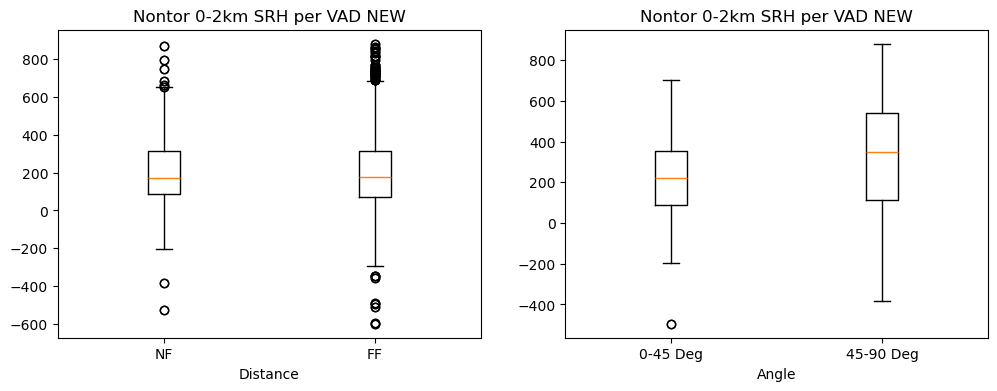

In [343]:
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
ax0.boxplot([df_all_new[(df_all_new['Time From Tor (min)'] == 'nontor') & (df_all_new['Distance'] < 21)]['0-2km SRH'],
           df_all_new[(df_all_new['Time From Tor (min)'] == 'nontor') & (df_all_new['Distance'] >= 21)]['0-2km SRH']], labels=['NF', 'FF'])
ax0.set_xlabel('Distance')
ax0.set_title(f'Nontor 0-2km SRH per VAD NEW')

ax1.boxplot([df_all_new[(df_all_new['Time From Tor (min)'] == 'nontor') & (df_all_new['Angle'] < 45)]['0-2km SRH'],
           df_all_new[(df_all_new['Time From Tor (min)'] == 'nontor') & (df_all_new['Angle'] >= 45) & (df_all_new['Angle'] <= 90)]['0-2km SRH']], labels=['0-45 Deg', '45-90 Deg'])
ax1.set_xlabel('Angle')
ax1.set_title(f'Nontor 0-2km SRH per VAD NEW')

plt.show()

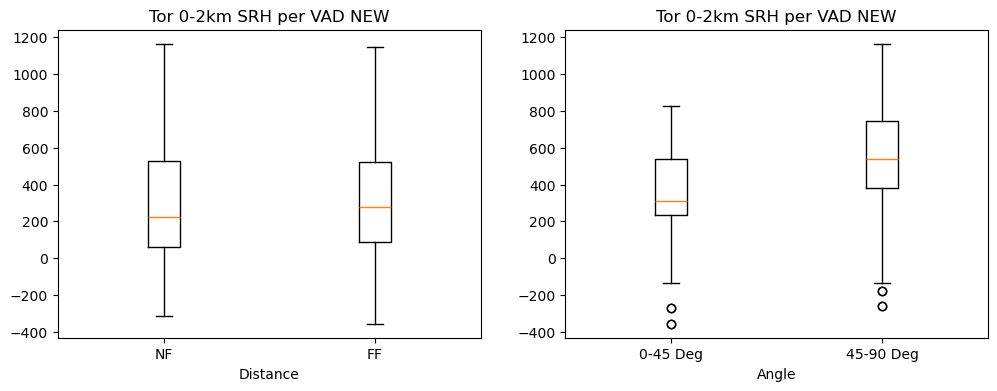

In [344]:
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
ax0.boxplot([df_all_new[(df_all_new['Time From Tor (min)'] != 'nontor') & (df_all_new['Distance'] < 21)]['0-2km SRH'],
           df_all_new[(df_all_new['Time From Tor (min)'] != 'nontor') & (df_all_new['Distance'] >= 21)]['0-2km SRH']], labels=['NF', 'FF'])
ax0.set_xlabel('Distance')
ax0.set_title(f'Tor 0-2km SRH per VAD NEW')

ax1.boxplot([df_all_new[(df_all_new['Time From Tor (min)'] != 'nontor') & (df_all_new['Angle'] < 45)]['0-2km SRH'],
           df_all_new[(df_all_new['Time From Tor (min)'] != 'nontor') & (df_all_new['Angle'] >= 45) & (df_all_new['Angle'] <= 90)]['0-2km SRH']], labels=['0-45 Deg', '45-90 Deg'])
ax1.set_xlabel('Angle')
ax1.set_title(f'Tor 0-2km SRH per VAD NEW')

plt.show()

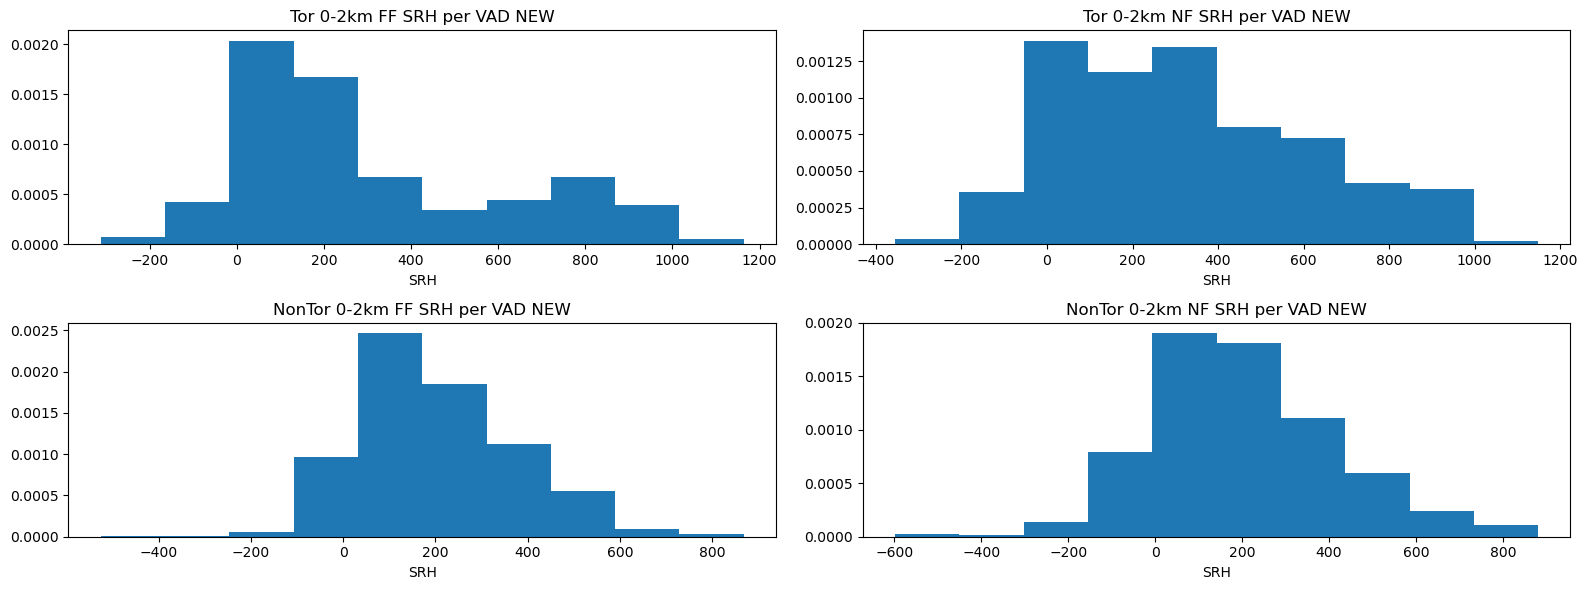

In [356]:
fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(nrows=2, ncols=2, figsize=(16,6))
counts0, bins0 = np.histogram([df_all_new[(df_all_new['Time From Tor (min)'] != 'nontor') & (df_all_new['Distance'] < 21)]['0-2km SRH']])
           
counts1, bins1 = np.histogram([df_all_new[(df_all_new['Time From Tor (min)'] != 'nontor') & (df_all_new['Distance'] >= 21)]['0-2km SRH']])

counts2, bins2 = np.histogram([df_all_new[(df_all_new['Time From Tor (min)'] == 'nontor') & (df_all_new['Distance'] < 21)]['0-2km SRH']])

counts3, bins3 = np.histogram([df_all_new[(df_all_new['Time From Tor (min)'] == 'nontor') & (df_all_new['Distance'] >= 21)]['0-2km SRH']])

ax0.hist(bins0[:-1], bins0, weights=counts0, density=True)
ax0.set_xlabel('SRH')
ax0.set_title(f'Tor 0-2km FF SRH per VAD NEW')

ax1.hist(bins1[:-1], bins1, weights=counts1, density=True)
ax1.set_xlabel('SRH')
ax1.set_title(f'Tor 0-2km NF SRH per VAD NEW')

ax2.hist(bins2[:-1], bins2, weights=counts2, density=True)
ax2.set_xlabel('SRH')
ax2.set_title(f'NonTor 0-2km FF SRH per VAD NEW')

ax3.hist(bins3[:-1], bins3, weights=counts3, density=True)
ax3.set_xlabel('SRH')
ax3.set_title(f'NonTor 0-2km NF SRH per VAD NEW')
plt.tight_layout()
plt.show()

In [ ]:
fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(nrows=2, ncols=2, figsize=(16,6))
counts0, bins0 = np.histogram([df_all_new[(df_all_new['Time From Tor (min)'] != 'nontor') & (df_all_new['Distance'] < 21)]['0-2km SRH']])
           
counts1, bins1 = np.histogram([df_all_new[(df_all_new['Time From Tor (min)'] != 'nontor') & (df_all_new['Distance'] >= 21)]['0-2km SRH']])

counts2, bins2 = np.histogram([df_all_new[(df_all_new['Time From Tor (min)'] == 'nontor') & (df_all_new['Distance'] < 21)]['0-2km SRH']])

counts3, bins3 = np.histogram([df_all_new[(df_all_new['Time From Tor (min)'] == 'nontor') & (df_all_new['Distance'] >= 21)]['0-2km SRH']])

ax0.hist(bins0[:-1], bins0, weights=counts0, density=True)
ax0.set_xlabel('SRH')
ax0.set_title(f'Tor 0-2km FF SRH per VAD NEW')

ax1.hist(bins1[:-1], bins1, weights=counts1, density=True)
ax1.set_xlabel('SRH')
ax1.set_title(f'Tor 0-2km NF SRH per VAD NEW')

ax2.hist(bins2[:-1], bins2, weights=counts2, density=True)
ax2.set_xlabel('SRH')
ax2.set_title(f'NonTor 0-2km FF SRH per VAD NEW')

ax3.hist(bins3[:-1], bins3, weights=counts3, density=True)
ax3.set_xlabel('SRH')
ax3.set_title(f'NonTor 0-2km NF SRH per VAD NEW')
plt.tight_layout()
plt.show()

# Seaborn Plots (SRH, SRW distributions)

In [358]:
import seaborn as sns

In [ ]:
plt.figure(figsize = (12, 4))
sns.histplot(df_all_new, x = df_all_new['0-2km SRH'])
plt.show()

In [376]:
df['Rounded_Angle']

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
6595    0.0
6596    0.0
6597    0.0
6598    0.0
6599    0.0
Name: Rounded_Angle, Length: 6600, dtype: float64

/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/3937194566.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Rounded_Angle'] = df['Angle'].round(-1)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/3937194566.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Rounded_SRH'] = df['0-2km SRH'].round(-2)


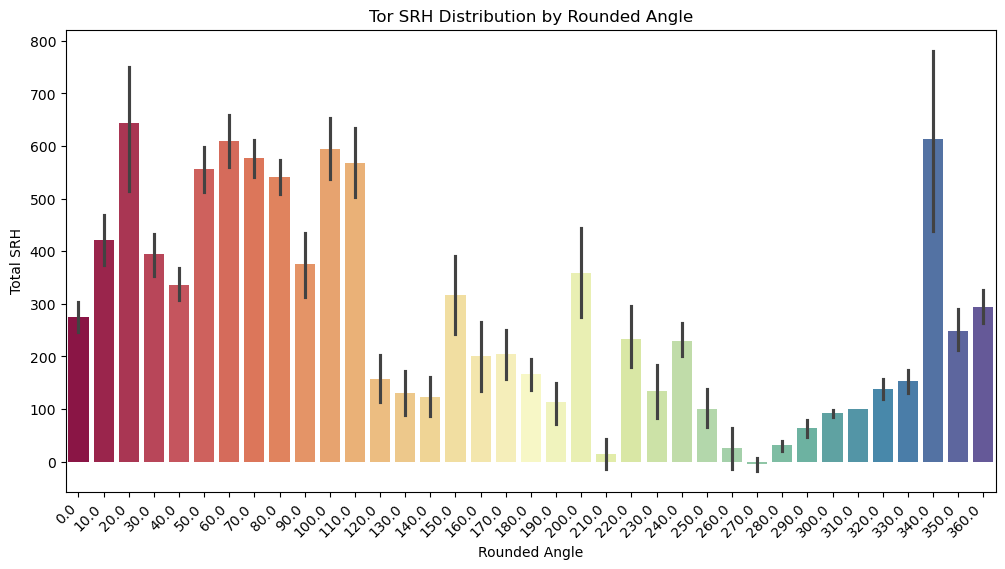

In [419]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
# Group by rounded angles and distances
grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Rounded_Angle', y='Rounded_SRH', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total SRH")
plt.title("Tor SRH Distribution by Rounded Angle")
plt.show()

In [381]:
df_all_new

,0,1,2,3,4,5,6,7,8,9,...,Distance,Angle,Time From Tor (min),Datetime,Date,0-2km SRH,SRW Mag,Rounded_Angle,Rounded_SRH,Rounded_Distance
0,-16.835770,-16.755274,-16.687143,-16.646894,-16.591278,-16.606508,-16.596056,-16.624393,-16.698717,-16.813435,...,24.796636,282.132826,-54.833333,2022-05-23 22:55:10,20220523,119.748598,18.084001,280.0,100.0,20.0
1,-14.939102,-15.009944,-15.074447,-15.129332,-15.258727,-15.290950,-15.374236,-15.448551,-15.529462,-15.613126,...,25.813325,282.602215,-54.333333,2022-05-23 22:55:40,20220523,98.612390,16.929266,280.0,100.0,30.0
2,-14.908146,-15.014770,-15.122228,-15.226007,-15.440908,-15.526935,-15.692964,-15.829327,-15.938499,-16.014187,...,26.810463,283.027394,-53.833333,2022-05-23 22:56:10,20220523,100.986069,16.606345,280.0,100.0,30.0
3,-14.967583,-15.150704,-15.295214,-15.410604,-15.666528,-15.871101,-15.918962,-16.046745,-16.148834,-16.246586,...,27.817252,283.424013,-53.35,2022-05-23 22:56:39,20220523,90.521531,17.077444,280.0,100.0,30.0
4,-15.580977,-15.710516,-15.809145,-15.890134,-16.091858,-16.142567,-16.262787,-16.348358,-16.409420,-16.458860,...,28.820999,283.791452,-52.85,2022-05-23 22:57:09,20220523,104.417661,18.654303,280.0,100.0,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6595,-1.635275,-1.568471,-1.420855,-1.320286,-1.320286,-1.102728,-1.051306,-0.936231,-0.836507,-0.828301,...,17.730159,10.589711,63.566667,2023-06-16 00:34:34,20230615,244.074307,23.652900,10.0,200.0,20.0
6596,-3.691865,-3.578943,-3.513133,-3.421503,-3.421503,-3.236247,-3.157359,-3.030900,-2.966462,-2.847811,...,17.730159,5.589711,63.783333,2023-06-16 00:34:47,20230615,226.896842,23.917808,10.0,200.0,20.0
6597,-3.230326,-3.062784,-2.947798,-2.882831,-2.882831,-2.730972,-2.657030,-2.451415,-2.396161,-2.222835,...,17.730159,5.589711,64.0,2023-06-16 00:35:00,20230615,206.528619,26.158343,10.0,200.0,20.0
6598,-4.028626,-3.970635,-3.912552,-3.842394,-3.842394,-3.703241,-3.636965,-3.529508,-3.464480,-3.379116,...,17.730194,5.590613,66.033333,2023-06-16 00:37:02,20230615,218.595898,26.418142,10.0,200.0,20.0


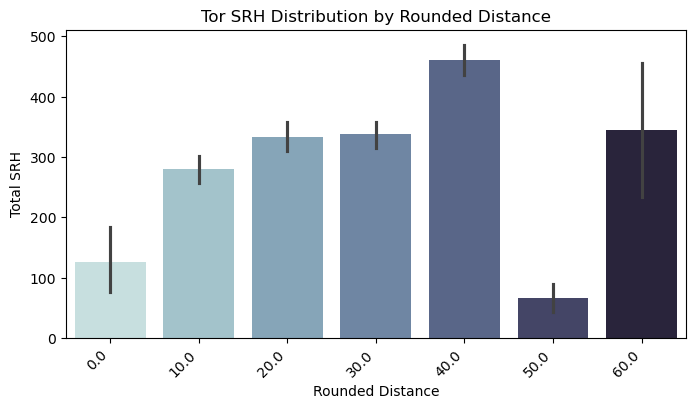

In [458]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
df = df[df['Distance'] <= 100]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_Distance'] = df['Distance'].round(-1)
# Group by rounded angles and distances
grouped = df.groupby(['Rounded_Angle', 'Rounded_Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Rounded_Distance']}km", axis=1)

# Plot
plt.figure(figsize=(8, 4))
sns.barplot(x='Rounded_Distance', y='Rounded_SRH', data=df, palette = "ch:start=.2,rot=-.3")

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Distance")
plt.ylabel("Total SRH")
plt.title("Tor SRH Distribution by Rounded Distance")
plt.show()

/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/1156669995.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Rounded_Angle'] = df['Angle'].round(-1)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/1156669995.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
/var/folders/4f/9s_4__q16tx5t8vmww4mv03h0000gn/T/ipykernel_79897/1156669995.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will b

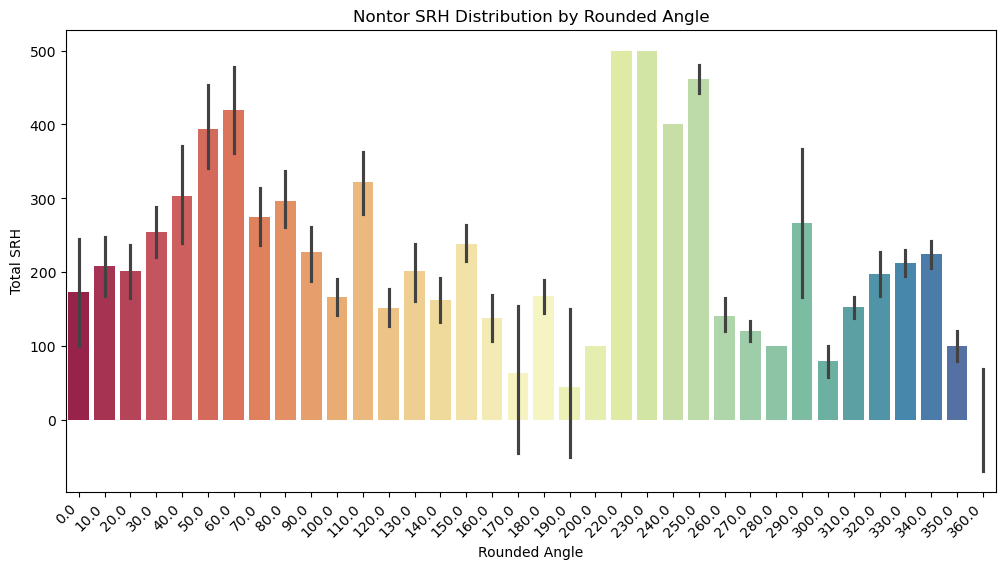

In [425]:
df = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
# Group by rounded angles and distances
grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Rounded_Angle', y='Rounded_SRH', data=df, palette = "Spectral")

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total SRH")
plt.title("Nontor SRH Distribution by Rounded Angle")
plt.show()

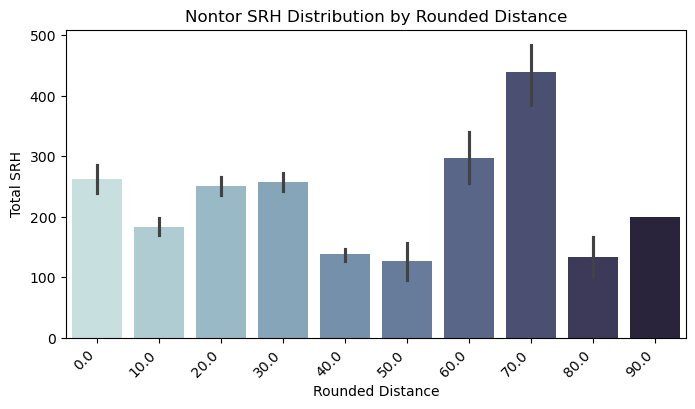

In [455]:
df = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_Distance'] = df['Distance'].round(-1)
# Group by rounded angles and distances
grouped = df.groupby(['Rounded_Angle', 'Rounded_Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Rounded_Distance']}km", axis=1)

# Plot
plt.figure(figsize=(8, 4))
sns.barplot(x='Rounded_Distance', y='Rounded_SRH', data=df, palette = "ch:start=.2,rot=-.3")

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Distance")
plt.ylabel("Total SRH")
plt.title("Nontor SRH Distribution by Rounded Distance")
plt.show()

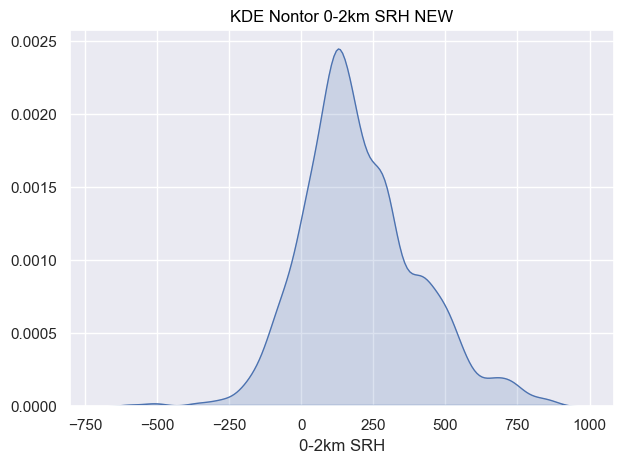

In [494]:
#plt.figure(figsize = (12, 4))
df = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
p = so.Plot(df, x='0-2km SRH').add(sns.objects.Area(), sns.objects.KDE()).label(title = 'KDE Nontor 0-2km SRH NEW')
p.show()

In [543]:
np.nanmean(df['0-2km SRH'], axis=0)

312.599140676654

In [563]:
dftor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
dftor['Tor or Nontor'] = 'tor'

dfnontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
dfnontor['Tor or Nontor'] = 'nontor'

In [565]:
a_new = pd.DataFrame()
ALL_new = pd.concat([a_new, dftor, dfnontor])

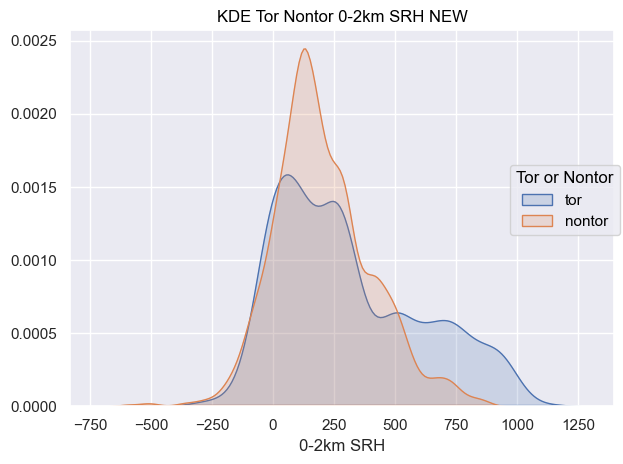

In [572]:
#plt.figure(figsize = (12, 4))
df = ALL_new
p = so.Plot(df, x='0-2km SRH', color='Tor or Nontor').add(sns.objects.Area(), 
                                                          sns.objects.KDE(common_norm=False)).label(title = 'KDE Tor Nontor 0-2km SRH NEW')
p.show()

In [580]:
x = np.nanmean(dftor[dftor['u or v'] == 'v']['195'], axis=0)
print(f'Mean TOR noncomposite v SRW: {x}')

Mean TOR noncomposite v SRW: 13.608573233160612


In [581]:
y = np.nanmean(dfnontor[dfnontor['u or v'] == 'v']['195'], axis=0)
print(f'Mean NONTOR noncomposite v SRW: {y}')

Mean NONTOR noncomposite v SRW: 10.60238636952924


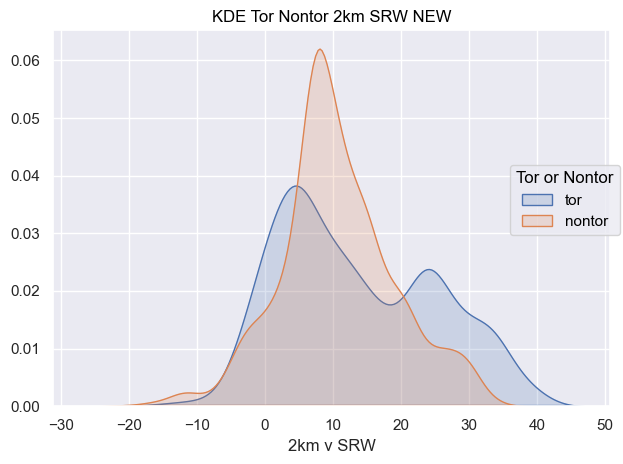

In [587]:
#plt.figure(figsize = (12, 4))
df = ALL_new
df = df[df['u or v'] == 'v']
p = so.Plot(df, x='195', color='Tor or Nontor').add(sns.objects.Area(), 
                                                    sns.objects.KDE(common_norm=False)).label(x = '2km v SRW', 
                                                                                              title = 'KDE Tor Nontor 2km SRW NEW')
p.show()

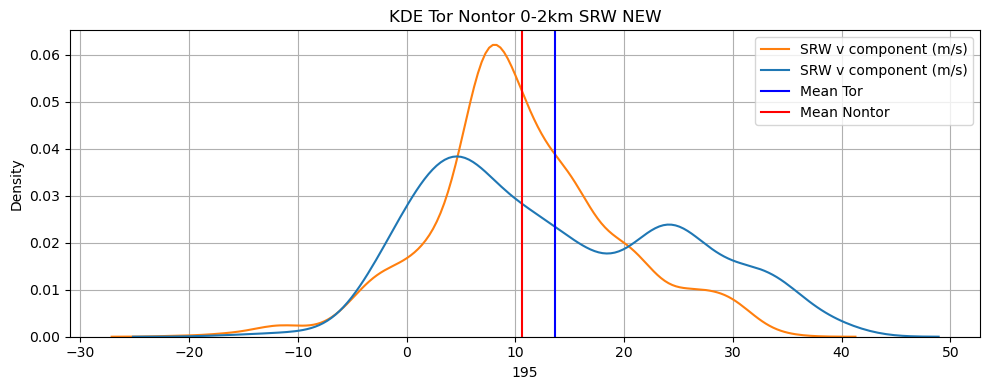

In [611]:
#plt.figure(figsize = (12, 4))
df = ALL_new
df = df[df['u or v'] == 'v']
fig = plt.figure(figsize=(10, 4))
p = sns.kdeplot(df, x='195', hue='Tor or Nontor', common_norm=False, label = 'SRW v component (m/s)')
                
plt.title('KDE Tor Nontor 0-2km SRW NEW')

plt.axvline(x, color='blue', label='Mean Tor')
plt.axvline(x=y, color='red', label='Mean Nontor')
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

In [526]:
comp_tor_all_new_copy = comp_tor_all_new.copy()
comp_tor_all_new_copy['Tor or Nontor'] = 'tor'

comp_nontor_all_new_copy = comp_nontor_all_new.copy()
comp_nontor_all_new_copy['Tor or Nontor'] = 'nontor'

In [527]:
comp_a = pd.DataFrame()
comp_ALL = pd.concat([comp_a, comp_tor_all_new_copy, comp_nontor_all_new_copy])

In [528]:
comp_ALL

,0,1,2,3,4,5,6,7,8,9,...,191,192,193,194,195,label,wind,date,ka,Tor or Nontor
4,-18.234359,-18.306264,-18.378967,-18.465046,-18.635603,-18.758616,-18.926224,-19.111129,-19.290269,-19.456665,...,-10.638951,-10.561756,-10.498131,-10.426944,-10.359576,tor ff,u,20220523,ka1,tor
5,-19.417457,-19.504942,-19.597047,-19.689676,-19.871045,-19.983293,-20.107290,-20.248613,-20.367844,-20.463106,...,-11.470991,-11.407385,-11.348698,-11.289937,-11.229144,pretor ff,u,20220523,ka1,tor
6,-14.290697,-14.310668,-14.318701,-14.382946,-14.517464,-14.676360,-14.989339,-15.319517,-15.698351,-16.101861,...,-7.865485,-7.742991,-7.662907,-7.550300,-7.461014,dtor ff,u,20220523,ka1,tor
12,8.316286,8.389004,8.463122,8.530749,8.665831,8.741437,8.830958,8.943673,9.056838,9.165289,...,11.815059,11.804270,11.791574,11.777451,11.764629,tor ff,v,20220523,ka1,tor
13,6.837798,6.911854,6.992542,7.072804,7.226510,7.319797,7.444994,7.595943,7.747107,7.896614,...,10.712592,10.692901,10.674976,10.650628,10.624175,pretor ff,v,20220523,ka1,tor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,-19.393111,-19.554825,-19.699619,-19.837123,-19.837867,-20.116909,-20.229192,-20.455041,-20.571637,-20.751744,...,-12.171419,-12.141907,-12.116908,-12.087549,-12.065250,nontor ff,u,20240504,ka1,nontor
2,-7.602431,-7.719689,-7.810626,-7.877585,-7.878881,-8.023958,-8.052881,-8.135141,-8.172237,-8.210371,...,8.560544,8.568481,8.571980,8.572028,8.583173,nontor nf,v,20240504,ka1,nontor
3,-2.708608,-2.743208,-2.760552,-2.772774,-2.772931,-2.805669,-2.804847,-2.812489,-2.815066,-2.812650,...,21.314415,21.356755,21.398632,21.448270,21.490213,nontor ff,v,20240504,ka1,nontor
1,-9.873968,-10.003925,-10.142944,-10.261188,-10.261188,-10.487027,-10.600350,-10.847959,-10.964784,-11.152959,...,2.526396,2.860809,2.941542,3.347908,3.555609,nontor ff,u,20240528,ka1,nontor


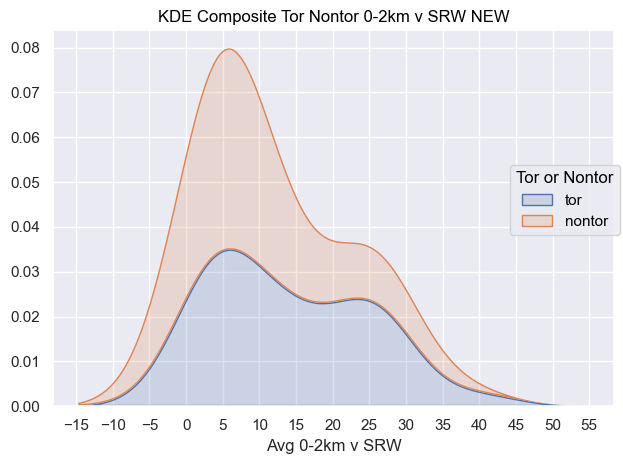

In [559]:
#plt.figure(figsize = (12, 4))
df = comp_ALL
df = df[df['wind'] == 'v']
p = so.Plot(df, x=195, color='Tor or Nontor').add(
    sns.objects.Area(), sns.objects.KDE(common_norm=False), so.Stack()).label(
    x = 'Avg 0-2km v SRW', title = 'KDE Composite Tor Nontor 0-2km v SRW NEW').scale(x = so.Continuous().tick(every=5))
p.show()

In [620]:
x = np.nanmean(comp_tor_all_new_copy[comp_tor_all_new_copy['wind'] == 'v'][195], axis=0)
print(f'Mean TOR composite v SRW: {x}')

Mean TOR composite v SRW: 14.057735377277474


In [621]:
y = np.nanmean(comp_nontor_all_new_copy[comp_nontor_all_new_copy['wind'] == 'v'][195], axis=0)
print(f'Mean NONTOR composite v SRW: {y}')

Mean NONTOR composite v SRW: 9.972730913731565


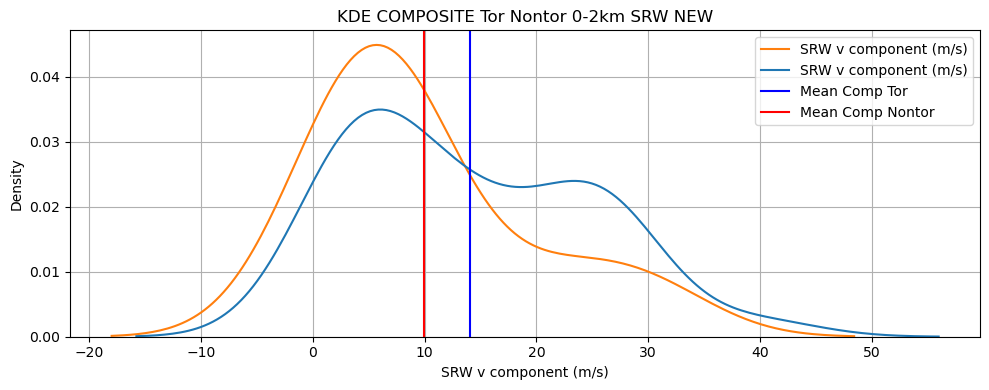

In [630]:
#plt.figure(figsize = (12, 4))
df = comp_ALL
df = df[df['wind'] == 'v']
fig = plt.figure(figsize=(10, 4))
p = sns.kdeplot(df, x=195, hue='Tor or Nontor', common_norm=False, label = 'SRW v component (m/s)')
                
plt.title('KDE COMPOSITE Tor Nontor 0-2km SRW NEW')

plt.axvline(x, color='blue', label='Mean Comp Tor')
plt.axvline(y, color='red', label='Mean Comp Nontor')
plt.xlabel('SRW v component (m/s)')
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
#plt.figure(figsize = (12, 4))
df = comp_ALL
df = df[df['wind'] == 'v']
fig = plt.figure(figsize=(10, 4))
p = sns.kdeplot(df, x=195, hue='Tor or Nontor', common_norm=False, label = 'SRW v component (m/s)')
                
plt.title('KDE COMPOSITE Tor Nontor 0-2km SRW NEW')

plt.axvline(x, color='blue', label='Mean Comp Tor')
plt.axvline(x=y, color='red', label='Mean Comp Nontor')
plt.xlabel('SRW v component (m/s)')
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

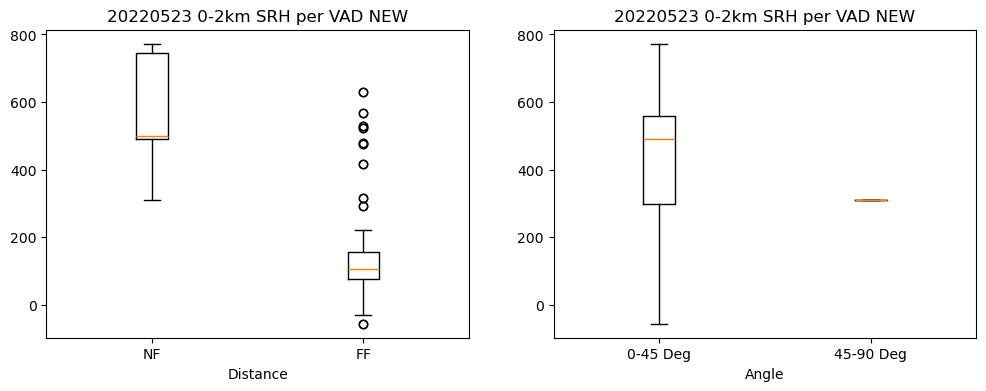

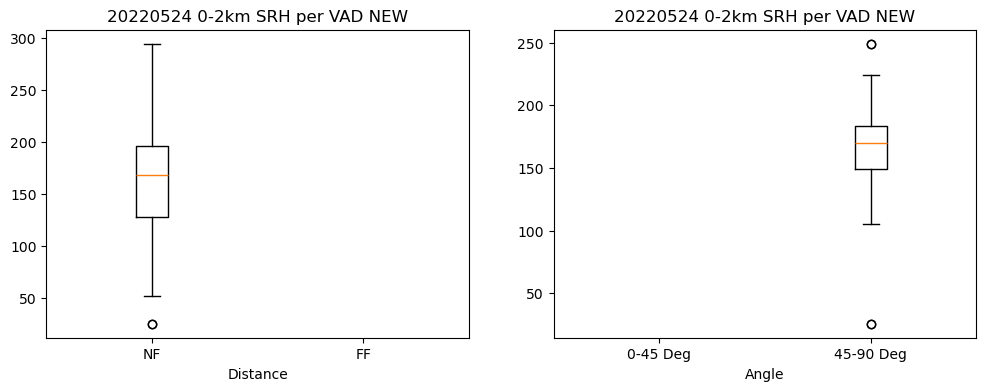

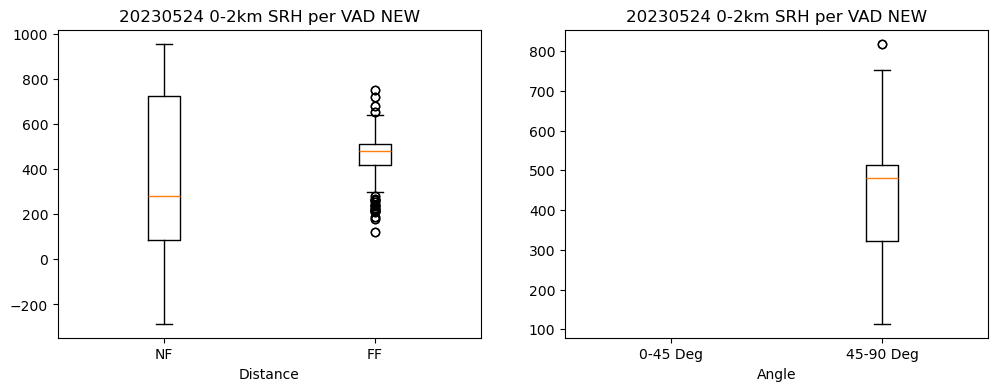

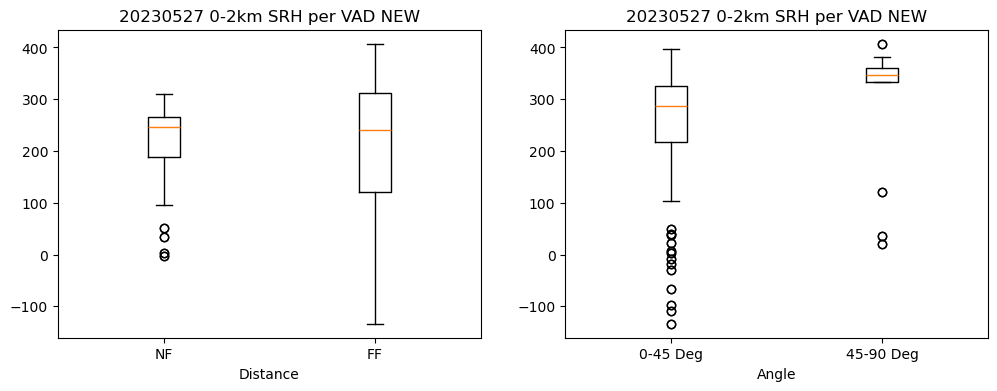

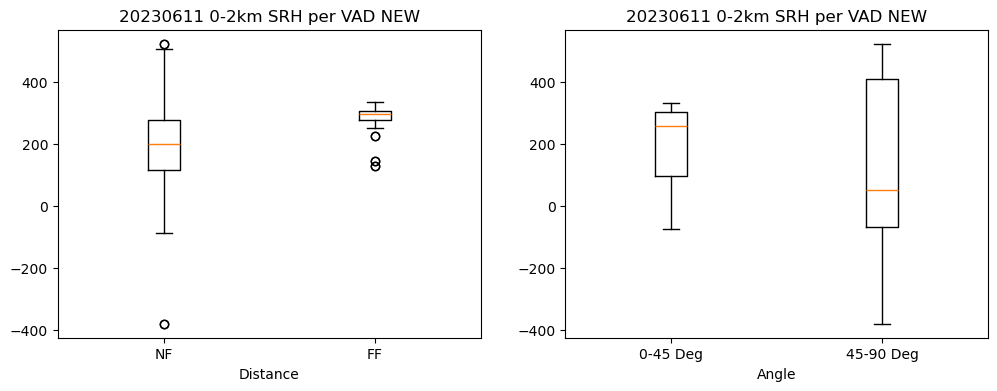

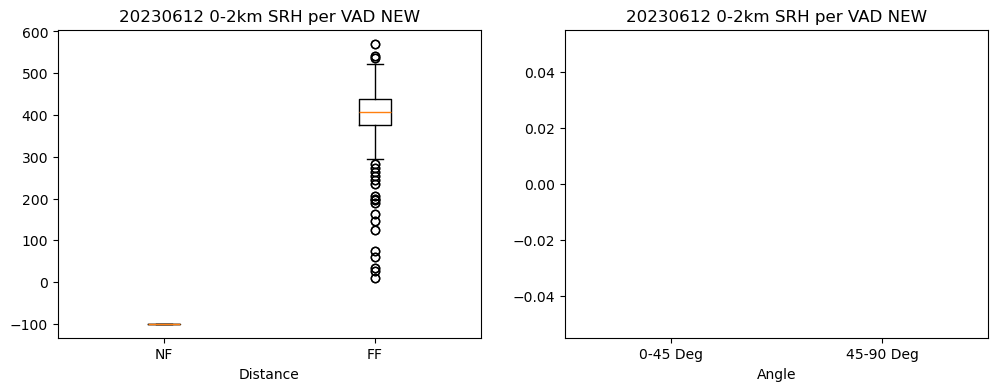

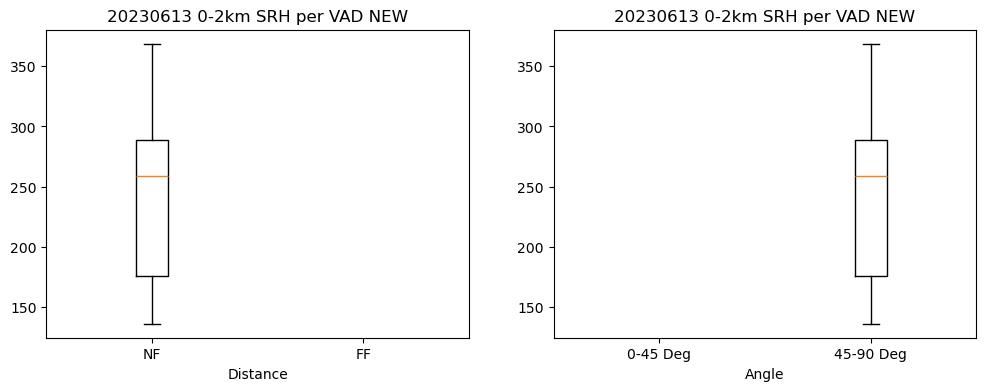

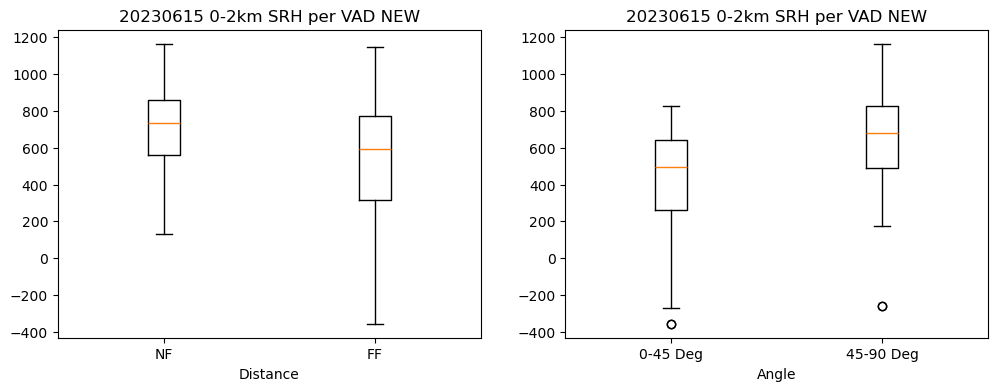

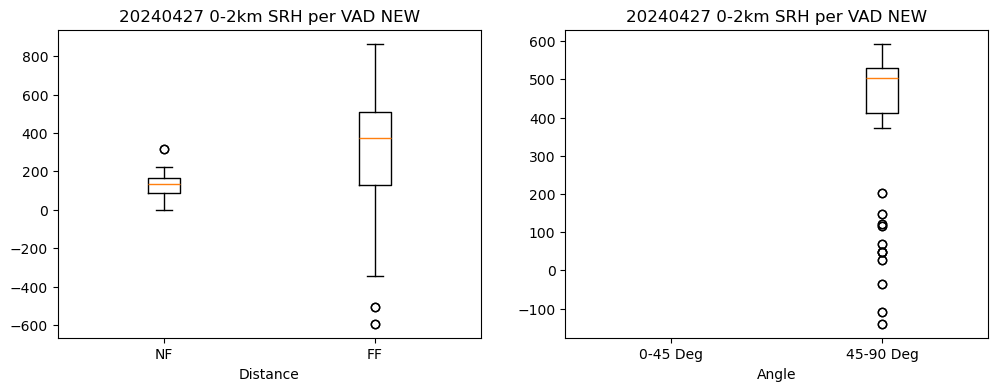

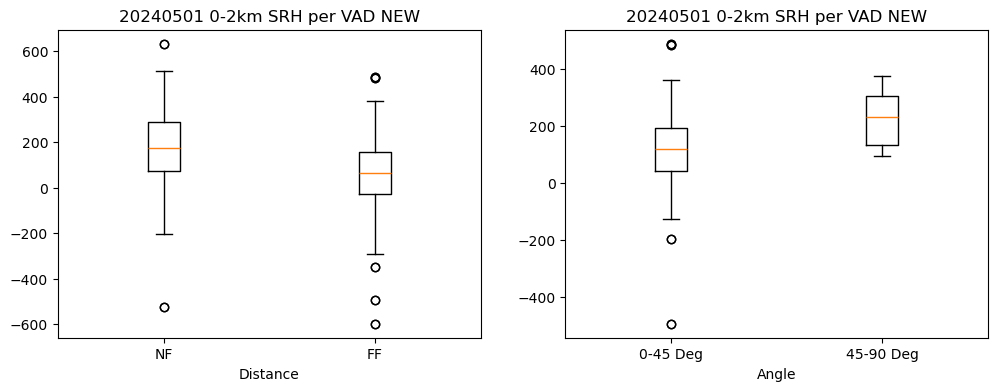

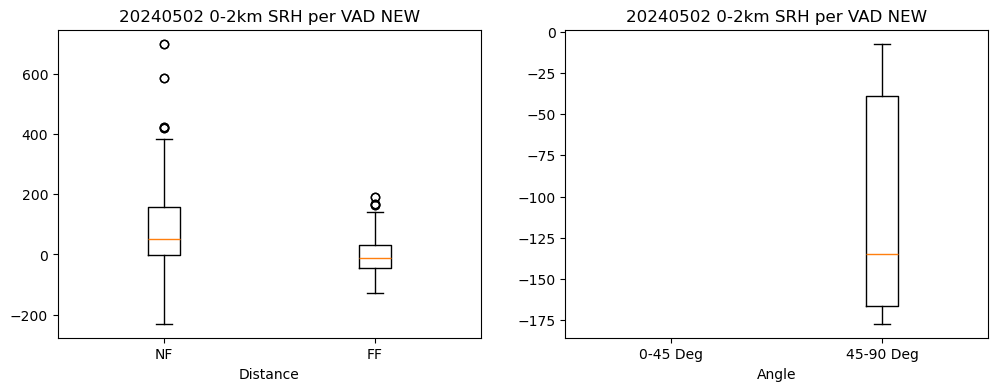

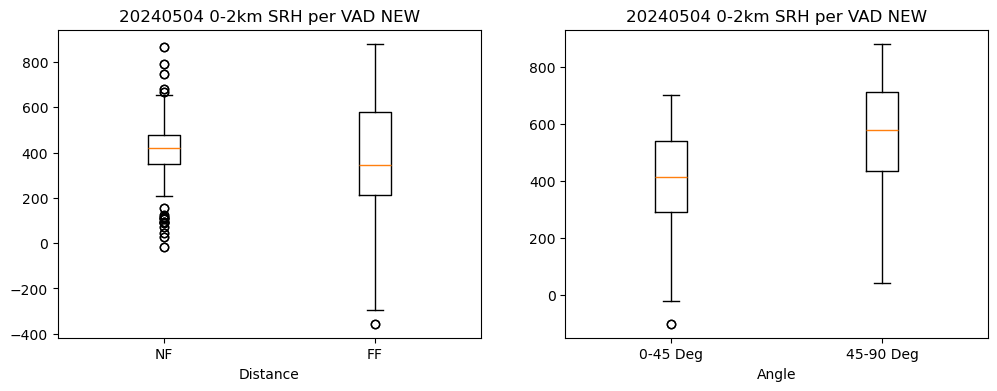

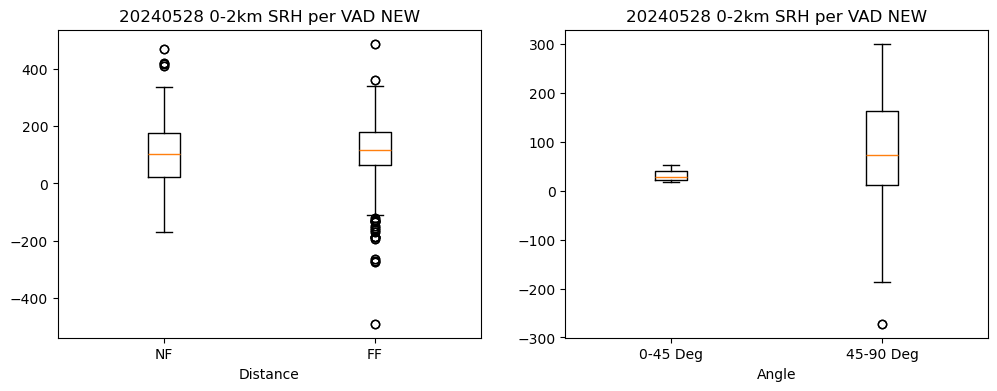

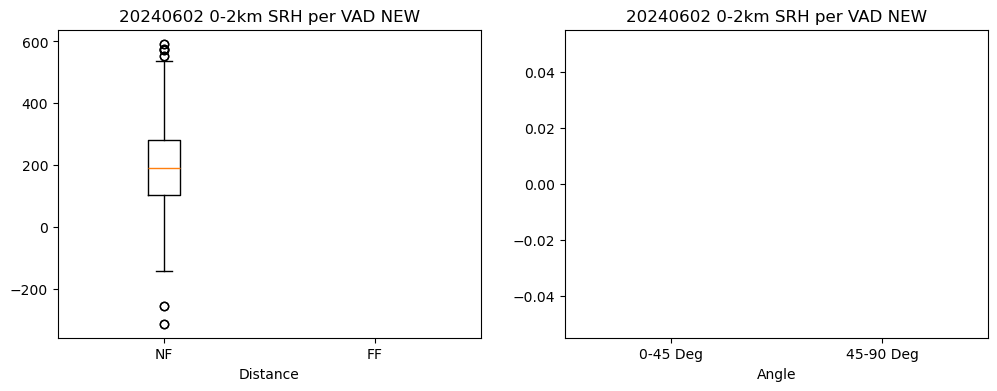

In [60]:
for d in sorted(set(df_all_new['Date'])):
    
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    ax0.boxplot([df_all_new[(df_all_new['Date'] == d) & (df_all_new['Distance'] < 21)]['0-2km SRH'],
               df_all_new[(df_all_new['Date'] == d) & (df_all_new['Distance'] >= 21)]['0-2km SRH']], labels=['NF', 'FF'])
    ax0.set_xlabel('Distance')
    ax0.set_title(f'{d} 0-2km SRH per VAD NEW')

    ax1.boxplot([df_all_new[(df_all_new['Date'] == d) & (df_all_new['Angle'] < 45)]['0-2km SRH'],
               df_all_new[(df_all_new['Date'] == d) & (df_all_new['Angle'] >= 45) & (df_all_new['Angle'] <= 90)]['0-2km SRH']], labels=['0-45 Deg', '45-90 Deg'])
    ax1.set_xlabel('Angle')
    ax1.set_title(f'{d} 0-2km SRH per VAD NEW')

    plt.show()

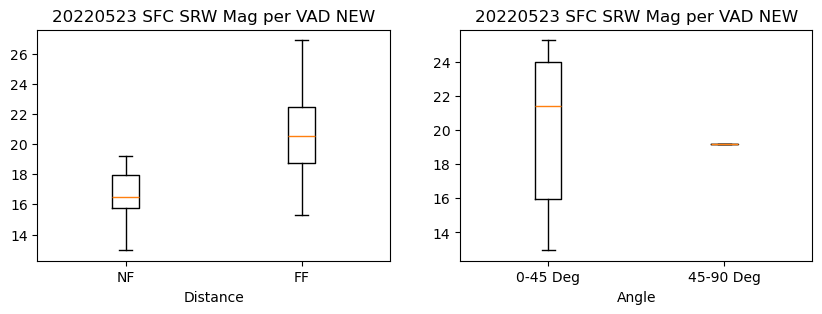

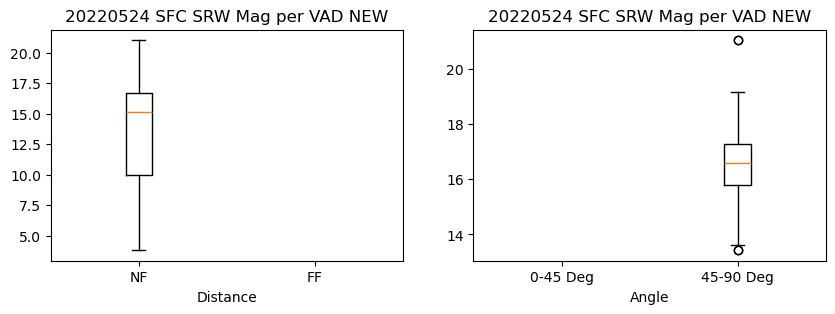

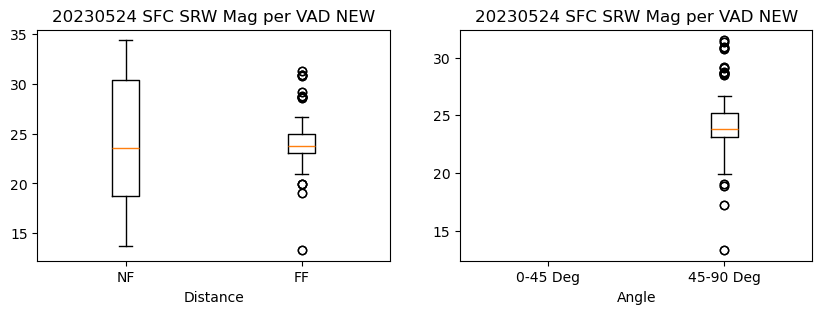

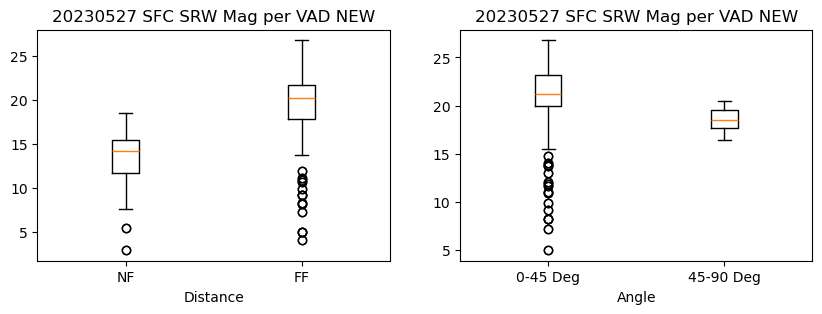

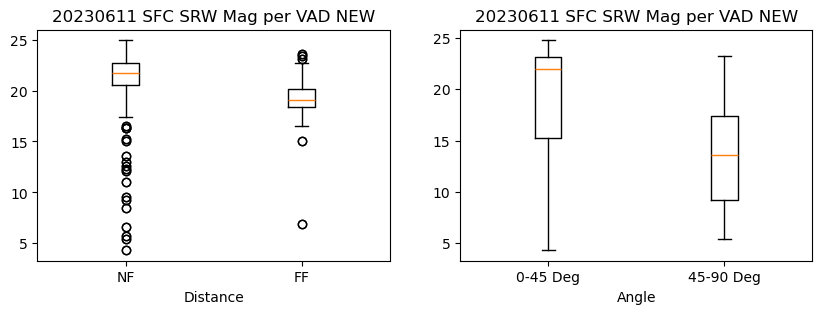

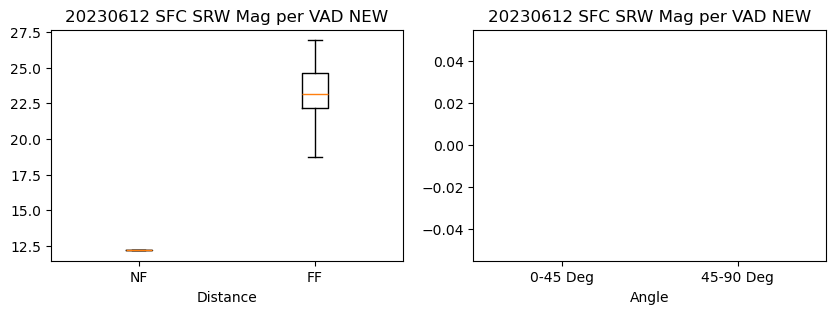

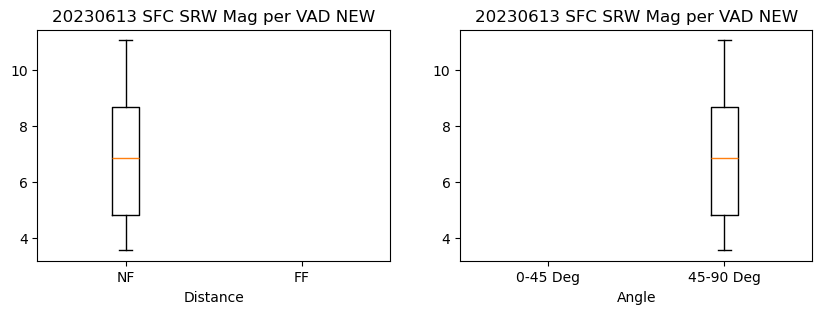

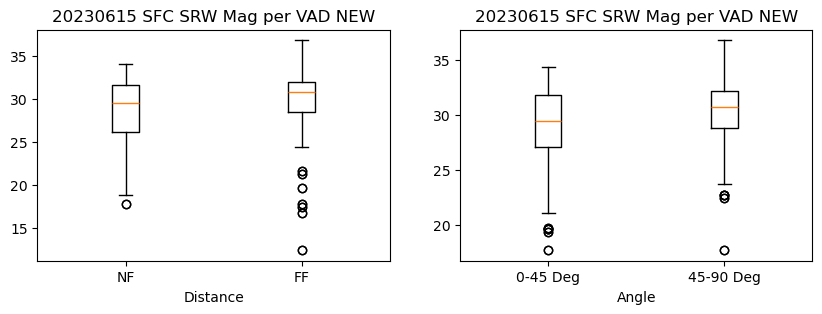

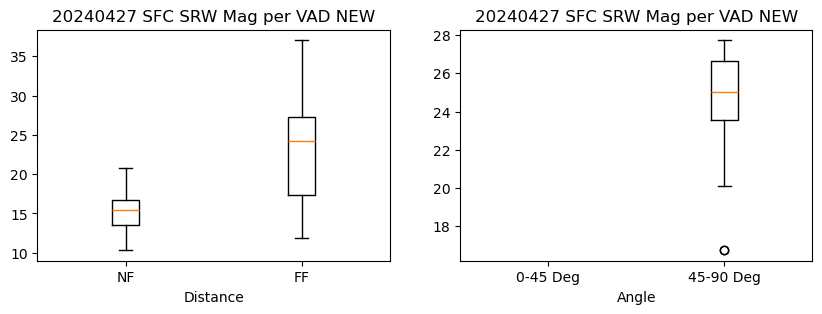

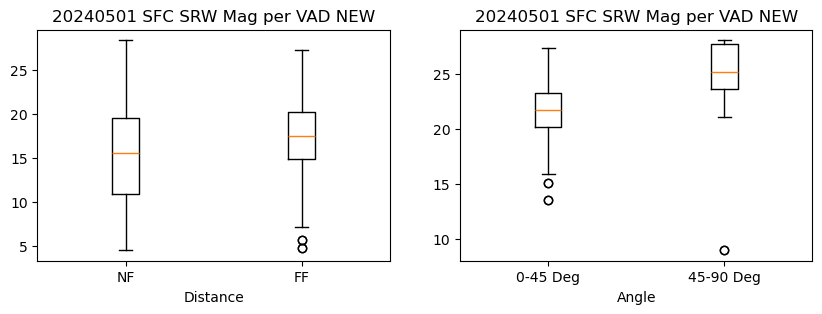

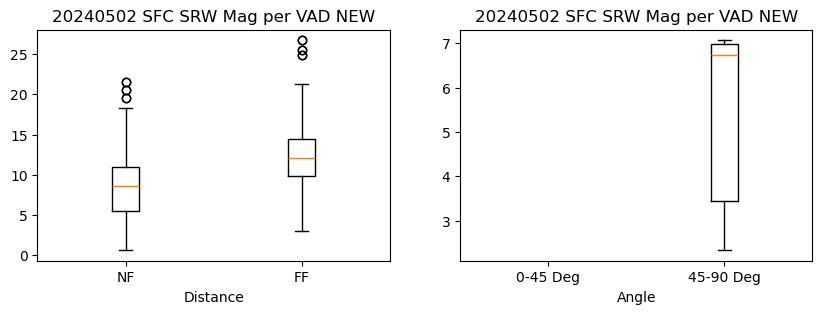

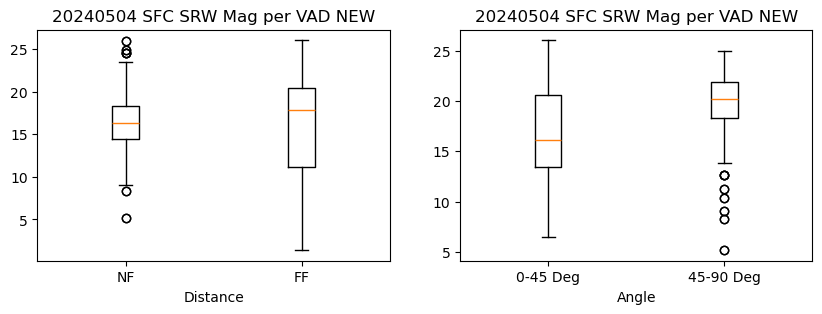

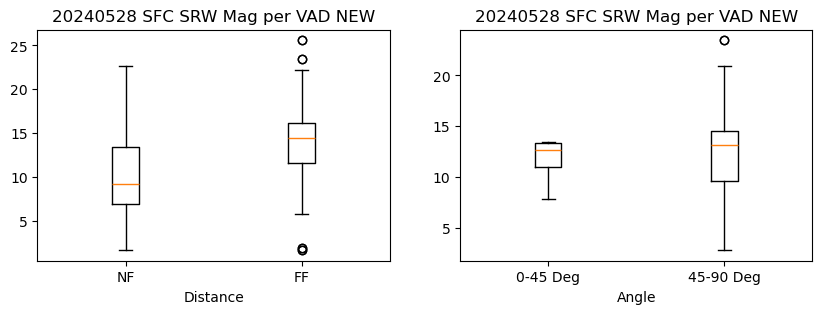

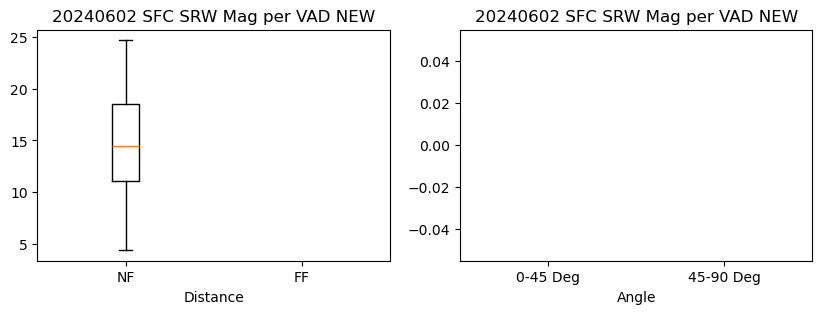

In [75]:
column = 'SRW Mag'
for d in sorted(set(df_all_new['Date'])):
    
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(10,3))
    ax0.boxplot([df_all_new[(df_all_new['Date'] == d) & (df_all_new['Distance'] < 21)][f'{column}'],
               df_all_new[(df_all_new['Date'] == d) & (df_all_new['Distance'] >= 21)][f'{column}']], labels=['NF', 'FF'])
    ax0.set_xlabel('Distance')
    ax0.set_title(f'{d} SFC SRW Mag per VAD NEW')

    ax1.boxplot([df_all_new[(df_all_new['Date'] == d) & (df_all_new['Angle'] < 45)][f'{column}'],
               df_all_new[(df_all_new['Date'] == d) & (df_all_new['Angle'] >= 45) & (df_all_new['Angle'] <= 90)][f'{column}']], labels=['0-45 Deg', '45-90 Deg'])
    ax1.set_xlabel('Angle')
    ax1.set_title(f'{d} SFC SRW Mag per VAD NEW')

    plt.show()

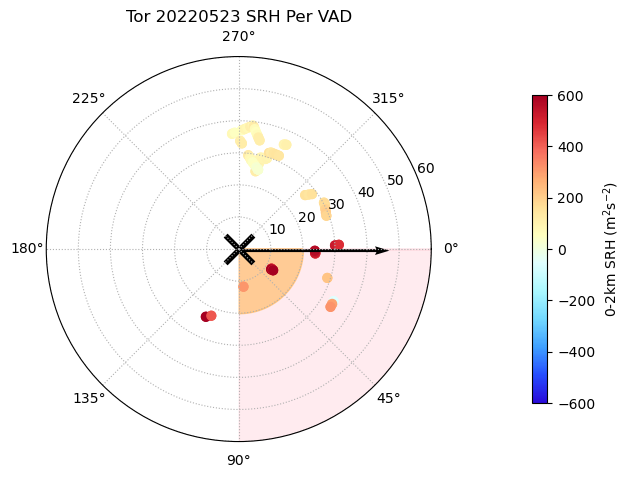

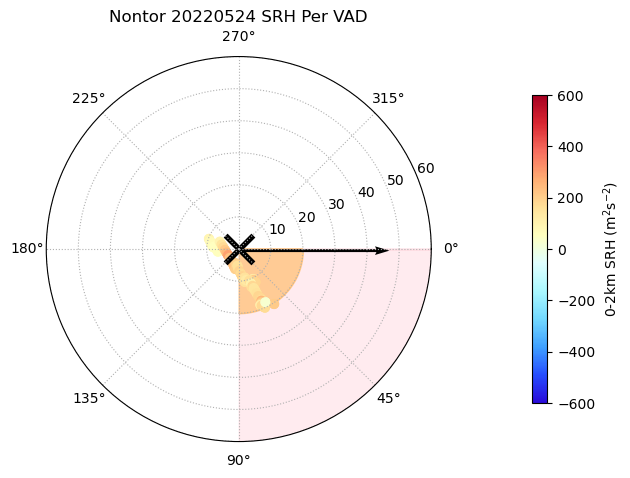

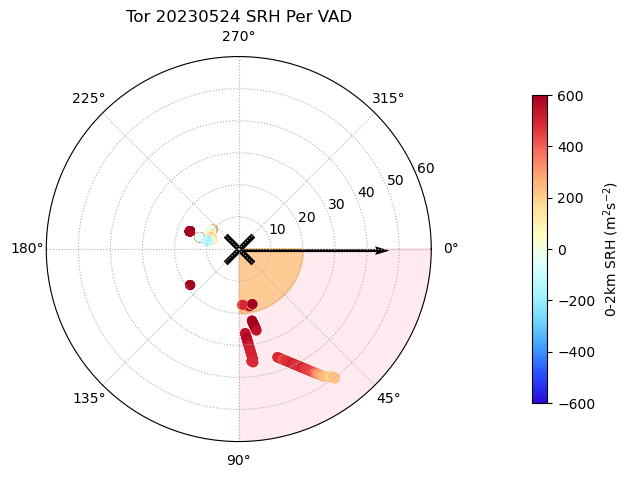

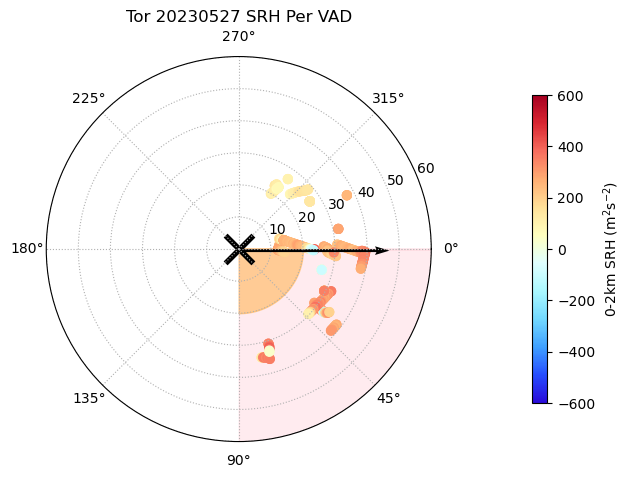

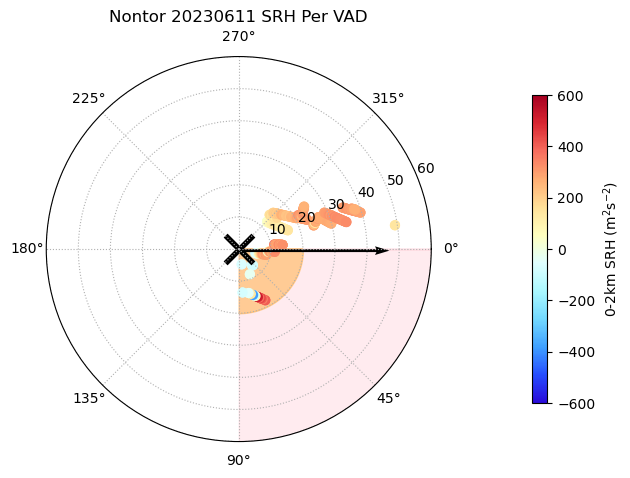

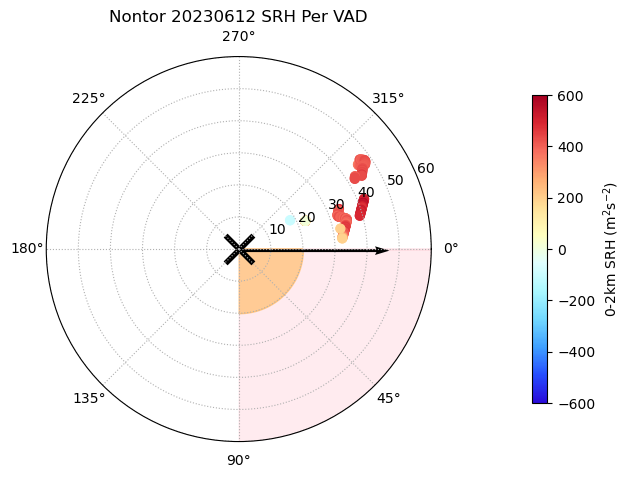

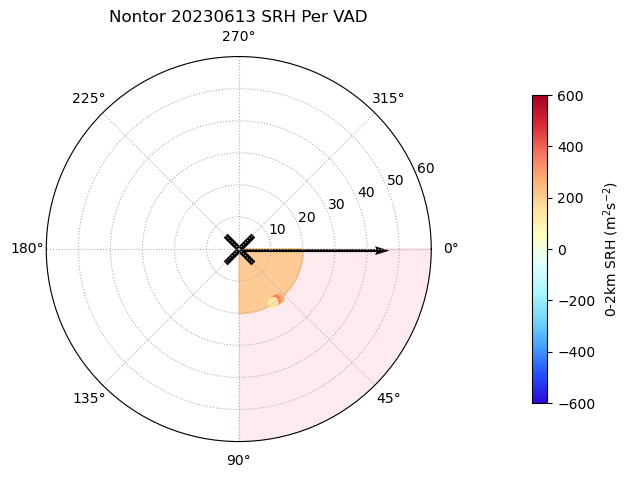

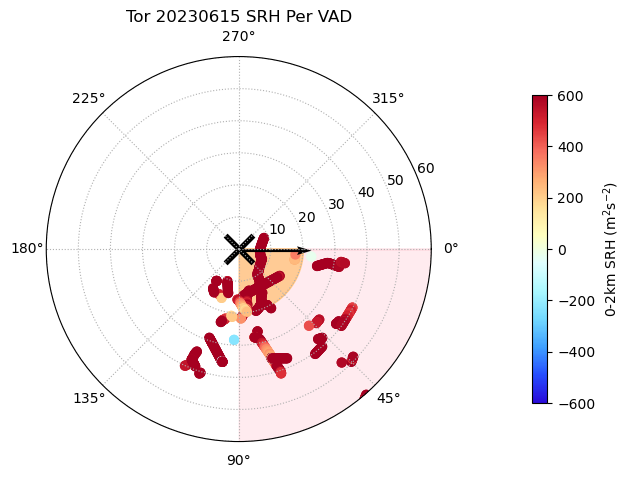

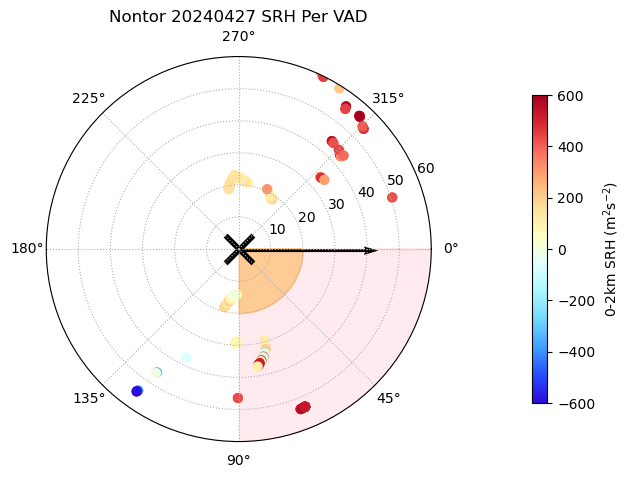

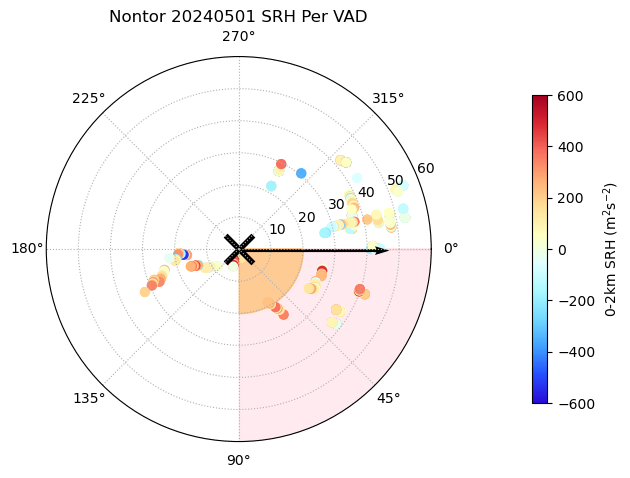

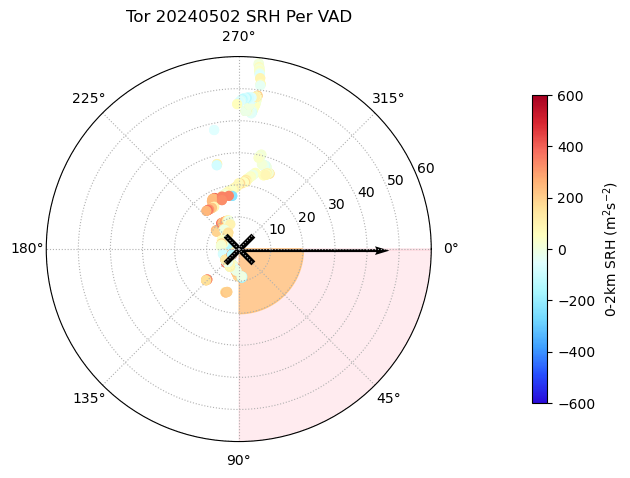

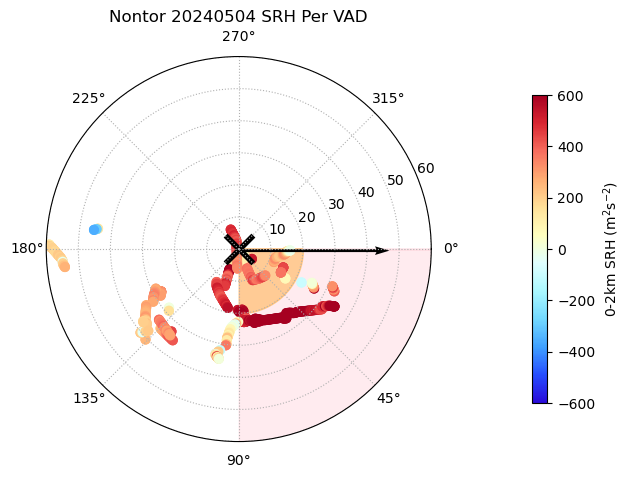

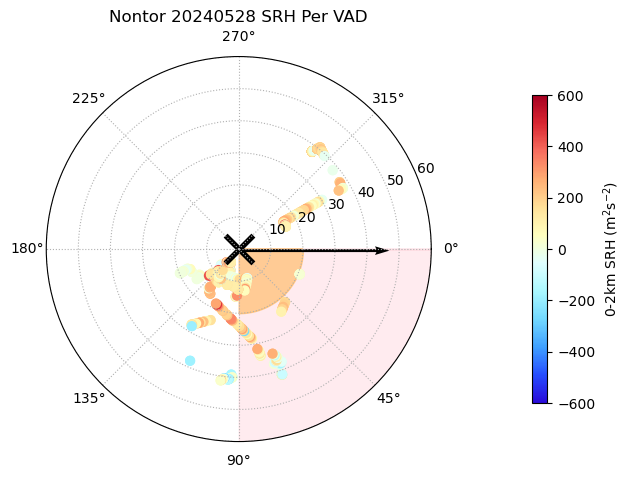

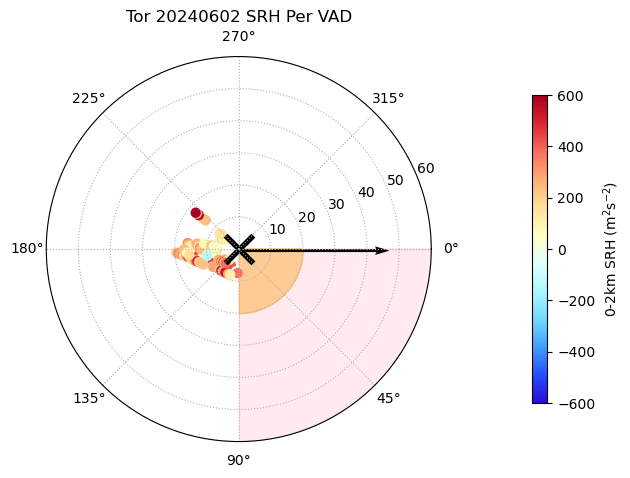

In [115]:
tor_srh_points = []
nontor_srh_points = []
for d in sorted(set(df_all_new['Date'])):
    title = f'{d} 0-2km SRH Per VAD'
    vmax = 600
    vmin = -600
    from matplotlib import rcParams, rcParamsDefault
    rcParams.update(rcParamsDefault)
    
    max_radius = 60
    #vmin = 0
    #vmax = 30
    
    # Create two subplots side by side
    fig, (ax0) = plt.subplots(nrows=1, ncols=1, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
    plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots
    
    # ========== First Subplot (Tornadic VADs) ==========
    ax0.set_rlabel_position(-22.5)
    ax0.grid(True, linestyle=':')
   # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax0.set_theta_zero_location('E')
    ax0.set_theta_direction(-1)
    ax0.set_ylim([0, max_radius])
    
    # Shade regions
    nf = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
    ff = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')
    
    df_all_new_date = df_all_new[(df_all_new['Date'] == d)]

    if df_all_new_date['Time From Tor (min)'].ne('nontor').any():
        
        # Tornadic points
        tor_points = ax0.scatter(df_all_new_date['Angle'] * (np.pi/180), df_all_new_date['Distance'], 
                                 c=df_all_new_date['0-2km SRH'], s=40, cmap='pyart_BuDRd12', vmin=vmin, vmax=vmax)
        tor_srh_points.append(tor_points)
        
        plt.title(f'Tor {d} SRH Per VAD')

    if df_all_new_date['Time From Tor (min)'].eq('nontor').any():
    
        nontor_points = ax0.scatter(df_all_new_date['Angle'] * (np.pi/180), df_all_new_date['Distance'], 
                                 c=df_all_new_date['0-2km SRH'], s=40, cmap='pyart_BuDRd12', vmin=vmin, vmax=vmax)
        nontor_srh_points.append(nontor_points)
        
        plt.title(f'Nontor {d} SRH Per VAD')
        
    theta_start = np.deg2rad(100)
    ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
        
    # Colorbar
    cbar = fig.colorbar(tor_points, ax=[ax0], pad=0.1, shrink=0.8)
    cbar.set_label('0-2km SRH (m$^{2}$s$^{-2})$')
    
    #plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
    # Legend
    #plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
   # plt.legend([storm_motion, nf, ff, meso], 
               #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)
    
    
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
    #fig.tight_layout()
    plt.show()

In [ ]:
title = f'{d} 0-2km SRH Per VAD'
vmax = 600
vmin = -600
from matplotlib import rcParams, rcParamsDefault
rcParams.update(rcParamsDefault)

max_radius = 60
#vmin = 0
#vmax = 30

# Create two subplots side by side
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=1, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots

# ========== First Subplot (Tornadic VADs) ==========
ax0.set_rlabel_position(-22.5)
ax0.grid(True, linestyle=':')
# ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
ax0.set_theta_zero_location('E')
ax0.set_theta_direction(-1)
ax0.set_ylim([0, max_radius])

ax1.set_rlabel_position(-22.5)
ax1.grid(True, linestyle=':')
# ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
ax1.set_theta_zero_location('E')
ax1.set_theta_direction(-1)
ax1.set_ylim([0, max_radius])

# Shade regions
nf = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
ff = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')

tor_points = ax0.scatter(df_all_new_date['Angle'] * (np.pi/180), df_all_new_date['Distance'], 
                             c=df_all_new_date['0-2km SRH'], s=40, cmap='pyart_BuDRd12', vmin=vmin, vmax=vmax)

ax0.set_title(f'Tor SRH Per VAD')

theta_start = np.deg2rad(100)
ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)

nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')

nontor_points = ax1.scatter(df_all_new_date['Angle'] * (np.pi/180), df_all_new_date['Distance'], 
                             c=df_all_new_date['0-2km SRH'], s=40, cmap='pyart_BuDRd12', vmin=vmin, vmax=vmax)

ax1.set_title(f'Nontor SRH Per VAD')

theta_start = np.deg2rad(100)
ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
# Colorbar
cbar = fig.colorbar(tor_points, ax=[ax0], pad=0.1, shrink=0.8)
cbar.set_label('0-2km SRH (m$^{2}$s$^{-2})$')


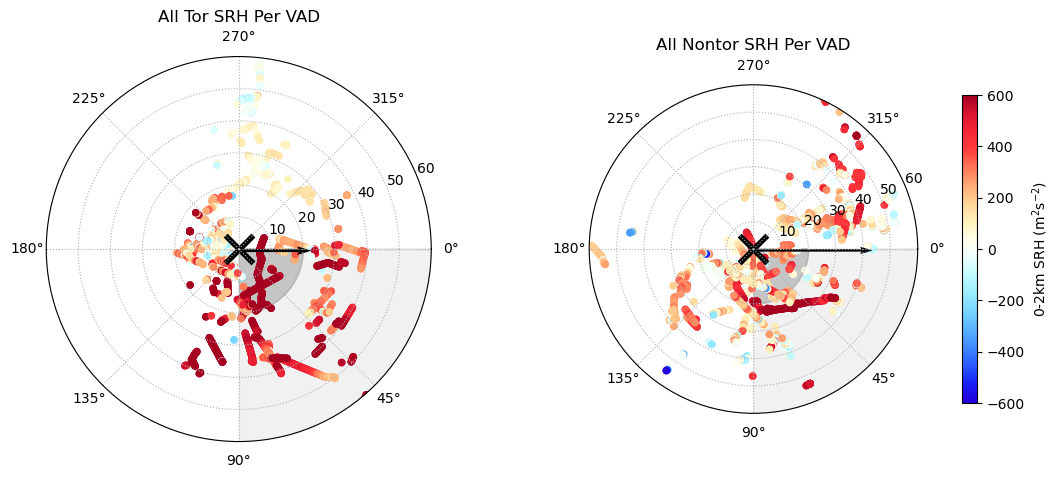

In [339]:
#title = f'{d} 0-2km SRH Per VAD'
vmax = 600
vmin = -600
from matplotlib import rcParams, rcParamsDefault
rcParams.update(rcParamsDefault)

max_radius = 60
#vmin = 0
#vmax = 30


# Create two subplots side by side
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots

# ========== First Subplot (Tornadic VADs) ==========
ax0.set_rlabel_position(-22.5)
ax0.grid(True, linestyle=':')
# ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
ax0.set_theta_zero_location('E')
ax0.set_theta_direction(-1)
ax0.set_ylim([0, max_radius])

# Shade regions
nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')

df_all_new_tor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']

# Tornadic points
tor_points = ax0.scatter(df_all_new_tor['Angle'] * (np.pi/180), df_all_new_tor['Distance'], 
                         c=df_all_new_tor['0-2km SRH'], s=20, cmap='pyart_BuDRd18', vmin=vmin, vmax=vmax)

ax0.set_title(f'All Tor SRH Per VAD')

ax1.set_rlabel_position(-22.5)
ax1.grid(True, linestyle=':')
# ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
ax1.set_theta_zero_location('E')
ax1.set_theta_direction(-1)
ax1.set_ylim([0, max_radius])
# Shade regions
nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')


df_all_new_nontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']

nontor_points = ax1.scatter(df_all_new_nontor['Angle'] * (np.pi/180), df_all_new_nontor['Distance'], 
                         c=df_all_new_nontor['0-2km SRH'], s=20, cmap='pyart_BuDRd18', vmin=vmin, vmax=vmax)
ax1.set_title(f'All Nontor SRH Per VAD')

# nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
# ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')

theta_start = np.deg2rad(100)
ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)

ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
# Colorbar
cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
cbar.set_label('0-2km SRH (m$^{2}$s$^{-2})$')

#plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
# Legend
#plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
# plt.legend([storm_motion, nf, ff, meso], 
           #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)

#plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
#fig.tight_layout()
plt.show()

In [ ]:
def tor_boxplot(data_dict, title):
    
    labels = ['NonTor', 'TorAll', 'PreTor', 'DuringTor', 'PostTor']

    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    
    ax0.boxplot([data_dict['nf_nontor'], data_dict['nf_tor'], data_dict['nf_pretor'], data_dict['nf_dtor'], 
                 data_dict['nf_posttor']], labels = labels)
    
    #ax0.set_xticks(ticks = labels)
    #ax0.set_yticks(fontsize=13)
    ax0.set_ylabel('Shear Magnitude (m/s)', fontweight='bold', fontsize=10)
    ax0.grid()
    ax0.set_title(f'{title} Per Near-Field VAD', fontweight='bold', fontsize=10, wrap= True)
    
    ax1.boxplot([data_dict['ff_nontor'], data_dict['ff_tor'], data_dict['ff_pretor'], data_dict['ff_dtor'], 
                 data_dict['ff_posttor']], labels = labels)
    
    ax1.set_ylabel('Shear Magnitude (m/s)', fontweight='bold', fontsize=10)
    ax1.grid()
    ax1.set_title(f'{title} Per Far-Field VAD', fontweight='bold', fontsize=10, wrap=True)
    
    fig.tight_layout()
    plt.show()

In [ ]:
tor_boxplot(mag_all_500m, '0-500m Shear Magnitude')

In [ ]:
tor_boxplot(mag_all_500m_new, '0-500m Shear Magnitude NEW')

In [ ]:
tor_boxplot(mag_all_1km, '0-1km Shear Magnitude')

In [ ]:
tor_boxplot(mag_all_1km_new, '0-1km Shear Magnitude NEW')

In [ ]:
tor_boxplot(mag_all_2km, '0-2km Shear Magnitude')

In [ ]:
tor_boxplot(mag_all_2km_new, '0-2km Shear Magnitude NEW')

In [ ]:
def values_polar_plot(nf_u_categories_new, ff_u_categories_new, mag_all_500m_new, title): 
    from matplotlib import rcParams, rcParamsDefault
    rcParams.update(rcParamsDefault)
    
    max_radius = 60
    vmin = 0
    vmax = 10
    
    # Create two subplots side by side
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
    plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots
    
    # ========== First Subplot (Tornadic VADs) ==========
    ax0.set_rlabel_position(-22.5)
    ax0.grid(True, linestyle=':')
    ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax0.set_theta_zero_location('E')
    ax0.set_theta_direction(-1)
    ax0.set_ylim([0, max_radius])
    
    # Shade regions
    nf = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
    ff = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')
    
    # Tornadic points
    nf_points = ax0.scatter(nf_u_categories_new['tor'].Angle * (np.pi/180), nf_u_categories_new['tor'].Distance, 
                             c=mag_all_500m_new['nf_tor'], s=40, cmap='pyart_BuDRd12', vmin=vmin, vmax=vmax)
    
    ff_points = ax0.scatter(ff_u_categories_new['tor'].Angle * (np.pi/180), ff_u_categories_new['tor'].Distance, 
                             c=mag_all_500m_new['ff_tor'], s=40, cmap='pyart_BuDRd12', vmin=vmin, vmax=vmax)
    
    # Add storm motion and mesocyclone marker
    theta_start = np.deg2rad(100)
    storm_motion = ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    meso = ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
    # ========== Second Subplot (Nontornadic VADs) ==========
    ax1.set_rlabel_position(-22.5)
    ax1.grid(True, linestyle=':')
    ax1.set_title('Nontornadic VADs', fontsize=13, fontweight='bold')
    ax1.set_theta_zero_location('E')
    ax1.set_theta_direction(-1)
    ax1.set_ylim([0, max_radius])
    
    # Shade regions (Same as ax0)
    ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5)
    ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3)
    
    # Nontornadic points (now in ax1)
    nfnontor_points = ax1.scatter(nf_u_categories_new['nontor'].Angle * (np.pi/180), nf_u_categories_new['nontor'].Distance, 
                                  c=mag_all_500m_new['nf_nontor'], s=40, cmap='pyart_BuDRd12', vmin=vmin, vmax=vmax, marker='o')
    
    ffnontor_points = ax1.scatter(ff_u_categories_new['nontor'].Angle * (np.pi/180), ff_u_categories_new['nontor'].Distance, 
                                  c=mag_all_500m_new['ff_nontor'], s=40, cmap='pyart_BuDRd12', vmin=vmin, vmax=vmax, marker='o')
    
    theta_start = np.deg2rad(100)
    ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
    # Colorbar
    cbar = fig.colorbar(nf_points, ax=[ax0, ax1], pad=0.1, shrink=0.8)
    cbar.set_label('0-500m Shear Magnitude (m$^{2}$s$^{-1})$')
    
    plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
    # Legend
    #plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
    plt.legend([storm_motion, nf, ff, meso], 
               ['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)
    
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
    #fig.tight_layout()
    plt.show()

In [ ]:
values_polar_plot(nf_u_categories_new, ff_u_categories_new, mag_all_500m_new, '0-500m Shear Magnitude Per VAD')

In [ ]:
def values_polar_plot_srw(nf_u_categories_new, ff_u_categories_new, srw_all_new, hmin, title, vmax):
    
    from matplotlib import rcParams, rcParamsDefault
    rcParams.update(rcParamsDefault)
    
    max_radius = 60
    vmin = 0
    #vmax = 30
    
    # Create two subplots side by side
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
    plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots
    
    # ========== First Subplot (Tornadic VADs) ==========
    ax0.set_rlabel_position(-22.5)
    ax0.grid(True, linestyle=':')
    ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax0.set_theta_zero_location('E')
    ax0.set_theta_direction(-1)
    ax0.set_ylim([0, max_radius])
    
    # Shade regions
    nf = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
    ff = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')
    
    # Tornadic points
    nf_points = ax0.scatter(nf_u_categories_new['tor'].Angle * (np.pi/180), nf_u_categories_new['tor'].Distance, 
                             c=srw_all_new['nf_tor'][hmin,:], s=40, cmap='pyart_BuDRd12', vmin=vmin, vmax=vmax)
    
    ff_points = ax0.scatter(ff_u_categories_new['tor'].Angle * (np.pi/180), ff_u_categories_new['tor'].Distance, 
                             c=srw_all_new['ff_tor'][hmin,:], s=40, cmap='pyart_BuDRd12', vmin=vmin, vmax=vmax)
    
    # Add storm motion and mesocyclone marker
    theta_start = np.deg2rad(100)
    storm_motion = ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    meso = ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
    # ========== Second Subplot (Nontornadic VADs) ==========
    ax1.set_rlabel_position(-22.5)
    ax1.grid(True, linestyle=':')
    ax1.set_title('Nontornadic VADs', fontsize=13, fontweight='bold')
    ax1.set_theta_zero_location('E')
    ax1.set_theta_direction(-1)
    ax1.set_ylim([0, max_radius])
    
    # Shade regions (Same as ax0)
    ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5)
    ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3)
    
    # Nontornadic points (now in ax1)
    nfnontor_points = ax1.scatter(nf_u_categories_new['nontor'].Angle * (np.pi/180), nf_u_categories_new['nontor'].Distance, 
                                  c=srw_all_new['nf_nontor'][hmin,:], s=40, cmap='pyart_BuDRd12', vmin=vmin, vmax=vmax, marker='o')
    
    ffnontor_points = ax1.scatter(ff_u_categories_new['nontor'].Angle * (np.pi/180), ff_u_categories_new['nontor'].Distance, 
                                  c=srw_all_new['ff_nontor'][hmin,:], s=40, cmap='pyart_BuDRd12', vmin=vmin, vmax=vmax, marker='o')
    
    theta_start = np.deg2rad(100)
    ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
    # Colorbar
    cbar = fig.colorbar(nf_points, ax=[ax0, ax1], pad=0.1, shrink=0.8)
    cbar.set_label('0-500m Shear Magnitude (m$^{2}$s$^{-1})$')
    
    plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
    # Legend
    #plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
    plt.legend([storm_motion, nf, ff, meso], 
               ['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)
    
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
    #fig.tight_layout()
    plt.show()

In [ ]:
values_polar_plot_srw(nf_u_categories_new, ff_u_categories_new, srw_all_new, 0, 'SFC SRW Magnitude Per VAD New', vmax=30)

In [ ]:
values_polar_plot_srw(nf_u_categories_new, ff_u_categories_new, srw_all_new, 50, '500m SRW Magnitude Per VAD New', vmax=35)

In [ ]:
values_polar_plot_srw(nf_u_categories_new, ff_u_categories_new, srw_all_new, 100, '1km SRW Magnitude Per VAD New', vmax=35)

In [ ]:
values_polar_plot_srw(nf_u_categories_new, ff_u_categories_new, srw_all_new, 194, '2km SRW Magnitude Per VAD New', vmax=35)

# Case Metadata

Per Case

In [ ]:
for d in sorted(set(df_all_new['Date'])):
    counts_dist, bins_dist = np.histogram(df_all_new[df_all_new['Date'] == d]['Distance'])
    counts_angle, bins_angle = np.histogram(df_all_new[df_all_new['Date'] == d]['Angle'])
    
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    ax0.hist(bins_dist[:-1], bins_dist, weights=counts_dist)
    ax0.set_xlabel('Distance From Meso (km)')
    ax0.set_ylabel('VADs Count')
    ax0.set_title(f'Tornadic Case VADs Count per Distance {d} NEW')
    ax1.hist(bins_angle[:-1], bins_angle, weights=counts_angle)
    ax1.set_xlabel('VAD Bearing Relative to Meso (Degrees from East)')
    ax1.set_title(f'Case VADs Count per Angle {d} NEW')
    fig.suptitle(f'{d} VADs Distance and Angle Relative to Meso NEW')
    plt.show()

All Cases

In [ ]:
counts_dist, bins_dist = np.histogram(df_all[df_all['Time From Tor (min)'] != 'nontor']['Distance'])

counts_angle, bins_angle = np.histogram(df_all[df_all['Time From Tor (min)'] != 'nontor']['Angle'])

fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
ax0.hist(bins_dist[:-1], bins_dist, weights=counts_dist)
ax0.set_xlabel('Distance From Meso (km)')
ax0.set_ylabel('VADs Count')
ax0.set_title('Tornadic Case VADs Count per Distance')
ax1.hist(bins_angle[:-1], bins_angle, weights=counts_angle)
ax1.set_xlabel('VAD Bearing Relative to Meso (Degrees from East)')
ax1.set_title('Tornadic Case VADs Count per Angle')
plt.show()

In [ ]:
counts_dist, bins_dist = np.histogram(df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']['Distance'])

counts_angle, bins_angle = np.histogram(df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']['Angle'])

fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
ax0.hist(bins_dist[:-1], bins_dist, weights=counts_dist)
ax0.set_xlabel('Distance From Meso (km)')
ax0.set_ylabel('VADs Count')
ax0.set_title('Tornadic Case VADs Count per Distance (New 2ndTrip)')
ax1.hist(bins_angle[:-1], bins_angle, weights=counts_angle)
ax1.set_xlabel('VAD Bearing Relative to Meso (Degrees from East)')
ax1.set_title('Tornadic Case VADs Count per Angle (New 2ndTrip)')
plt.show()

# Temporal SRH and SRW?

In [427]:
df_all_new

,0,1,2,3,4,5,6,7,8,9,...,Distance,Angle,Time From Tor (min),Datetime,Date,0-2km SRH,SRW Mag,Rounded_Angle,Rounded_SRH,Rounded_Distance
0,-16.835770,-16.755274,-16.687143,-16.646894,-16.591278,-16.606508,-16.596056,-16.624393,-16.698717,-16.813435,...,24.796636,282.132826,-54.833333,2022-05-23 22:55:10,20220523,119.748598,18.084001,280.0,100.0,20.0
1,-14.939102,-15.009944,-15.074447,-15.129332,-15.258727,-15.290950,-15.374236,-15.448551,-15.529462,-15.613126,...,25.813325,282.602215,-54.333333,2022-05-23 22:55:40,20220523,98.612390,16.929266,280.0,100.0,30.0
2,-14.908146,-15.014770,-15.122228,-15.226007,-15.440908,-15.526935,-15.692964,-15.829327,-15.938499,-16.014187,...,26.810463,283.027394,-53.833333,2022-05-23 22:56:10,20220523,100.986069,16.606345,280.0,100.0,30.0
3,-14.967583,-15.150704,-15.295214,-15.410604,-15.666528,-15.871101,-15.918962,-16.046745,-16.148834,-16.246586,...,27.817252,283.424013,-53.35,2022-05-23 22:56:39,20220523,90.521531,17.077444,280.0,100.0,30.0
4,-15.580977,-15.710516,-15.809145,-15.890134,-16.091858,-16.142567,-16.262787,-16.348358,-16.409420,-16.458860,...,28.820999,283.791452,-52.85,2022-05-23 22:57:09,20220523,104.417661,18.654303,280.0,100.0,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6595,-1.635275,-1.568471,-1.420855,-1.320286,-1.320286,-1.102728,-1.051306,-0.936231,-0.836507,-0.828301,...,17.730159,10.589711,63.566667,2023-06-16 00:34:34,20230615,244.074307,23.652900,10.0,200.0,20.0
6596,-3.691865,-3.578943,-3.513133,-3.421503,-3.421503,-3.236247,-3.157359,-3.030900,-2.966462,-2.847811,...,17.730159,5.589711,63.783333,2023-06-16 00:34:47,20230615,226.896842,23.917808,10.0,200.0,20.0
6597,-3.230326,-3.062784,-2.947798,-2.882831,-2.882831,-2.730972,-2.657030,-2.451415,-2.396161,-2.222835,...,17.730159,5.589711,64.0,2023-06-16 00:35:00,20230615,206.528619,26.158343,10.0,200.0,20.0
6598,-4.028626,-3.970635,-3.912552,-3.842394,-3.842394,-3.703241,-3.636965,-3.529508,-3.464480,-3.379116,...,17.730194,5.590613,66.033333,2023-06-16 00:37:02,20230615,218.595898,26.418142,10.0,200.0,20.0


<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

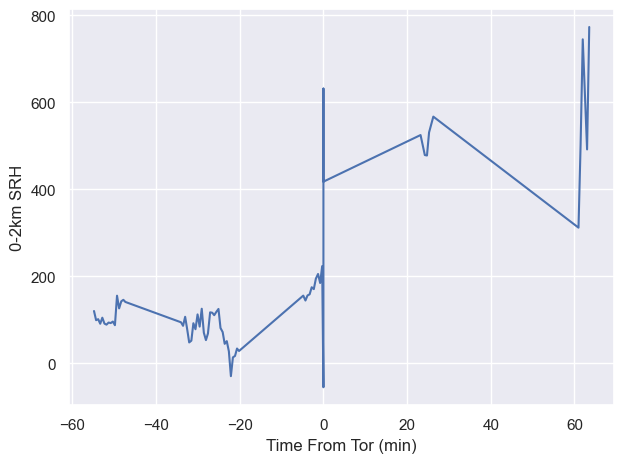

<Figure size 600x400 with 0 Axes>

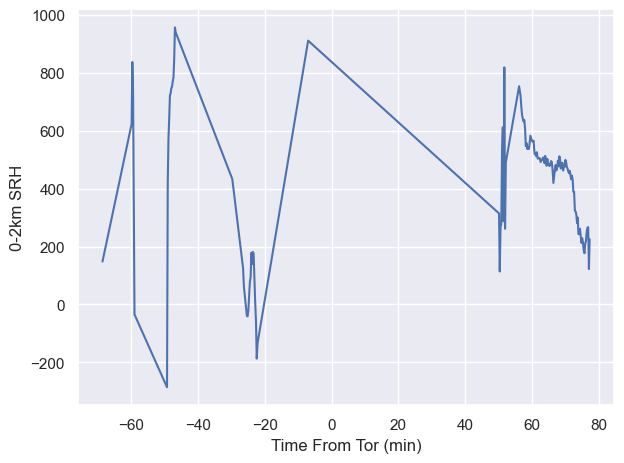

<Figure size 600x400 with 0 Axes>

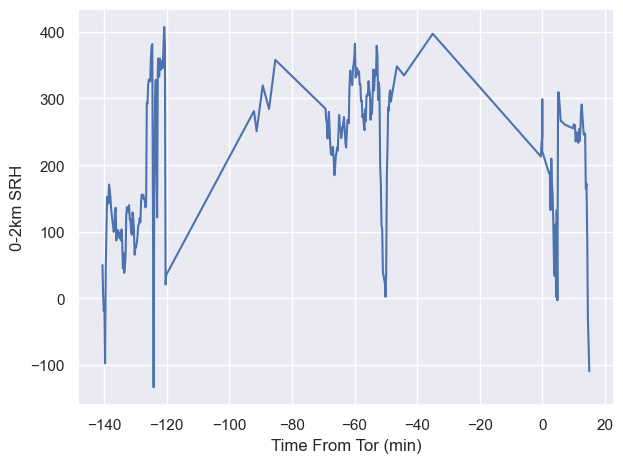

<Figure size 600x400 with 0 Axes>

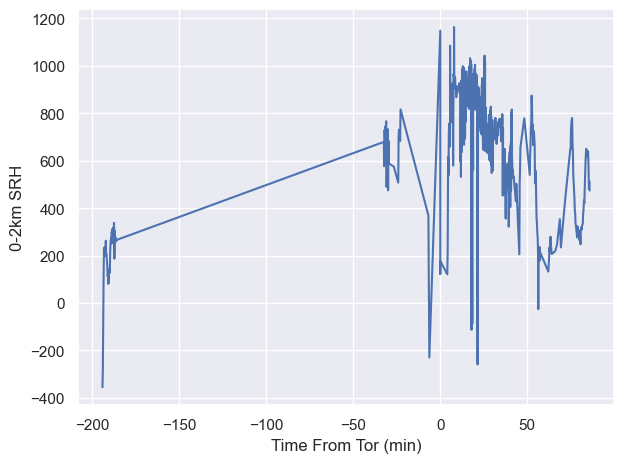

<Figure size 600x400 with 0 Axes>

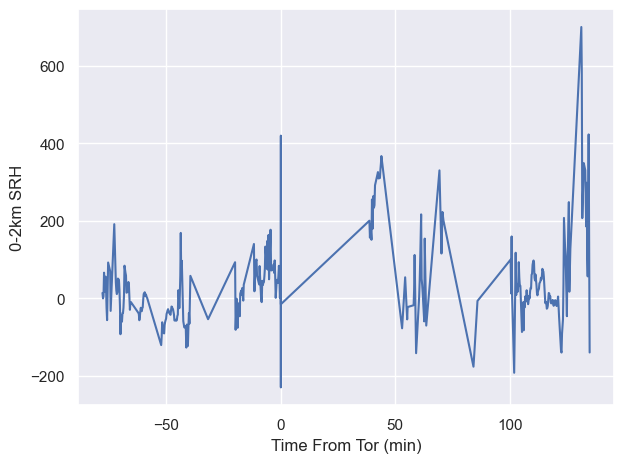

<Figure size 600x400 with 0 Axes>

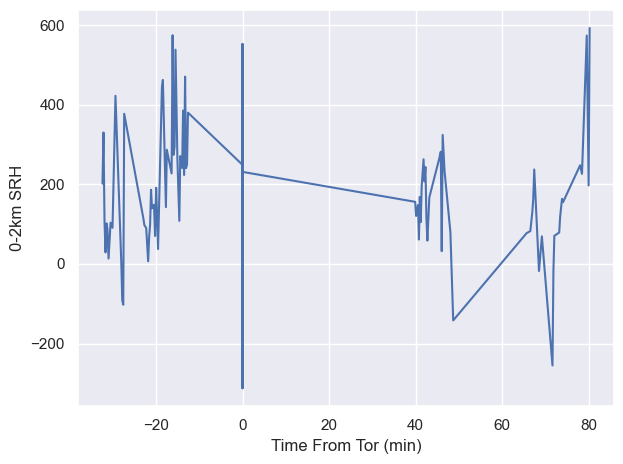

In [451]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        fig = plt.figure(figsize=(6,4))
        p = sns.objects.Plot(data = df, x="Time From Tor (min)", y="0-2km SRH").add(sns.objects.Line())
        p.label(title=f'{d} 0-2km SRH relative to torgen')
        p.show()

<Figure size 600x400 with 0 Axes>

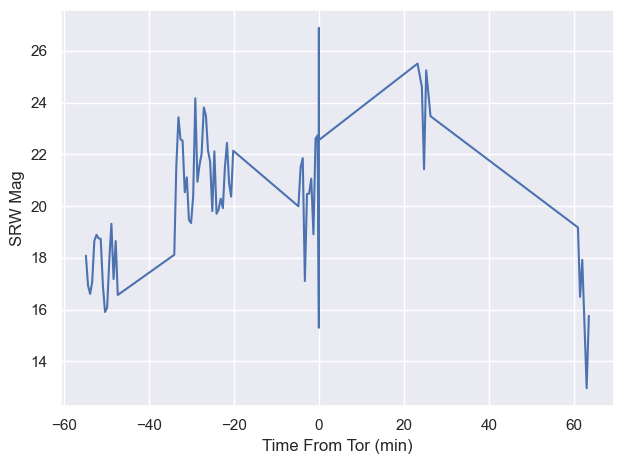

<Figure size 600x400 with 0 Axes>

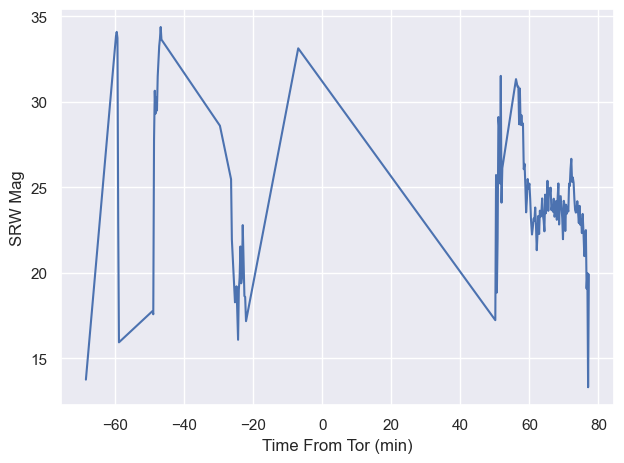

<Figure size 600x400 with 0 Axes>

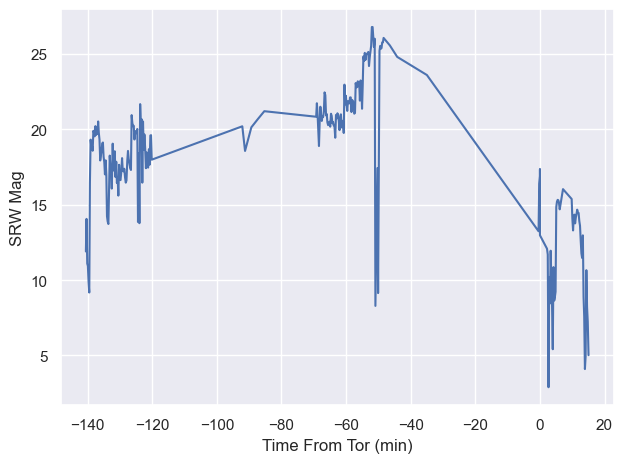

<Figure size 600x400 with 0 Axes>

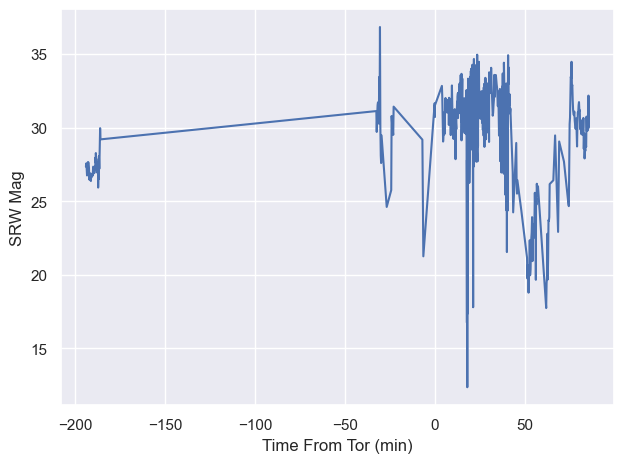

<Figure size 600x400 with 0 Axes>

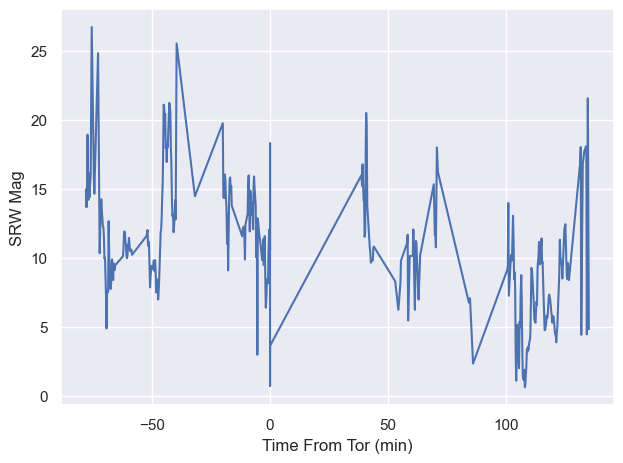

<Figure size 600x400 with 0 Axes>

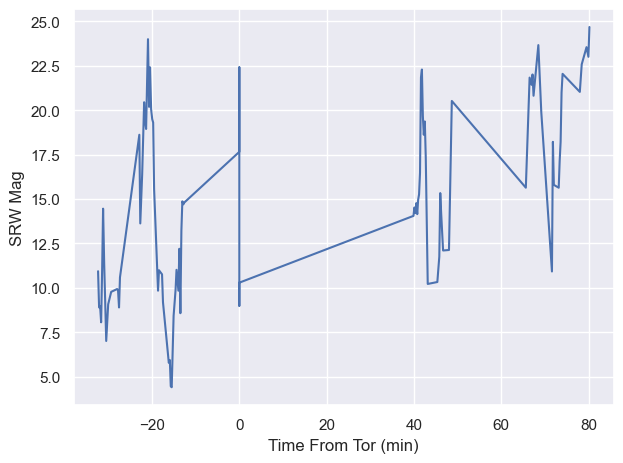

In [452]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        fig = plt.figure(figsize=(6,4))
        p = sns.objects.Plot(data = df, x="Time From Tor (min)", y="SRW Mag").add(sns.objects.Line())
        p.label(title=f'{d} SFC SRW relative to torgen')
        p.show()

# Mesocyclone strength

In [445]:
def meso_stats_get(meso_stats, features_shear_xr, d, meso_id):
    meso_max = []
    dates = []
    if not isinstance(meso_id, (list, set)):
        meso_id = [meso_id]
        
        meso_indeces = tobac_features_xr_shear['cell'].where(tobac_features_xr_shear['cell'].isin(meso_id), drop=True)
    
    meso_ids = meso_indeces.index
    
    if not isinstance(meso_ids, (list, set)):
        meso_ids = [meso_ids]
        
        meso_indeces2 = meso_stats['idx'].index.where(meso_stats['idx'].index.isin(meso_ids), drop=True)
    
    meso_ids_stats = meso_indeces2.index
    
    wanted_meso_max = meso_stats['max'][meso_ids_stats].values
    meso_max.append(wanted_meso_max)
    dates.append(d)

    fig = plt.figure()
    plt.plot(meso_stats['time'][meso_ids_stats], wanted_meso_max)
    plt.title(f'Maximum Azimuthal Shear Over Time Of Target Mesocyclones {d}')
    plt.xlabel('Time')
    plt.ylabel('Azshear')
    plt.show()

    return meso_max, dates

In [446]:
meso_id = 6, 12, 16, 38, 46, 57, 45, 54, 63, 66, 77, 81, 126
d = '20220611'

In [447]:
meso_stats = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Features_shear.nc')
tobac_features_xr_shear = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Track_shear.nc')

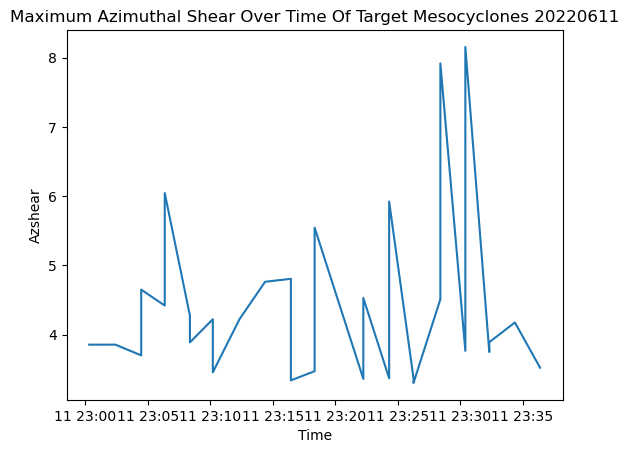

In [449]:
meso_max, dates = meso_stats_get(meso_stats, tobac_features_xr_shear, d, meso_id)

In [ ]:
d2 = ['20220523', '20220524', '20220531']
